<div style="background: linear-gradient(135deg, #BF91F8 0%, #232F3E 100%); padding: 30px;border-radius: 15px; text-align: center;margin-bottom:20px;"><h1 style="color: white; font-size: 2.2em; margin: 0;">
Practica 05: Un viaje visual y revelador - DonorsChoose</h1> 



**Programa de Estudios:** Ingenieria en Entornos Virtuales y Negocios Digitales\
**Asignatura:** Analitica de Datos para Negocios Digitales \
**Docente:** M.T.I. Marco A. Ramirez Hernández \
**Periodo:** Mayo - Agosto 2026

**Nombre del estudiante:** Michelle De La Cruz Rosalino \
**Matricula:** 230091 \
**Grado y Grupo:** 9A IEVND




## Ciencia de Datos para el Bien : DonorsChoose 

DonorsChoose es una organización sin fines de lucro con sede en EE. UU. que permite a las personas donar directamente a proyectos de aulas de escuelas públicas. Hasta enero de 2018, se habían financiado 1 millón de proyectos a través de DonorsChoose.org. En el 77% de las escuelas públicas de Estados Unidos, se ha solicitado al menos un proyecto en DonorsChoose.org. DonorsChoose ha compartido un conjunto de datos completo de todos los proyectos pasados, los recursos relacionados junto con los metadatos de maestros, escuelas, donantes y donaciones. Estos datos pueden usarse para extraer información oculta y crear una solución que permita a DonorsChoose.org construir campañas de correo electrónico dirigidas, recomendando solicitudes de aulas específicas a donantes anteriores. En este cuaderno, he realizado un análisis y exploración en profundidad del conjunto de datos compartido. Este cuaderno no solo proporciona información a partir de los datos de donorschoose, sino que también sirve como tutorial para realizar análisis de datos / análisis exploratorio de datos y visualizaciones de datos. 



In [3]:
from plotly.offline import init_notebook_mode, iplot
from wordcloud import WordCloud
import plotly.graph_objs as go
import matplotlib.pyplot as plt
import plotly.express as px
from plotly import tools
from datetime import date
import pandas as pd
import numpy as np 
import seaborn as sns
import random 
import warnings
import operator

# Configuración de alertas y modo notebook
warnings.filterwarnings("ignore")
init_notebook_mode(connected=True)

# Como tus archivos están en la misma carpeta que el notebook, 
# la ruta debe estar vacía ""
path = ""

# Carga de los archivos CSV
donors_df = pd.read_csv(path + "Donors.csv")
donations_df = pd.read_csv(path + "Donations.csv")
teachers_df = pd.read_csv(path + "Teachers.csv")

ModuleNotFoundError: No module named 'wordcloud'

## <a id="2">2. Explorando a los Donantes</a>

El conjunto de datos de donantes consiste en información sobre cada donante que ha donado al menos una vez en donorschoose, como su ciudad, estado, código postal y estatus de maestro. 

## <a id="2.1">2.1 Vista Previa de los Donantes</a>

Veamos una vista previa de las primeras filas del conjunto de datos de donantes

In [3]:
###### total rows
# donors_df.shape

###### total cities 
# len(donors_df['Donor City'].value_counts())

# more than one donation
# t = donations_df['Donor ID'].value_counts().to_frame()
# len(t[t['Donor ID']>1])

donors_df.head(3)

,Donor ID,Donor City,Donor State,Donor Is Teacher,Donor Zip
0,bdd640fb06671ad11c80317fa3b1799d,San Francisco,California,Yes,114
1,8b9d2434e465e150bd9c66b3ad3c2d6d,San Jose,California,Yes,105
2,9a1de644815ef6d13b8faa1837f8a88b,San Francisco,California,No,728


Hay un total de **2,122,640** donantes registrados en DonorsChoose hasta abril de 2018. Estos donantes pertenecen a **15,204 ciudades diferentes** de Estados Unidos y algunos otros países. De esa cantidad masiva de donantes, solo **552,941 (aproximadamente el 26%)** han donado más de una vez. Uno de los objetivos principales del desafío Data Science for Good es encontrar información / recomendaciones relevantes para que los donantes puedan sentirse inspirados nuevamente a donar. Hay alrededor de 1,471,613 donantes que han hecho solo 1 donación, por lo que DonorsChoose tiene la oportunidad de motivar a estas personas a realizar otro pago.

## <a id="2.2">2.2 Donantes por cada Estado</a> 
## <a id="2.2.1">2.2.1 Número de Donantes por Estado </a> 

In [5]:
import pandas as pd
import numpy as np
import folium

# ---------------------------------------
# Leer archivo de ciudades
# ---------------------------------------
c = pd.read_csv("zip_codes_states.csv")
c = c.dropna()

# Homogeneizar nombres
c["city"] = c["city"].str.upper().str.strip()
c["state"] = c["state"].str.upper().str.strip()

donors_df["Donor City"] = donors_df["Donor City"].str.upper().str.strip()

# Diccionario Estado -> Abreviatura
state_abbrev = {
    'Alabama':'AL','Alaska':'AK','Arizona':'AZ','Arkansas':'AR',
    'California':'CA','Colorado':'CO','Connecticut':'CT','Delaware':'DE',
    'District of Columbia':'DC','Florida':'FL','Georgia':'GA','Hawaii':'HI',
    'Idaho':'ID','Illinois':'IL','Indiana':'IN','Iowa':'IA','Kansas':'KS',
    'Kentucky':'KY','Louisiana':'LA','Maine':'ME','Maryland':'MD',
    'Massachusetts':'MA','Michigan':'MI','Minnesota':'MN','Mississippi':'MS',
    'Missouri':'MO','Montana':'MT','Nebraska':'NE','Nevada':'NV',
    'New Hampshire':'NH','New Jersey':'NJ','New Mexico':'NM',
    'New York':'NY','North Carolina':'NC','North Dakota':'ND',
    'Ohio':'OH','Oklahoma':'OK','Oregon':'OR','Pennsylvania':'PA',
    'Rhode Island':'RI','South Carolina':'SC','South Dakota':'SD',
    'Tennessee':'TN','Texas':'TX','Utah':'UT','Vermont':'VT',
    'Virginia':'VA','Washington':'WA','West Virginia':'WV',
    'Wisconsin':'WI','Wyoming':'WY'
}

donors_df["State Code"] = donors_df["Donor State"].map(state_abbrev)

# ---------------------------------------
# Donadores por ciudad
# ---------------------------------------
city_counts = (
    donors_df.groupby(["Donor City", "State Code"])
    .size()
    .reset_index(name="Donor Count")
)

city_counts.columns = ["city", "state", "Donor Count"]

# ---------------------------------------
# Coordenadas únicas por ciudad
# ---------------------------------------
coords = (
    c.groupby(["city", "state"])
    .agg({
        "latitude": "mean",
        "longitude": "mean"
    })
    .reset_index()
)

# ---------------------------------------
# Unir coordenadas
# ---------------------------------------
map_df = city_counts.merge(coords, on=["city", "state"], how="inner")

print("Ciudades encontradas:", len(map_df))

# ---------------------------------------
# Crear mapa
# ---------------------------------------
map4 = folium.Map(
    location=[39.8, -98.5],
    zoom_start=4,
    tiles="CartoDB dark_matter"
)

max_count = map_df["Donor Count"].max()

for _, row in map_df.iterrows():

    r = np.sqrt(row["Donor Count"] / max_count) * 70000

    # Halo exterior
    folium.Circle(
        location=[row["latitude"], row["longitude"]],
        radius=r*2,
        color=None,
        fill=True,
        fill_color="#c800ff",
        fill_opacity=0.04
    ).add_to(map4)

    # Halo intermedio
    folium.Circle(
        location=[row["latitude"], row["longitude"]],
        radius=r*1.5,
        color=None,
        fill=True,
        fill_color="#c800ff",
        fill_opacity=0.08
    ).add_to(map4)

    # Círculo principal
    folium.Circle(
        location=[row["latitude"], row["longitude"]],
        radius=r,
        color="#d900ff",
        weight=2,
        fill=True,
        fill_color="#9400ff",
        fill_opacity=0.28,
        popup=f"{row['city'].title()}, {row['state']}<br>Donors: {row['Donor Count']}"
    ).add_to(map4)

map4

Ciudades encontradas: 31


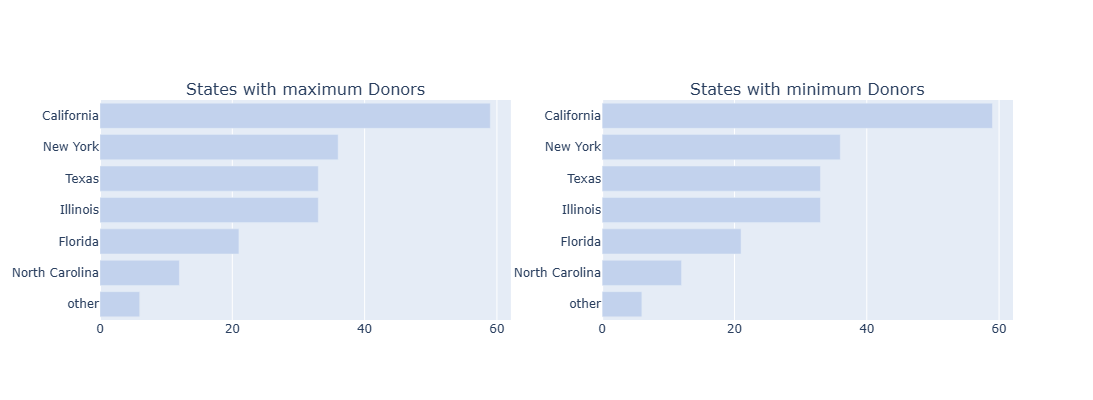

In [6]:
def bar_hor(df, col, title, color, w=None, h=None, lm=0, limit=100, return_trace=False, rev=False):
    cnt_srs = df[col].value_counts()
    yy = cnt_srs.head(limit).index[::-1] 
    xx = cnt_srs.head(limit).values[::-1] 
    if rev:
        yy = cnt_srs.tail(limit).index[::-1] 
        xx = cnt_srs.tail(limit).values[::-1] 
        
    
    trace = go.Bar(y=yy, x=xx, orientation = 'h', marker=dict(color=color))
    if return_trace:
        return trace 
    layout = dict(title=title, margin=dict(l=lm), width=w, height=h)
    data = [trace]
    fig = go.Figure(data=data, layout=layout)
    iplot(fig)

def bar_hor_noagg(x, y, title, color, w=None, h=None, lm=0, limit=100, rt=False):
    trace = go.Bar(y=x, x=y, orientation = 'h', marker=dict(color=color))
    if rt:
        return trace
    layout = dict(title=title, margin=dict(l=lm), width=w, height=h)
    data = [trace]
    fig = go.Figure(data=data, layout=layout)
    iplot(fig)


def bar_ver_noagg(x, y, title, color, w=None, h=None, lm=0, rt = False):
    trace = go.Bar(y=y, x=x, marker=dict(color=color))
    if rt:
        return trace
    layout = dict(title=title, margin=dict(l=lm), width=w, height=h)
    data = [trace]
    fig = go.Figure(data=data, layout=layout)
    iplot(fig)

    
trace1 = bar_hor(donors_df, 'Donor City', "Principales Ciudades con más Donantes", '#c2d2ed', 500, 400, 200, limit = 10, return_trace=True)
trace2 = bar_hor(donors_df, 'Donor State', "Principales Estados con más Donantes", '#c2d2ed', 500, 400, 200, limit = 10, return_trace=True)
trace4 = bar_hor(donors_df, 'Donor State', "Principales Estados con más Donantes", '#c2d2ed', 600, 400, 200, limit = 10, return_trace=True, rev=True)


fig = tools.make_subplots(rows=1, cols=2, print_grid=False, subplot_titles = ['States with maximum Donors','States with minimum Donors'])
# fig = tools.make_subplots(rows=2, cols=2, specs=[[{}, {}], [{'colspan': 2}, None]], print_grid=False, subplot_titles = ['States with maximum Donors','States with minimum Donors', 'Cities with maximum Donors'])
fig.append_trace(trace2, 1, 1);
fig.append_trace(trace4, 1, 2);
# fig.append_trace(trace1, 2, 1);

fig['layout'].update(height=400, showlegend=False);
iplot(fig); 

> - California, al ser el estado con mayor población, también tiene una gran base de donantes registrados con casi 300,000 donantes. **San Francisco y Los Ángeles** son las principales ciudades de California donde se ubica el mayor número de donantes. El mayor número de escuelas y proyectos también proviene del estado de California. 
> - Nueva York, Texas y Florida, con aproximadamente 137,000, 134,000 y 108,000 donantes, son los otros tres estados principales con una alta población de donantes. Las ciudades principales incluyen Nueva York, Miami, Tampa, Houston y Dallas, donde se ubica el mayor número de donantes. 
> - Dakota del Norte, Dakota del Sur, Vermont y Wyoming son los estados con el número más bajo de donantes, menos de 4000. Hay una entrada llamada "otros" en los datos de estados, que probablemente indica donantes maestros o donantes de otros países.   
> - Entre las ciudades en general de EE. UU., las tres principales son: **Chicago (aprox. 35K donantes), Nueva York (aprox. 27K donantes) y Brooklyn (aprox. 22K donantes)** con el mayor número de donantes. Las ciudades de California, SF y LA, son las siguientes dos ciudades con una gran base de donantes, con aprox. 18K y aprox. 16K donantes 

## <a>Conjunto de Datos Ajustado por Población</a>

Los principales estados en las gráficas anteriores son en realidad los estados con población muy alta. Será interesante averiguar el número de donantes por cada 100,000 personas en cada estado. He agregado un conjunto de datos ajustado por población que incluye la población de cada estado a partir de 2013. 

Conjunto de Datos de Población : http://www.enchantedlearning.com/usa/states/population.shtml

## <a id="2.3">2.3 Estados con la más alta **Proporción de Donantes por Población**   </a>

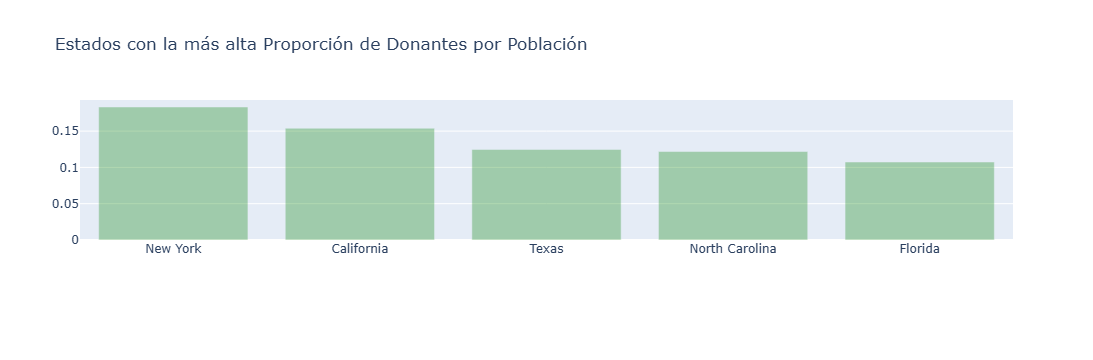

In [7]:
census_2013 = {'Mississippi': 2991207, 'Iowa': 3090416, 'Oklahoma': 3850568, 'Delaware': 925749, 'Minnesota': 5420380, 'Alaska': 735132, 'Illinois': 12882135, 'Arkansas': 2959373, 'New Mexico': 2085287, 'Indiana': 6570902, 'Maryland': 5928814, 'Louisiana': 4625470, 'Texas': 26448193, 'Wyoming': 582658, 'Arizona': 6626624, 'Wisconsin': 5742713, 'Michigan': 9895622, 'Kansas': 2893957, 'Utah': 2900872, 'Virginia': 8260405, 'Oregon': 3930065, 'Connecticut': 3596080, 'New York': 19651127, 'California': 38332521, 'Massachusetts': 6692824, 'West Virginia': 1854304, 'South Carolina': 4774839, 'New Hampshire': 1323459, 'Vermont': 626630, 'Georgia': 9992167, 'North Dakota': 723393, 'Pennsylvania': 12773801, 'Florida': 19552860, 'Hawaii': 1404054, 'Kentucky': 4395295, 'Rhode Island': 1051511, 'Nebraska': 1868516, 'Missouri': 6044171, 'Ohio': 11570808, 'Alabama': 4833722, 'South Dakota': 844877, 'Colorado': 5268367, 'Idaho': 1612136, 'New Jersey': 8899339, 'Washington': 6971406, 'North Carolina': 9848060, 'Tennessee': 6495978, 'Montana': 1015165, 'District of Columbia': 646449, 'Nevada': 2790136, 'Maine': 1328302}

donors_from_states = dict(donors_df['Donor State'].value_counts())

don_pop = {}
for state, don in donors_from_states.items():
    if state not in census_2013:
        continue
    don_pop[state]  = float(don)*100000/ census_2013[state]

import operator
don_pop = sorted(don_pop.items(), key=operator.itemgetter(1), reverse = True)
xx = [x[0] for x in (don_pop)][1:]
yy = [x[1] for x in (don_pop)][1:]

trace2 = go.Bar(
    x=xx,
    y=yy,
    name='Donors to Population',
    marker=dict(color='green'),
    opacity=0.3
)

data = [trace2]
layout = go.Layout(
    barmode='group',
    legend=dict(dict(x=-.1, y=1.2)),
    margin=dict(b=120),
    title = 'Estados con la más alta Proporción de Donantes por Población',
)

fig = go.Figure(data=data, layout=layout)
iplot(fig, filename='grouped-bar')

> - Se genera una gráfica interesante ya que los estados: **Carolina del Sur** (con población = 4,774,839), **Massachusetts** (con población = 6,692,824) y **Connecticut** (con población = 3,596,080) tienen la mayor proporción de donantes por población, y el mayor número de donantes por cada 100,000 personas. Carolina del Sur = 985 donantes por cada 100K personas, Massachusetts = 907 donantes por cada 100K personas, y Connecticut = 878 donantes por cada 100K personas.   
> - Wyoming, Nebraska y Nuevo México tienen el menor número de donantes por cada 100K personas, igual a 285, 335 y 363 donantes. 
> - Texas, uno de los principales estados con el mayor número de donantes, tiene una proporción de donantes por población más baja, igual a 508 donantes por cada 100K personas

## <a id="2.4">2.4 Visualicemos dónde se ubican los Donantes </a>
## <a id="2.4.1"> 2.4.1 Dónde se ubican los donantes en California </a>

In [8]:
calcit = StringIO(u"""Name,Latitude,Longitude,Total Donors,Color,Size
Los Angeles,34.052233,-118.243686,"17,922.000000",#0061ff,10
San Francisco,37.774931,-122.419417,"16,553.000000",#0061ff,10
San Diego,32.715328,-117.157256,"9,072.000000",#0061ff,10
San Jose,37.339386,-121.894956,"7,674.000000",#0061ff,10
Oakland,37.804364,-122.271114,"6,783.000000",#0061ff,10
Sacramento,38.581572,-121.494400,"4,701.000000",#0061ff,10
Bakersfield,35.373292,-119.018711,"3,758.000000",#0061ff,10
Long Beach,33.768322,-118.195617,"3,120.000000",#0061ff,10
Berkeley,37.871592,-122.272747,"2,898.000000",#0061ff,10
Irvine,33.683947,-117.794694,"2,765.000000",#0061ff,10
Fremont,37.548269,-121.988572,"2,716.000000",#0061ff,10
Walnut Creek,37.910078,-122.065183,"2,255.000000",#0061ff,10
Huntington Beach,33.660297,-117.999225,"2,185.000000",#0061ff,10
Murrieta,33.553914,-117.213922,"1,982.000000",#0061ff,10
Pleasanton,37.662431,-121.874678,"1,970.000000",#0061ff,10
Torrance,33.83585,-118.340628,"1,957.000000",#0061ff,10
San Mateo,37.562992,-122.325525,"1,956.000000",#0061ff,10
Santa Monica,34.019453,-118.491192,"1,780.000000",#0061ff,10
Livermore,37.681875,-121.768008,"1,776.000000",#0061ff,10
Santa Rosa,38.440467,-122.714431,"1,752.000000",#0061ff,10
Concord,37.977978,-122.031072,"1,623.000000",#0061ff,10
Alameda,37.765206,-122.241636,"1,548.000000",#0061ff,10
Fresno,36.746842,-119.772586,"1,543.000000",#0061ff,10
San Ramon,37.779928,-121.978014,"1,533.000000",#0061ff,10
Anaheim,33.835292,-117.914503,"1,475.000000",#0061ff,10
Pasadena,34.147786,-118.144517,"1,429.000000",#0061ff,10
Glendale,34.142508,-118.255075,"1,427.000000",#0061ff,10
Riverside,33.95335,-117.396156,"1,425.000000",#0061ff,10
Sunnyvale,37.368831,-122.036350,"1,406.000000",#0061ff,10
Chula Vista,32.640053,-117.084197,"1,398.000000",#0061ff,10
Mountain View,37.386053,-122.083850,"1,398.000000",#0061ff,10
Elk Grove,38.4088,-121.371617,"1,397.000000",#0061ff,10
Santa Clarita,34.391664,-118.542586,"1,382.000000",#0061ff,10
Burbank,34.180839,-118.308967,"1,357.000000",#0061ff,10
Redwood City,37.485214,-122.236356,"1,323.000000",#0061ff,10
Chico,39.728494,-121.837478,"1,322.000000",#0061ff,10
Whittier,33.979178,-118.032844,"1,280.000000",#0061ff,10
Corona,33.875294,-117.566439,"1,239.000000",#0061ff,10
Santa Clara,37.354108,-121.955236,"1,233.000000",#0061ff,10
Orange,33.787794,-117.853111,"1,229.000000",#0061ff,10
Palo Alto,37.441883,-122.143019,"1,219.000000",#0061ff,10
Hayward,37.668819,-122.080797,"1,162.000000",#0061ff,10
Oceanside,33.195869,-117.379483,"1,157.000000",#0061ff,10
Fullerton,33.870292,-117.925339,"1,151.000000",#0061ff,10
San Rafael,37.973536,-122.531086,"1,136.000000",#0061ff,10
Folsom,38.677958,-121.176058,"1,125.000000",#0061ff,10
Simi Valley,34.269447,-118.781483,"1,069.000000",#0061ff,10
Escondido,33.119208,-117.086422,"1,062.000000",#0061ff,10
Santa Ana,33.745572,-117.867833,"1,054.000000",#0061ff,10
Redondo Beach,33.849183,-118.388408,"1,048.000000",#34ef6c,8
Stockton,37.957703,-121.290781,"1,041.000000",#34ef6c,8
Santa Cruz,36.974117,-122.030797,"1,029.000000",#34ef6c,8
Culver City,34.021122,-118.396467,"1,019.000000",#34ef6c,8
Salinas,36.677736,-121.655500,"1,017.000000",#34ef6c,8
Martinez,38.019367,-122.134133,975.000000,#34ef6c,8
Santa Barbara,34.420831,-119.698189,936.000000,#34ef6c,8
San Leandro,37.724931,-122.156078,929.000000,#34ef6c,8
Ventura,34.274639,-119.229006,922.000000,#34ef6c,8
Roseville,38.752122,-121.288006,888.000000,#34ef6c,8
Yorba Linda,33.888625,-117.813111,888.000000,#34ef6c,8
Costa Mesa,33.641133,-117.918669,887.000000,#34ef6c,8
San Marcos,33.143372,-117.166144,866.000000,#34ef6c,8
Brentwood,34.057361,-118.480511,853.000000,#34ef6c,8
South San Francisco,37.654656,-122.407750,841.000000,#34ef6c,8
Modesto,37.639097,-120.996878,837.000000,#34ef6c,8
Temecula,33.493639,-117.148364,837.000000,#34ef6c,8
Novato,38.107419,-122.569703,831.000000,#34ef6c,8
Carlsbad,33.158092,-117.350594,822.000000,#34ef6c,8
Mission Viejo,33.600022,-117.671994,817.000000,#34ef6c,8
Brea,33.916681,-117.900061,802.000000,#34ef6c,8
Garden Grove,33.773906,-117.941447,792.000000,#34ef6c,8
Dublin,37.702153,-121.935792,784.000000,#34ef6c,8
El Cajon,32.794772,-116.962528,783.000000,#34ef6c,8
Menlo Park,37.453828,-122.182186,768.000000,#34ef6c,8
Fairfield,38.249358,-122.039967,751.000000,#34ef6c,8
Pleasant Hill,37.947978,-122.060797,725.000000,#34ef6c,8
Napa,38.297539,-122.286864,711.000000,#34ef6c,8
Richmond,37.935758,-122.347750,707.000000,#34ef6c,8
Los Altos,33.796331,-118.118119,703.000000,#34ef6c,8
Daly City,37.687925,-122.470208,702.000000,#34ef6c,8
West Covina,34.068622,-117.938953,688.000000,#34ef6c,8
Lafayette,37.885758,-122.118019,660.000000,#34ef6c,8
La Mesa,32.767828,-117.023083,649.000000,#34ef6c,8
Milpitas,37.428272,-121.906625,649.000000,#34ef6c,8
Carson,33.831406,-118.282017,647.000000,#34ef6c,8
Camarillo,34.216394,-119.037603,643.000000,#34ef6c,8
Petaluma,38.232417,-122.636653,629.000000,#34ef6c,8
Newport Beach,33.618911,-117.928947,626.000000,#34ef6c,8
Pacifica,37.613825,-122.486919,619.000000,#34ef6c,8
Gilroy,37.005783,-121.568275,618.000000,#34ef6c,8
Encinitas,33.036986,-117.291983,607.000000,#34ef6c,8
El Segundo,33.919181,-118.416464,595.000000,#34ef6c,8
Downey,33.940014,-118.132569,592.000000,#34ef6c,8
Rancho Palos Verdes,33.744461,-118.387017,592.000000,#34ef6c,8
San Clemente,33.426972,-117.611992,589.000000,#34ef6c,8
Vacaville,38.356578,-121.987744,584.000000,#34ef6c,8
Chino Hills,33.989819,-117.732586,583.000000,#34ef6c,8
Campbell,37.287164,-121.949958,580.000000,#34ef6c,8
Mill Valley,37.906036,-122.544975,578.000000,#34ef6c,8
El Cerrito,37.916133,-122.310764,576.000000,#f2ae93,6
Emeryville,37.831317,-122.285247,572.000000,#f2ae93,6
Thousand Oaks,34.107231,-118.057847,572.000000,#f2ae93,6
Burlingame,37.584103,-122.366083,570.000000,#f2ae93,6
Antioch,38.004922,-121.805789,568.000000,#f2ae93,6
Beverly Hills,34.073619,-118.400356,568.000000,#f2ae93,6
Lakewood,33.853628,-118.133956,560.000000,#f2ae93,6
Manhattan Beach,33.884736,-118.410908,557.000000,#f2ae93,6
Lancaster,34.686786,-118.154164,551.000000,#f2ae93,6
Oxnard,34.197506,-119.177053,539.000000,#f2ae93,6
San Carlos,37.507158,-122.260522,527.000000,#f2ae93,6
Rocklin,38.790733,-121.235783,526.000000,#f2ae93,6
Placentia,33.872236,-117.870336,520.000000,#f2ae93,6
Cupertino,37.322997,-122.032183,516.000000,#f2ae93,6
Tustin,33.74585,-117.826167,508.000000,#f2ae93,6
Hermosa Beach,33.862236,-118.399519,507.000000,#f2ae93,6
Rancho Cordova,38.589072,-121.302728,501.000000,#f2ae93,6
Fountain Valley,33.709186,-117.953669,498.000000,#f2ae93,6
Cypress,37.320531,-121.962242,497.000000,#f2ae93,6
Union City,37.593392,-122.043831,494.000000,#f2ae93,6
Morgan Hill,37.1305,-121.654389,488.000000,#f2ae93,6
Vallejo,38.104086,-122.256636,485.000000,#f2ae93,6
Alhambra,34.095286,-118.127014,474.000000,#f2ae93,6
Lake Forest,33.646967,-117.689217,465.000000,#f2ae93,6
Rancho Cucamonga,34.1064,-117.593108,463.000000,#f2ae93,6
Vista,33.200036,-117.242536,463.000000,#f2ae93,6
Fontana,34.092233,-117.435047,459.000000,#f2ae93,6
Moreno Valley,33.942467,-117.229672,455.000000,#f2ae93,6
Hawthorne,33.916403,-118.352575,450.000000,#f2ae93,6
Covina,34.090008,-117.890339,443.000000,#f2ae93,6
San Luis Obispo,35.282753,-120.659617,434.000000,#f2ae93,6
Newark,37.529658,-122.040239,433.000000,#f2ae93,6
Inglewood,33.961681,-118.353131,432.000000,#f2ae93,6
Oakley,37.997422,-121.712453,430.000000,#f2ae93,6
Tracy,37.73965,-121.425222,428.000000,#f2ae93,6
Redding,40.586539,-122.391675,424.000000,#f2ae93,6
Glendora,34.136119,-117.865339,423.000000,#f2ae93,6
San Bruno,37.630489,-122.411083,423.000000,#f2ae93,6
Davis,38.544906,-121.740517,417.000000,#f2ae93,6
Westminster,33.751342,-117.993992,413.000000,#f2ae93,6
Pittsburg,38.027975,-121.884681,412.000000,#f2ae93,6
Palmdale,34.579433,-118.116461,408.000000,#f2ae93,6
Visalia,36.330228,-119.292058,406.000000,#f2ae93,6
Poway,32.962822,-117.035864,403.000000,#f2ae93,6
Santa Maria,34.953033,-120.435719,403.000000,#f2ae93,6
Upland,34.097511,-117.648389,396.000000,#f2ae93,6
Laguna Niguel,33.522525,-117.707553,393.000000,#f2ae93,6
La Mirada,33.917236,-118.012008,392.000000,#f2ae93,6
South Pasadena,34.116119,-118.150350,391.000000,#f2ae93,6
Cerritos,33.858347,-118.064786,383.000000,#f2ae93,6
Lodi,38.134147,-121.272219,380.000000,#f2ae93,6
Ontario,34.063344,-117.650889,380.000000,#bab7b6,4
Lincoln,38.891564,-121.293008,376.000000,#bab7b6,4
Buena Park,33.867514,-117.998117,375.000000,#bab7b6,4
Rancho Santa Margarita,33.640856,-117.603103,373.000000,#bab7b6,4
Santee,32.838383,-116.973917,373.000000,#bab7b6,4
Sonoma,38.291858,-122.458036,372.000000,#bab7b6,4
Monrovia,34.144428,-118.001947,371.000000,#bab7b6,4
Albany,37.886869,-122.297747,368.000000,#bab7b6,4
La Habra,33.931958,-117.946172,366.000000,#bab7b6,4
San Pablo,37.962147,-122.345525,366.000000,#bab7b6,4
Belmont,37.520214,-122.275800,364.000000,#bab7b6,4
Pomona,34.055228,-117.752306,364.000000,#bab7b6,4
Gardena,33.88835,-118.308961,363.000000,#bab7b6,4
Arcadia,34.139728,-118.035344,361.000000,#bab7b6,4
Clovis,36.825228,-119.702919,360.000000,#bab7b6,4
Orinda,37.877147,-122.179689,358.000000,#bab7b6,4
Manteca,37.797428,-121.216053,357.000000,#bab7b6,4
Citrus Heights,38.707125,-121.281061,355.000000,#bab7b6,4
Redlands,34.055569,-117.182539,353.000000,#bab7b6,4
Aliso Viejo,33.575,-117.725556,345.000000,#bab7b6,4
Eureka,40.802072,-124.163672,338.000000,#bab7b6,4
West Hollywood,34.090008,-118.361744,337.000000,#bab7b6,4
Auburn,38.896564,-121.076889,335.000000,#bab7b6,4
Saratoga,37.263833,-122.023014,331.000000,#bab7b6,4
Turlock,37.494658,-120.846594,327.000000,#bab7b6,4
Chino,34.012236,-117.688944,325.000000,#bab7b6,4
Diamond Bar,34.028622,-117.810336,324.000000,#bab7b6,4
South Gate,33.954736,-118.212017,319.000000,#bab7b6,4
San Bernardino,34.108344,-117.289764,318.000000,#bab7b6,4
Claremont,34.096675,-117.719778,316.000000,#bab7b6,4
Calabasas,34.138333,-118.660833,298.000000,#bab7b6,4
Los Alamitos,33.803072,-118.072564,297.000000,#bab7b6,4
Agoura Hills,34.153339,-118.761675,295.000000,#bab7b6,4
San Gabriel,34.096111,-118.105833,295.000000,#bab7b6,4
Paso Robles,35.632278,-120.664186,292.000000,#bab7b6,4
Norwalk,33.902236,-118.081733,286.000000,#bab7b6,4
Indio,33.720578,-116.215561,284.000000,#bab7b6,4
Moorpark,34.144897,-118.268742,284.000000,#bab7b6,4
Monterey,36.600239,-121.894675,275.000000,#bab7b6,4
Arroyo Grande,35.118586,-120.590725,274.000000,#bab7b6,4
San Dimas,34.106675,-117.806725,274.000000,#bab7b6,4
La Puente,34.020011,-117.949508,273.000000,#bab7b6,4
West Sacramento,38.580461,-121.530233,273.000000,#bab7b6,4
Rohnert Park,38.339636,-122.701097,269.000000,#bab7b6,4
Monterey Park,34.062511,-118.122847,266.000000,#bab7b6,4
Laguna Hills,33.599722,-117.699444,260.000000,#bab7b6,4
Watsonville,36.910231,-121.756894,259.000000,#bab7b6,4
Clayton,37.941033,-121.935792,256.000000,#bab7b6,4
Hemet,33.747519,-116.971967,256.000000,#bab7b6,4
La Verne,34.100842,-117.767836,255.000000,#bab7b6,4
Ukiah,39.150172,-123.207783,255.000000,#f477d7,2
Palm Desert,33.722244,-116.374456,251.000000,#f477d7,2
Atascadero,35.489417,-120.670725,241.000000,#f477d7,2
Menifee,33.678333,-117.166944,241.000000,#f477d7,2
Lompoc,34.63915,-120.457942,240.000000,#f477d7,2
Merced,37.302164,-120.482967,240.000000,#f477d7,2
Sebastopol,38.402136,-122.823881,237.000000,#f477d7,2
Lake Elsinore,33.668078,-117.327261,236.000000,#f477d7,2
Millbrae,37.598547,-122.387194,234.000000,#f477d7,2
Yuba City,39.140447,-121.616911,231.000000,#f477d7,2
Woodland,38.678517,-121.773297,228.000000,#f477d7,2
Bellflower,33.881683,-118.117011,227.000000,#f477d7,2
Grass Valley,39.219061,-121.061061,227.000000,#f477d7,2
Seal Beach,33.741406,-118.104786,227.000000,#f477d7,2
Walnut,34.020289,-117.865339,227.000000,#f477d7,2
Montebello,34.016506,-118.113753,225.000000,#f477d7,2
Yucaipa,34.033625,-117.043086,225.000000,#f477d7,2
Hanford,36.32745,-119.645683,224.000000,#f477d7,2
Goleta,34.435828,-119.827639,221.000000,#f477d7,2
Hesperia,34.426389,-117.300878,221.000000,#f477d7,2
Laguna Beach,33.542247,-117.783111,221.000000,#f477d7,2
Ridgecrest,35.622456,-117.670897,218.000000,#f477d7,2
Galt,38.254636,-121.299947,217.000000,#f477d7,2
Victorville,34.536108,-117.291158,217.000000,#f477d7,2
San Juan Capistrano,33.501692,-117.662550,209.000000,#f477d7,2
Atwater,37.347717,-120.609083,208.000000,#f477d7,2
Palm Springs,33.830297,-116.545292,208.000000,#f477d7,2
Azusa,34.133619,-117.907564,203.000000,#f477d7,2
Hercules,38.017144,-122.288581,202.000000,#f477d7,2
Sonora,37.984092,-120.382139,199.000000,#f477d7,2
Beaumont,33.929461,-116.977247,198.000000,#f477d7,2
Half Moon Bay,37.463553,-122.428586,197.000000,#f477d7,2
Hollister,36.852453,-121.401603,196.000000,#f477d7,2
Westlake Village,34.145839,-118.805647,194.000000,#f477d7,2
Pico Rivera,33.983069,-118.096736,190.000000,#f477d7,2
Pinole,38.004367,-122.298858,186.000000,#f477d7,2
Compton,33.89585,-118.220072,185.000000,#f477d7,2
Sausalito,37.859094,-122.485250,183.000000,#f477d7,2
La Quinta,33.646692,-116.310008,181.000000,#f477d7,2
Dana Point,33.466972,-117.698108,175.000000,#f477d7,2
Rialto,34.1064,-117.370325,172.000000,#f477d7,2
Perris,33.782519,-117.228647,171.000000,#f477d7,2
Arcata,40.866517,-124.082839,168.000000,#f477d7,2
Pacific Grove,36.617736,-121.916622,168.000000,#f477d7,2
Lomita,33.792239,-118.315072,167.000000,#f477d7,2
San Fernando,34.281947,-118.438972,165.000000,#f477d7,2
South Lake Tahoe,38.939925,-119.977186,163.000000,#f477d7,2
El Monte,34.068622,-118.027567,158.000000,#f477d7,2
Scotts Valley,37.051061,-122.014683,158.000000,#f477d7,2
Tehachapi,35.132189,-118.448975,157.000000,#f477d7,2
Baldwin Park,34.085286,-117.960897,156.000000,#f477d7,2
Marina,36.684403,-121.802172,155.000000,#f477d7,2
Rosemead,34.080564,-118.072847,155.000000,#f477d7,2
Placerville,38.729625,-120.798547,151.000000,#f477d7,2
Highland,34.128344,-117.208650,148.000000,#f477d7,2
Lawndale,33.887236,-118.352575,143.000000,#f477d7,2
Oroville,39.513775,-121.556358,142.000000,#f477d7,2
Seaside,33.819361,-118.366647,142.000000,#f477d7,2
Wildomar,33.598914,-117.280036,142.000000,#f477d7,2
Duarte,34.13945,-117.977286,141.000000,#f477d7,2
Huntington Park,33.981681,-118.225072,141.000000,#f477d7,2
Larkspur,37.934092,-122.535253,139.000000,#f477d7,2
Del Mar,32.959489,-117.265314,138.000000,#f477d7,2
Winters,38.524906,-121.970803,138.000000,#f477d7,2
Red Bluff,40.178489,-122.235831,137.000000,#f477d7,2
Cathedral City,33.779742,-116.465292,136.000000,#f9e84a,1
Ojai,34.44805,-119.242889,136.000000,#f9e84a,1
Coronado,32.685886,-117.183089,134.000000,#f9e84a,1
Lynwood,33.930292,-118.211461,134.000000,#f9e84a,1
Temple City,34.107231,-118.057847,132.000000,#f9e84a,1
Bell,33.977514,-118.187017,124.000000,#f9e84a,1
Sierra Madre,34.161672,-118.052847,119.000000,#f9e84a,1
Nevada City,39.261561,-121.016058,118.000000,#f9e84a,1
National City,32.678108,-117.099197,117.000000,#f9e84a,1
Ceres,37.594933,-120.957711,116.000000,#f9e84a,1
Solana Beach,32.991156,-117.271147,115.000000,#f9e84a,1
La Palma,33.846403,-118.046731,114.000000,#f9e84a,1
Healdsburg,38.610467,-122.869161,110.000000,#f9e84a,1
Ripon,37.739453,-121.135414,109.000000,#f9e84a,1
Crescent City,41.755947,-124.201747,108.000000,#f9e84a,1
Malibu,34.005008,-118.810172,108.000000,#f9e84a,1
Patterson,37.4716,-121.129656,107.000000,#f9e84a,1
Maywood,33.986681,-118.185350,105.000000,#f9e84a,1
Suisun City,38.238247,-122.040244,105.000000,#f9e84a,1
Dixon,38.445464,-121.823297,104.000000,#f9e84a,1
Fort Bragg,39.445722,-123.805292,103.000000,#f9e84a,1
Oakdale,37.766594,-120.847153,103.000000,#f9e84a,1
American Canyon,38.174917,-122.260803,100.000000,#f9e84a,1
Lemon Grove,32.742553,-117.031417,97.000000,#f9e84a,1
Carpinteria,34.398883,-119.518456,96.000000,#f9e84a,1
Lemoore,36.300783,-119.782911,96.000000,#f9e84a,1
San Jacinto,33.783908,-116.958636,95.000000,#f9e84a,1
San Marino,34.121397,-118.106458,95.000000,#f9e84a,1
Paramount,33.889461,-118.159792,94.000000,#f9e84a,1
Tulare,36.207728,-119.347339,93.000000,#f9e84a,1
Twentynine Palms,34.135558,-116.054169,92.000000,#f9e84a,1
Shafter,35.500514,-119.271775,91.000000,#f9e84a,1
Norco,33.931125,-117.548661,89.000000,#f9e84a,1
Capitola,36.975228,-121.953292,88.000000,#f9e84a,1
Rio Vista,38.15575,-121.691344,88.000000,#f9e84a,1
Colton,34.073903,-117.313656,86.000000,#f9e84a,1
Brisbane,37.680767,-122.399972,85.000000,#f9e84a,1
Taft,35.142467,-119.456508,85.000000,#f9e84a,1
Imperial Beach,32.583944,-117.113086,84.000000,#f9e84a,1
Kingsburg,36.513839,-119.554017,84.000000,#f9e84a,1
Morro Bay,35.365808,-120.849900,83.000000,#f9e84a,1
Santa Fe Springs,33.947236,-118.085344,83.000000,#f9e84a,1
Rancho Mirage,33.739744,-116.412789,78.000000,#f9e84a,1
Stanton,33.802517,-117.993117,78.000000,#f9e84a,1
Madera,36.961336,-120.060717,77.000000,#f9e84a,1
Los Banos,37.058278,-120.849914,76.000000,#f9e84a,1
Riverbank,37.736039,-120.935489,76.000000,#f9e84a,1
Gridley,39.363778,-121.693583,75.000000,#f9e84a,1
Pismo Beach,35.142753,-120.641283,74.000000,#f9e84a,1
Santa Paula,34.354167,-119.059269,74.000000,#f9e84a,1
Cotati,38.327778,-122.709167,73.000000,#f9e84a,1
Port Hueneme,34.180728,-119.208158,73.000000,#f9e84a,1
Selma,36.570783,-119.612075,73.000000,#f9e84a,1
Banning,33.925572,-116.876411,71.000000,#f9e84a,1
King City,36.212744,-121.126028,71.000000,#f9e84a,1
El Centro,32.792,-115.563050,69.000000,#f9e84a,1
Lakeport,39.04295,-122.915828,69.000000,#f9e84a,1
Willits,39.409608,-123.355567,68.000000,#f9e84a,1
Barstow,34.895797,-117.017283,67.000000,#f9e84a,1
Marysville,39.145725,-121.591356,67.000000,#f9e84a,1
Orland,39.747381,-122.196375,66.000000,#f9e84a,1
Grand Terrace,34.033903,-117.313653,63.000000,#f9e84a,1
Montclair,34.077511,-117.689778,63.000000,#f9e84a,1
Villa Park,33.814461,-117.813111,63.000000,#f9e84a,1
Artesia,33.865847,-118.083122,62.000000,#f9e84a,1
Desert Hot Springs,33.961125,-116.501678,61.000000,#f9e84a,1
Fortuna,40.598186,-124.157275,61.000000,#f9e84a,1
Grover Beach,35.121642,-120.621283,61.000000,#f9e84a,1
Loma Linda,34.048347,-117.261153,59.000000,#f9e84a,1
Dinuba,36.543283,-119.387067,58.000000,#f9e84a,1
South El Monte,34.051956,-118.046733,58.000000,#f9e84a,1
Porterville,36.065231,-119.016767,57.000000,#f9e84a,1
Lathrop,37.822706,-121.276611,56.000000,#f9e84a,1
Coalinga,36.139678,-120.360150,55.000000,#f9e84a,1
Fillmore,34.399164,-118.918153,54.000000,#f9e84a,1
Mount Shasta,41.410806,-122.194575,52.000000,#f9e84a,1
Anderson,40.448208,-122.297783,51.000000,#f9e84a,1
Cloverdale,38.805461,-123.017222,50.000000,#f9e84a,1
Exeter,36.296061,-119.142053,50.000000,#f9e84a,1
Wasco,35.594125,-119.340947,50.000000,#f9e84a,1
Reedley,36.596339,-119.450403,47.000000,#f9e84a,1
Sanger,36.708006,-119.555964,47.000000,#f9e84a,1
Adelanto,34.582769,-117.409214,45.000000,#f9e84a,1
Brawley,32.978658,-115.530267,43.000000,#f9e84a,1
Calimesa,34.003903,-117.061975,42.000000,#f9e84a,1
Hughson,37.602725,-120.866481,42.000000,#f9e84a,1
Imperial,32.847553,-115.569439,41.000000,#f9e84a,1
Soledad,32.991156,-117.271147,41.000000,#f9e84a,1
Weed,41.42265,-122.386128,40.000000,#f9e84a,1
Calexico,32.678947,-115.498883,37.000000,#f9e84a,1
Willows,39.524325,-122.193592,36.000000,#f9e84a,1
Big Bear Lake,34.243897,-116.911422,35.000000,#f9e84a,1
Delano,35.768842,-119.247053,34.000000,#f9e84a,1
Newman,37.313828,-121.020761,34.000000,#f9e84a,1
Colfax,39.100731,-120.953275,33.000000,#f9e84a,1
Escalon,37.797428,-120.996603,33.000000,#f9e84a,1
Jackson,38.348803,-120.774103,32.000000,#f9e84a,1
Bishop,37.363539,-118.395111,31.000000,#f9e84a,1
Coachella,33.6803,-116.173894,31.000000,#f9e84a,1
Holtville,32.811161,-115.380264,31.000000,#f9e84a,1
Indian Wells,33.717631,-116.340756,31.000000,#f9e84a,1
San Juan Bautista,36.845511,-121.537997,31.000000,#f9e84a,1
Arvin,35.2018,-118.833106,30.000000,#f9e84a,1
Kerman,36.723558,-120.059878,30.000000,#f9e84a,1
Colusa,39.214333,-122.009417,27.000000,#f9e84a,1
Greenfield,36.3208,-121.243814,27.000000,#f9e84a,1
Waterford,37.641319,-120.760483,26.000000,#f9e84a,1
Ferndale,40.576242,-124.263944,25.000000,#f9e84a,1
Susanville,40.416283,-120.653006,25.000000,#f9e84a,1
Buellton,34.613597,-120.192650,24.000000,#f9e84a,1
Calistoga,38.578797,-122.579706,24.000000,#f9e84a,1
Clearlake,38.958231,-122.626372,24.000000,#f9e84a,1
Shasta Lake,40.680428,-122.370842,24.000000,#f9e84a,1
Yreka,41.735419,-122.634472,23.000000,#f9e84a,1
Biggs,39.412389,-121.712750,22.000000,#f9e84a,1
Chowchilla,37.123,-120.260175,22.000000,#f9e84a,1
Live Oak,36.983561,-121.980517,22.000000,#f9e84a,1
McFarland,35.678011,-119.229275,22.000000,#f9e84a,1
Fowler,36.630506,-119.678469,21.000000,#f9e84a,1
Gonzales,36.506628,-121.444381,21.000000,#f9e84a,1
Solvang,34.595819,-120.137647,21.000000,#f9e84a,1
Angels Camp,38.067783,-120.538531,20.000000,#f9e84a,1
Gustine,37.257717,-120.998814,20.000000,#f9e84a,1
Sutter Creek,38.392967,-120.802436,20.000000,#f9e84a,1
Wheatland,39.009894,-121.423014,20.000000,#f9e84a,1
Hawaiian Gardens,33.831403,-118.072842,19.000000,#f9e84a,1
Lindsay,36.203006,-119.088161,19.000000,#f9e84a,1
Livingston,37.386883,-120.723533,19.000000,#f9e84a,1
California City,35.1258,-117.985903,18.000000,#f9e84a,1
Corning,39.927658,-122.179156,18.000000,#f9e84a,1
Trinidad,41.059292,-124.143125,18.000000,#f9e84a,1
Ione,38.352692,-120.932717,17.000000,#f9e84a,1
Dunsmuir,41.208208,-122.271953,16.000000,#f9e84a,1
Tulelake,41.955989,-121.477492,15.000000,#f9e84a,1
Firebaugh,36.858839,-120.456008,13.000000,#f9e84a,1
Woodlake,36.413561,-119.098717,13.000000,#f9e84a,1
Blue Lake,40.882908,-123.983950,12.000000,#f9e84a,1
Blythe,33.617233,-114.589175,12.000000,#f9e84a,1
Avalon,33.342819,-118.328228,11.000000,#f9e84a,1
Montague,41.728197,-122.527800,11.000000,#f9e84a,1
Williams,39.154614,-122.149419,11.000000,#f9e84a,1
Alturas,41.487114,-120.542456,10.000000,#f9e84a,1
Corcoran,37.977978,-122.031072,9.000000,#f9e84a,1
Isleton,38.161861,-121.611622,9.000000,#f9e84a,1
Piedmont,37.824372,-122.231636,9.000000,#f9e84a,1
Rio Dell,40.4993,-124.106436,9.000000,#f9e84a,1
Huron,36.202731,-120.102917,8.000000,#f9e84a,1
Point Arena,38.908797,-123.693072,8.000000,#f9e84a,1
Dorris,41.967369,-121.918061,7.000000,#f9e84a,1
Dos Palos,36.986058,-120.626572,7.000000,#f9e84a,1
Etna,41.456806,-122.894756,6.000000,#f9e84a,1
Guadalupe,34.971644,-120.571836,6.000000,#f9e84a,1
Needles,34.848061,-114.614133,6.000000,#f9e84a,1
Plymouth,38.481853,-120.844658,5.000000,#f9e84a,1
Avenal,36.004122,-120.129028,4.000000,#f9e84a,1
Fort Jones,41.663864,-124.252892,4.000000,#f9e84a,1
Portola,39.810458,-120.469103,4.000000,#f9e84a,1
Calipatria,33.125597,-115.514153,3.000000,#f9e84a,1
Farmersville,36.297728,-119.206778,3.000000,#f9e84a,1
Loyalton,39.676294,-120.241039,3.000000,#f9e84a,1
Maricopa,35.058858,-119.400950,2.000000,#f9e84a,1
Parlier,36.611617,-119.527072,2.000000,#f9e84a,1
Bell Gardens,33.965292,-118.151458,1.000000,#f9e84a,1
Orange Cove,36.624394,-119.313731,1.000000,#f9e84a,1
San Joaquin,36.606617,-120.189044,1.000000,#f9e84a,1
Westmorland,33.037267,-115.621383,1.000000,#f9e84a,1""")



cities = pd.read_csv(calcit)
cities = cities.dropna()

# map_osm = folium.Map(location=[36.611617,-119.527072], zoom_start=5)

# for i, row in cities.iterrows():
#     folium.CircleMarker([row['Latitude'], row['Longitude']],
#                         radius=row['Size'],
#                         color=row['Color'],
#                         fill_color=row['Color'],
#                        ).add_to(map_osm)



map_osm2 = folium.Map([36.611617,-119.527072], zoom_start=6,tiles='cartodbdark_matter')
ziparr = []
for i, row in cities.iterrows():
    ziparr.append([row['Latitude'],row['Longitude'], float(row['Total Donors'].replace(",",""))])
map_osm2.add_child(plugins.HeatMap(ziparr, radius=12))
map_osm2


> Las ubicaciones clave donde la densidad de donantes es mayor son las siguientes: 

    - Los Ángeles, 17,922  
    - San Francisco, 16,553  
    - San Diego, 9,072  
    - San José, 7,674  
    - Oakland, 6,783

## <a id="2.4.2">2.4.2 Dónde se ubican los donantes en Florida</a>

In [11]:
print(florida.shape)
florida.head()

(0, 4)


,city,count,latitude,longitude


In [13]:
fl = donors_df[donors_df["Donor State"]=="Florida"]

In [14]:
print(donors_df["Donor State"].unique())

print(donors_df["Donor City"].head())

print(c.head())

print(florida.shape)

['California' 'Texas' 'Florida' 'New York' 'other' 'North Carolina'
 'Illinois']
0    SAN FRANCISCO
1         SAN JOSE
2    SAN FRANCISCO
3          HOUSTON
4        SAN DIEGO
Name: Donor City, dtype: object
   zip_code   latitude  longitude        city state     county
0       501  40.922326 -72.637078  HOLTSVILLE    NY    Suffolk
1       544  40.922326 -72.637078  HOLTSVILLE    NY    Suffolk
2       601  18.165273 -66.722583    ADJUNTAS    PR   Adjuntas
3       602  18.393103 -67.180953      AGUADA    PR     Aguada
4       603  18.455913 -67.145780   AGUADILLA    PR  Aguadilla
(5, 4)


In [15]:
print("Ciudades FL:", len(fldf))
print("Donadores FL:", len(fldons))
print("Resultado merge:", len(florida))

Ciudades FL: 517
Donadores FL: 5
Resultado merge: 5


In [17]:
print("Ciudades de donors_df:")
print(sorted(donors_df["Donor City"].dropna().unique())[:20])

print("\nCiudades del archivo zip_codes_states:")
print(sorted(c[c["state"]=="FL"]["city"].dropna().unique())[:20])

Ciudades de donors_df:
['AURORA', 'AUSTIN', 'BRONX', 'BROOKLYN', 'BUFFALO', 'CHARLOTTE', 'CHICAGO', 'DALLAS', 'DURHAM', 'EL PASO', 'EVANSTON', 'FORT WORTH', 'GREENSBORO', 'HOUSTON', 'JACKSONVILLE', 'LONDON', 'LOS ANGELES', 'MIAMI', 'NAPERVILLE', 'NEW YORK']

Ciudades del archivo zip_codes_states:
['ALACHUA', 'ALFORD', 'ALTAMONTE SPRINGS', 'ALTHA', 'ALTOONA', 'ALTURAS', 'ALVA', 'ANNA MARIA', 'ANTHONY', 'APALACHICOLA', 'APOLLO BEACH', 'APOPKA', 'ARCADIA', 'ARCHER', 'ARGYLE', 'ARIPEKA', 'ASTATULA', 'ASTOR', 'ATLANTIC BEACH', 'AUBURNDALE']


In [18]:
print(c["state"].unique())

['NY' 'PR' 'VI' 'MA' 'RI' 'NH' 'ME' 'VT' 'CT' 'NJ' 'AE' 'PA' 'DE' 'DC'
 'VA' 'MD' 'WV' 'NC' 'SC' 'GA' 'FL' 'AA' 'AL' 'TN' 'MS' 'KY' 'OH' 'IN'
 'MI' 'IA' 'WI' 'MN' 'SD' 'ND' 'MT' 'IL' 'MO' 'KS' 'NE' 'LA' 'AR' 'OK'
 'TX' 'CO' 'WY' 'ID' 'UT' 'AZ' 'NM' 'NV' 'CA' 'AP' 'HI' 'AS' 'GU' 'PW'
 'FM' 'MP' 'MH' 'OR' 'WA' 'AK']


In [19]:
print(donors_df.shape)

(200, 6)


In [23]:
print(donors_df.shape)

(200, 5)


In [24]:
print(donors_df.columns)

Index(['Donor ID', 'Donor City', 'Donor State', 'Donor Is Teacher',
       'Donor Zip'],
      dtype='object')


In [25]:
donors_df.head()

,Donor ID,Donor City,Donor State,Donor Is Teacher,Donor Zip
0,bdd640fb06671ad11c80317fa3b1799d,San Francisco,California,Yes,114
1,8b9d2434e465e150bd9c66b3ad3c2d6d,San Jose,California,Yes,105
2,9a1de644815ef6d13b8faa1837f8a88b,San Francisco,California,No,728
3,72ff5d2a386ecbe06b65a6a48b8148f6,Houston,Texas,No,173
4,47229389571aa8766c307511b2b9437a,San Diego,California,Yes,399


In [26]:
map_osm2 = folium.Map(
    location=[27.8, -81.7],
    zoom_start=6.5,
    tiles="CartoDB dark_matter"
)

heat_data = florida[["latitude","longitude","count"]].values.tolist()

plugins.HeatMap(
    heat_data,
    radius=55,
    blur=40,
    min_opacity=0.7,
    max_zoom=10
).add_to(map_osm2)

map_osm2

> La región de tres condados de Florida: Palm Beach, Miami-Dade, Broward tiene la mayor concentración de donantes. La ciudad capital, Tampa, también tiene un número significativo de donantes. Algunos donantes también se ubican en una de las zonas más costosas y el punto más al sur de EE. UU., llamado la zona de Key West en Florida. A continuación se muestran los conteos y números respectivos de donantes de las 5 principales ciudades:   

> Miami (9309), Tampa (6016), Orlando (5658), Jacksonville (4598), Fort Lauderdale (4311), West Palm Beach (2400)

## <a id="2.4.3">2.4.3 Dónde se ubican los donantes en Nueva York</a>  

In [28]:
import pandas as pd
import folium
from folium import plugins

# Filtrar ciudades de Nueva York
nydf = c[c['state'] == 'NY'][['city', 'latitude', 'longitude']]

# Normalizar nombres de ciudades
nydf['city'] = nydf['city'].str.upper().str.strip()

# Agrupar por ciudad
nydf = nydf.groupby('city').agg({
    'latitude': 'mean',
    'longitude': 'mean'
}).reset_index()

# Donadores de Nueva York
ny = donors_df[donors_df['Donor State'] == 'New York'].copy()

ny['Donor City'] = ny['Donor City'].str.upper().str.strip()

# Contar donadores por ciudad
t = ny['Donor City'].value_counts().reset_index()
t.columns = ['city', 'count']

# Unir con coordenadas
newyork = pd.merge(t, nydf, on='city', how='inner')

print("Ciudades encontradas:", len(newyork))
display(newyork)

# Crear mapa
map_osm2 = folium.Map(
    location=[42.315975, -74.065515],
    zoom_start=6.2,
    tiles='CartoDB dark_matter'
)

# Crear datos para HeatMap
heat_data = []

for _, row in newyork.iterrows():
    # Repetir cada punto varias veces para que el mapa se vea más poblado
    for i in range(row['count'] * 30):
        heat_data.append([row['latitude'], row['longitude'], 1])

# Agregar mapa de calor
plugins.HeatMap(
    heat_data,
    radius=40,
    blur=30,
    min_opacity=0.6,
    max_zoom=10
).add_to(map_osm2)

map_osm2


Ciudades encontradas: 5


,city,count,latitude,longitude
0,BROOKLYN,8,40.652984,-73.952165
1,NEW YORK,8,40.767756,-73.978841
2,ROCHESTER,6,43.217475,-77.645312
3,BRONX,4,40.847427,-73.875928
4,BUFFALO,4,42.859902,-78.843485


> Los donantes de Nueva York provienen principalmente de la Ciudad de Nueva York. Las 5 ciudades principales son:   
- Nueva York                26820  
- Brooklyn                21715  
- Staten Island            4516  
- Bronx                    4455  
- Buffalo                  2232  

## <a id="2.4.4">2.4.4 Dónde se ubican los donantes en Texas  </a>

In [30]:
import pandas as pd
import folium
from folium import plugins

# Filtrar ciudades de Texas
txdf = c[c['state'] == 'TX'][['city', 'latitude', 'longitude']]

# Normalizar nombres
txdf['city'] = txdf['city'].str.upper().str.strip()

# Agrupar ciudades repetidas
txdf = txdf.groupby('city').agg({
    'latitude': 'mean',
    'longitude': 'mean'
}).reset_index()

# Donadores de Texas
tx = donors_df[donors_df['Donor State'] == 'Texas'].copy()

tx['Donor City'] = tx['Donor City'].str.upper().str.strip()

# Contar donadores por ciudad
t = tx['Donor City'].value_counts().reset_index()
t.columns = ['city', 'count']

# Unir con coordenadas
texas = pd.merge(t, txdf, on='city', how='inner')

print("Ciudades encontradas:", len(texas))
display(texas)

# Crear mapa
map_osm2 = folium.Map(
    location=[31.884540, -97.077218],
    zoom_start=6.2,
    tiles='CartoDB dark_matter'
)

# Datos para HeatMap
heat_data = []

for _, row in texas.iterrows():
    # Multiplica los puntos para que el mapa se vea más intenso
    for i in range(row['count'] * 30):
        heat_data.append([
            row['latitude'],
            row['longitude'],
            1
        ])

# Agregar HeatMap
plugins.HeatMap(
    heat_data,
    radius=40,
    blur=30,
    min_opacity=0.6,
    max_zoom=10
).add_to(map_osm2)

map_osm2

Ciudades encontradas: 6


,city,count,latitude,longitude
0,EL PASO,9,31.713990,-106.320393
1,AUSTIN,7,30.318731,-97.758401
2,FORT WORTH,6,32.786979,-97.298014
3,DALLAS,4,32.777042,-96.769084
4,SAN ANTONIO,4,29.409934,-98.476744
5,HOUSTON,3,29.808686,-95.411952


> Las principales ciudades de Texas donde se ubican los donantes son:

- Houston             15404
- Austin               9958
- Dallas               7818
- San Antonio          6465
- Fort Worth           4350

## <a id="2.5">2.5 Dónde se ubican los donantes ?</a>

In [32]:
import pandas as pd
import folium
from folium import plugins

# Todas las ciudades del archivo
usdf = c[['city', 'latitude', 'longitude']].copy()

# Normalizar nombres
usdf['city'] = usdf['city'].str.upper().str.strip()

# Agrupar ciudades repetidas
usdf = usdf.groupby('city').agg({
    'latitude': 'mean',
    'longitude': 'mean'
}).reset_index()

# Normalizar ciudades del dataset de donadores
donors = donors_df.copy()
donors['Donor City'] = donors['Donor City'].str.upper().str.strip()

# Contar donadores por ciudad
t = donors['Donor City'].value_counts().reset_index()
t.columns = ['city', 'count']

# Unir con coordenadas
usa = pd.merge(t, usdf, on='city', how='inner')

print("Número de ciudades encontradas:", len(usa))
display(usa.head())

# Crear mapa
map_osm2 = folium.Map(
    location=[39.3714557, -94.3541242],
    zoom_start=4,
    tiles='CartoDB dark_matter'
)

# Crear datos para HeatMap
heat_data = []

for _, row in usa.iterrows():

    # Repetimos cada ciudad varias veces para que se vea más intensa
    for i in range(row['count'] * 80):
        heat_data.append([
            row['latitude'],
            row['longitude'],
            1
        ])

# Agregar HeatMap
plugins.HeatMap(
    heat_data,
    radius=45,
    blur=35,
    min_opacity=0.55,
    max_zoom=10
).add_to(map_osm2)

map_osm2


Número de ciudades encontradas: 33


,city,count,latitude,longitude
0,SAN DIEGO,11,32.830321,-116.769016
1,LOS ANGELES,11,33.807944,-118.290623
2,NAPERVILLE,11,41.773375,-88.132306
3,SACRAMENTO,10,38.389117,-120.566100
4,SAN FRANCISCO,9,37.776269,-122.610509


>  Aunque la mayor cantidad de donantes proviene del estado de California, ubicado en la costa oeste, la región de la costa este de EE. UU. tiene una mayor densidad de donantes en comparación con el oeste. Un número significativo de donantes también se ubica en Hawái y Alaska. 

## <a id="2.6">2.6 Número de Donantes Maestros y No Maestros por cada estado </a>

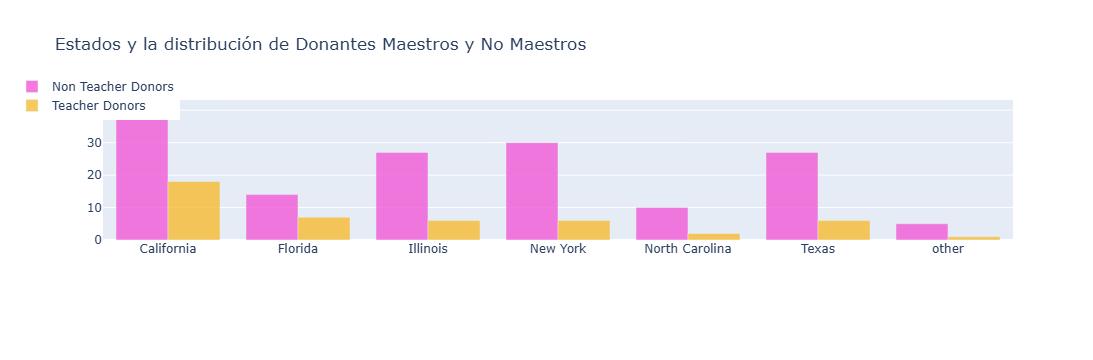

In [33]:
# which city and state has maximum teacher donors 
tempdf = donors_df.groupby(['Donor State', 'Donor Is Teacher']).agg({'Donor Is Teacher' : 'count' }).rename(columns={'Donor Is Teacher' : 'Teacher Donor Counts'}).reset_index()

no_df = tempdf[tempdf['Donor Is Teacher']=='No']
no_x = no_df['Donor State']
no_y = no_df['Teacher Donor Counts']
yes_df = tempdf[tempdf['Donor Is Teacher']=='Yes']
yes_x = yes_df['Donor State']
yes_y = yes_df['Teacher Donor Counts']

trace1 = go.Bar(
    x=no_x,
    y=no_y,
    name='Non Teacher Donors',
    marker=dict(color='#f259d6'),
    opacity=0.8
)
trace2 = go.Bar(
    x=yes_x,
    y=yes_y,
    name='Teacher Donors',
    marker=dict(color='#f7bb31'),
    opacity=0.8
)

data = [trace1, trace2]
layout = go.Layout(
    barmode='group',
    legend=dict(dict(x=-.1, y=1.2)),
    margin=dict(b=120),
    title = 'Estados y la distribución de Donantes Maestros y No Maestros',
)

fig = go.Figure(data=data, layout=layout)
iplot(fig, filename='grouped-bar')

> El número de donantes maestros siempre es muy bajo en todos los estados. Los registros con estado igual a "otros" tienen el mayor número de donantes maestros, igual a aprox. 28,000

## <a id="3"> 3. Exploración de las Donaciones </a>  

El archivo de donaciones incluye información sobre las donaciones realizadas por los donantes, el monto total de la donación, la secuencia del carrito del donante, la fecha, el proyecto y el ID del donante

## <a id="3.1"> 3.1 Vista Previa de las Donaciones </a> 

In [34]:
donations_df[['Donation ID', 'Donation Included Optional Donation', 'Donation Amount',
       'Donor Cart Sequence', 'Donation Received Date', 'Project ID', 'Donor ID']].head(3)
# donations_df.columns

# len(donations_df)
# len(donations_df[donations_df['Donation Amount'] > 20000]) / len(donations_df)
# len(donations_df[donations_df['Donation Amount'] > 10000]) / len(donations_df)
# len(donations_df[donations_df['Donation Amount'] < 1])
# np.mean(donations_df['Donation Amount'])

,Donation ID,Donation Included Optional Donation,Donation Amount,Donor Cart Sequence,Donation Received Date,Project ID,Donor ID
0,0f1259e0a18ff6b6b535106e122c9a56,No,2219.27,2,2016-06-10 07:17:42,a013ac6ededa4e161b3dbd5ce9a1fa6f,17fc695a07a0ca6e0822e8f36c031199
1,21df306f8a0b3c3336d8393a7c441fe7,Yes,44.02,8,2017-04-06 13:12:06,b09b2a5cbadcc32ac1590f538a0f4efb,366eb16f508ebad7b7c93acfe059a0ee
2,5ab33edf6e595ed3a8b317fa18d0752b,Yes,112.07,11,2016-10-31 20:06:03,5cec4eb5edd968311ca35cfb04fc6d82,aefcfad8efc89849b3aa7efe4458a885


Ha habido un total de **4,687,884 donaciones** hasta abril de 2018 en donorschoose. El monto donado más alto equivale a **USD 60,000**, donado en 2013. Solo **6 donaciones son mayores a USD 20,000** mientras que solo **61 pagos son mayores a USD 10,000**. La mayoría de los pagos (alrededor del **83%** de todas las donaciones) son **menores a USD 100**. Hay 350 pagos que son menores a USD 1 -> un monto pequeño, pero que aún puede marcar la diferencia. Hasta abril de 2018, DonorsChoose ha recaudado un monto total gigantesco igual a **USD 284,408,243** a través de su plataforma. El monto promedio donado en donorschoose equivale a USD 60. Veamos los detalles de los donantes y proyectos relacionados con estas donaciones en las siguientes secciones. 

## <a id="3.2"> 3.2 Proyectos y sus Donaciones </a>

Identifiquemos los principales proyectos y los valores de sus atributos relacionados: 

- 3.2.1 Proyectos con el mayor número de donantes 
- 3.2.2 Proyectos con los Montos Totales más Altos Financiados 
- 3.2.3 Proyectos con el Monto Promedio más Alto por Donante 
- 3.2.4 Proyectos con el Monto Máximo Donado en una sola donación 

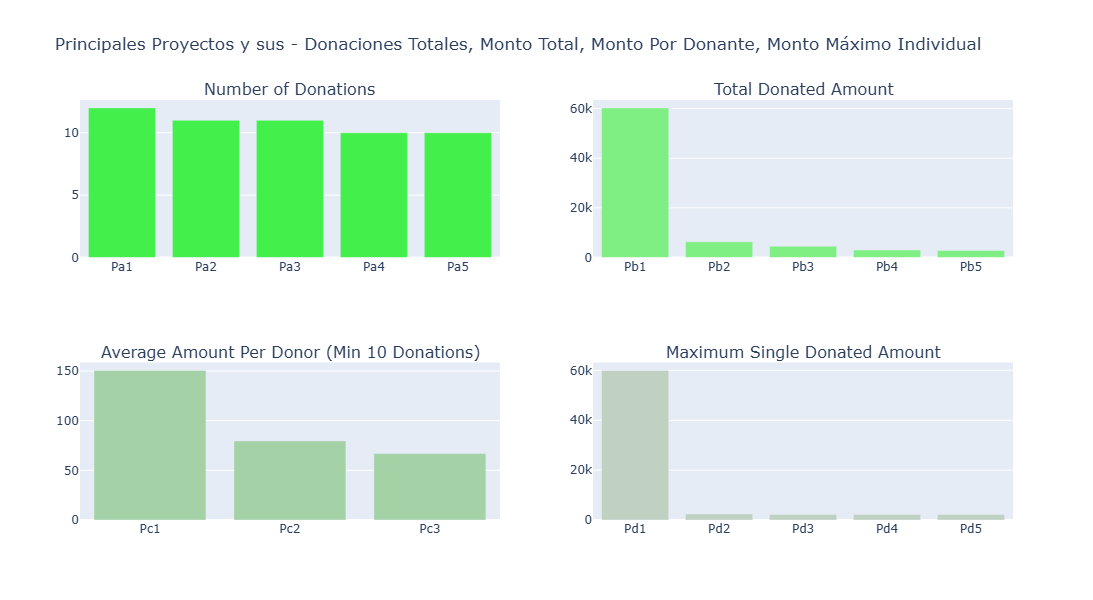

In [35]:
# Which Projects Had the maximum Donations 

tempdf = donations_df.groupby('Project ID').agg({'Project ID' : 'count', 'Donation Amount' : 'sum'}).rename(columns={'Project ID' : "Donaciones Totales", 'Donation Amount' : "Total Amount"}).reset_index()
tempdf['Average Donation Amount'] = tempdf['Total Amount'] / tempdf['Donaciones Totales']

tempdf1 = tempdf.sort_values(by=['Donaciones Totales'], ascending=[False])
x = tempdf1.head(5)['Project ID']
x = ["Pa"+str(i+1) for i in range(len(x))]
y = tempdf1.head(5)['Donaciones Totales']
tr1 = bar_ver_noagg(x, y, 'Donaciones Totales', '#43ef4b', lm=None, rt=True)

tempdf1 = tempdf.sort_values(by=['Total Amount'], ascending=[False])
x = tempdf1.head(5)['Project ID']
x = ["Pb"+str(i+1) for i in range(len(x))]
y = tempdf1.head(5)['Total Amount']
tr2 = bar_ver_noagg(x, y, 'Donaciones Promedio', '#7fef84', lm=None, rt=True)

tempdf1 = tempdf.sort_values(by=['Average Donation Amount'], ascending=[False])
x = tempdf1[tempdf1['Donaciones Totales'] > 10].head(5)['Project ID']
x = ["Pc"+str(i+1) for i in range(len(x))]
y = tempdf1[tempdf1['Donaciones Totales'] > 10].head(5)['Average Donation Amount']
tr3 = bar_ver_noagg(x, y, 'Average Donations (Min: 10 Donations)', '#a5d1a7', lm=None, rt=True)

tempdf = donations_df.groupby('Project ID').agg({'Project ID' : 'count', 'Donation Amount' : 'max'}).rename(columns={'Project ID' : "Donaciones Totales", 'Donation Amount' : "Donaciones Máximas"}).reset_index()
tempdf1 = tempdf.sort_values(by=['Donaciones Máximas'], ascending=[False])
x = tempdf1.head(5)['Project ID']
x = ["Pd"+str(i+1) for i in range(len(x))]
y = tempdf1.head(5)['Donaciones Máximas']
tr4 = bar_ver_noagg(x, y, 'Donaciones Máximas', '#c0d1c1', lm=None, rt=True)



fig = tools.make_subplots(rows=2, cols=2, print_grid=False, subplot_titles = ['Number of Donations', "Total Donated Amount", 'Average Amount Per Donor (Min 10 Donations)', 'Maximum Single Donated Amount'])
fig.append_trace(tr1, 1, 1);
fig.append_trace(tr2, 1, 2);
fig.append_trace(tr3, 2, 1);
fig.append_trace(tr4, 2, 2);

fig['layout'].update(height=600, showlegend=False, title='Principales Proyectos y sus - Donaciones Totales, Monto Total, Monto Por Donante, Monto Máximo Individual');
iplot(fig); 

> - **Proyectos Principales**  
> - En la historia de donorschoose, diferentes proyectos han recibido un número variable de donaciones, desde tan bajo como 1 hasta tan alto como 800 donaciones. El número máximo de donaciones hechas en un solo proyecto es igual a 863. Este fue un proyecto liderado por un maestro y su título fue "**Vallecito StandUpKids Pilot Standing School!**" (mostrado como Pa1 en la primera gráfica). El monto total igual a **USD 108,248.30** fue financiado en este proyecto y quedó completamente financiado el 26 de agosto de 2015.    
> - Hay otros tres proyectos con un número muy grande de donaciones (mayor a 600) 
> - En noviembre de 2016, se inició un proyecto titulado "**Varsity and After-School Fencing Teams in NYC**" (mostrado como Pc1 en la segunda gráfica) que tuvo 18 donaciones en total. Este proyecto tuvo el monto promedio más alto por donante, igual a **USD 1850**  
> - En el proyecto titulado "**Learning to Play While Playing to Learn!**" (mostrado como Pd1 en la cuarta gráfica), se donó el monto máximo en una sola donación, igual a **USD 60,000**, el cual es el monto de donación individual más alto en la historia de DonorsChoose.  

## <a id="3.3"> 3.3 Quiénes son los Principales Donantes : </a>

Identifiquemos a los donantes que hicieron algunas de las contribuciones principales y sus valores. Es decir: 
- 3.3.1 Donantes que han hecho el mayor número de donaciones  
- 3.3.2 Donantes que han financiado los Montos Totales más Altos   
-  3.3.3 Donantes con el Monto Promedio más Alto en donaciones individuales  
-  3.3.4 Donantes que han donado el Monto Máximo en una sola donación   

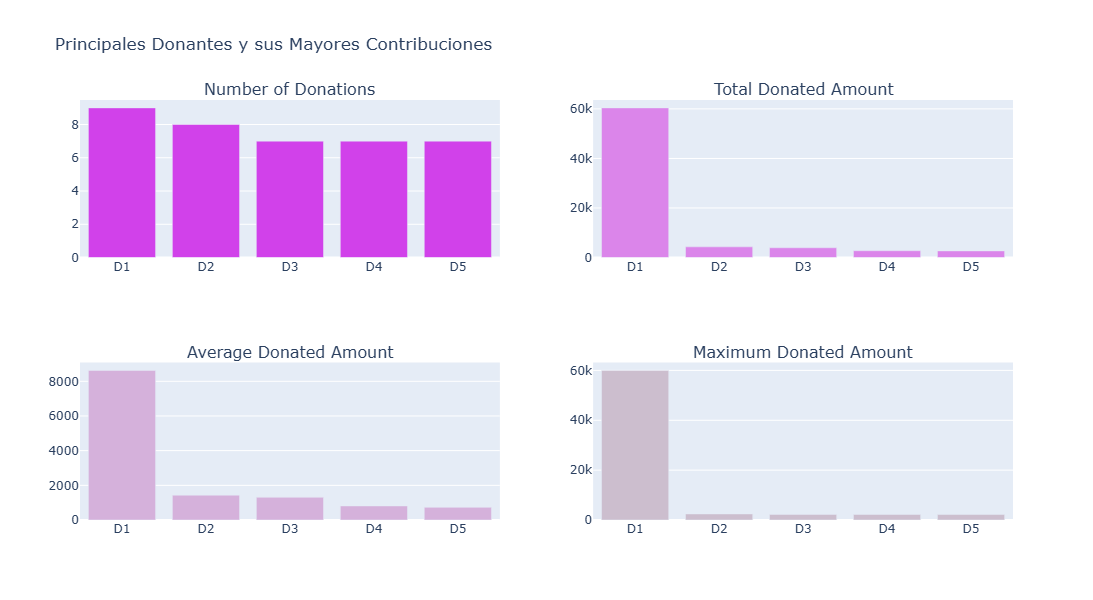

In [36]:
# Which Projects Had the maximum Donations 

tempdf = donations_df.groupby('Donor ID').agg({'Donor ID' : 'count', 'Donation Amount' : 'sum'}).rename(columns={'Donor ID' : "Donaciones Totales", 'Donation Amount' : "Total Amount"}).reset_index()
tempdf['Average Donation Amount'] = tempdf['Total Amount'] / tempdf['Donaciones Totales']

tempdf1 = tempdf.sort_values(by=['Donaciones Totales'], ascending=[False])
x = tempdf1.head(5)['Donor ID']
x = ["D"+str(i+1) for i in range(len(x))]
y = tempdf1.head(5)['Donaciones Totales']
tr1 = bar_ver_noagg(x, y, 'Donaciones Totales', '#d141ea', lm=None, rt=True)

tempdf1 = tempdf.sort_values(by=['Total Amount'], ascending=[False])
x = tempdf1.head(5)['Donor ID']
x = ["D"+str(i+1) for i in range(len(x))]
y = tempdf1.head(5)['Total Amount']
tr2 = bar_ver_noagg(x, y, 'Donaciones Promedio', '#db85ea', lm=None, rt=True)

tempdf1 = tempdf.sort_values(by=['Average Donation Amount'], ascending=[False])
x = tempdf1.head(5)['Donor ID']
x = ["D"+str(i+1) for i in range(len(x))]
y = tempdf1.head(5)['Average Donation Amount']
tr3 = bar_ver_noagg(x, y, 'Donaciones Promedio', '#d5b1db', lm=None, rt=True)

tempdf = donations_df.groupby('Donor ID').agg({'Donor ID' : 'count', 'Donation Amount' : 'max'}).rename(columns={'Donor ID' : "Donaciones Totales", 'Donation Amount' : "Donaciones Máximas"}).reset_index()
tempdf1 = tempdf.sort_values(by=['Donaciones Máximas'], ascending=[False])
x = tempdf1.head(5)['Donor ID']
x = ["D"+str(i+1) for i in range(len(x))]
y = tempdf1.head(5)['Donaciones Máximas']
tr4 = bar_ver_noagg(x, y, 'Donaciones Máximas', '#ccbece', lm=None, rt=True)

fig = tools.make_subplots(rows=2, cols=2, print_grid=False, subplot_titles = ['Number of Donations', "Total Donated Amount", 'Average Donated Amount', 'Maximum Donated Amount'])
fig.append_trace(tr1, 1, 1);
fig.append_trace(tr2, 1, 2);
fig.append_trace(tr3, 2, 1);
fig.append_trace(tr4, 2, 2);

fig['layout'].update(height=600, showlegend=False, title='Principales Donantes y sus Mayores Contribuciones');
iplot(fig); 

> - **Donantes Más Generosos: **
> - Un donante que no es maestro, de **Manhattan Beach, California**, ha donado más de **18,000 veces** (mostrado como D1 en la gráfica de la esquina superior izquierda) en donorschoose. Otro donante que no es maestro, de Nueva York, ha donado un monto total masivo igual a **1.8 millones de USD** en aproximadamente 10,513 donaciones (mostrado como D1 en la gráfica de la esquina superior derecha). 
> - El pago único más alto de **60K** para el proyecto "Learning to Play while Playing to Learn" fue realizado por un donante de **Anahola, Hawái**, quien ha hecho un total de 223 donaciones hasta ahora. 

## <a id="3.4"> 3.4 Qué Montos de Donación se recibieron y en qué momentos ? </a>

### Donaciones por Año 
 - 3.4.1 Número de Donaciones por Año 
 - 3.4.2 Monto Promedio de Donación por Año

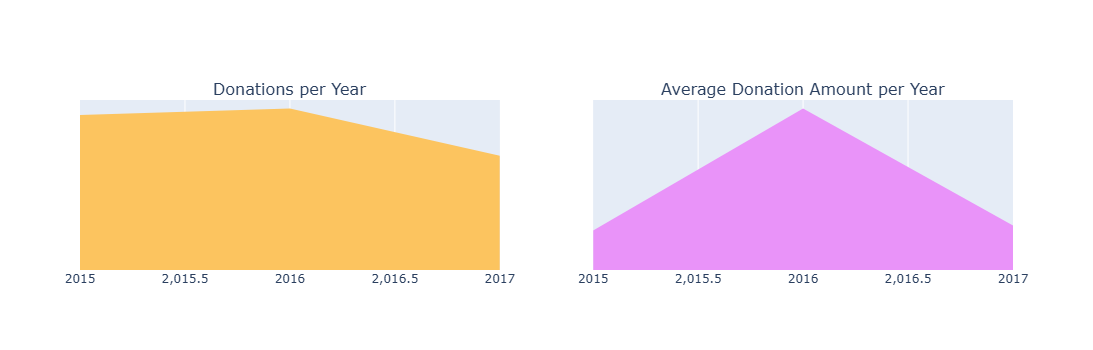

In [38]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from plotly.offline import iplot

# Convertir fechas
donations_df['Donation Date'] = pd.to_datetime(donations_df['Donation Received Date'])

donations_df['Donation Year'] = donations_df['Donation Date'].dt.year
donations_df['Donation Month'] = donations_df['Donation Date'].dt.month
donations_df['Donation Day'] = donations_df['Donation Date'].dt.day
donations_df['Donation Weekday'] = donations_df['Donation Date'].dt.weekday
donations_df['Donation Hour'] = donations_df['Donation Date'].dt.hour

# Agrupar datos
t1 = donations_df.groupby('Donation Year').agg(
    {
        'Donation Month':'count',
        'Donation Amount':'mean'
    }
).reset_index().rename(columns={
    'Donation Month':'Total Donations',
    'Donation Amount':'Average Amount'
})

# Crear figura
fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=("Donations per Year", "Average Donation Amount per Year")
)

fig.add_trace(
    go.Scatter(
        x=t1['Donation Year'],
        y=t1['Total Donations'],
        fill='tozeroy',
        fillcolor='#fcc45f',
        mode='none'
    ),
    row=1,
    col=1
)

fig.add_trace(
    go.Scatter(
        x=t1['Donation Year'],
        y=t1['Average Amount'],
        fill='tozeroy',
        fillcolor='#e993f9',
        mode='none'
    ),
    row=1,
    col=2
)

fig.update_layout(
    height=350,
    showlegend=False
)

fig.update_yaxes(
    showgrid=False,
    zeroline=False,
    showline=False,
    showticklabels=False
)

iplot(fig)

> Desde el año 2012, el número de donaciones en donorschoose ha aumentado de manera constante. Con cerca de 150 donaciones recibidas en 2012, donorschoose recibió aproximadamente **1.1 millones de donaciones** en el año 2017. El monto más alto recibido en 2017 fue igual a **USD 31,856**, el cual se recibió de un donante de **Lafayette, Colorado**. Esta donación se recibió el 02 de marzo de 2017.   
> En ese mismo año, se recibió un número gigantesco de donaciones de un donante de **Manhattan Beach, California**, quien realizó **13,751 donaciones**.   
> El monto promedio de donación recibido por año es cercano a **USD 60**, mientras que fue más alto en el año inicial, es decir 2012, igual a **USD 166**.  


### Donaciones por Mes 
- 3.4.3 Número de Donaciones por Mes 
- 3.4.4 Promedio de Donaciones por Mes

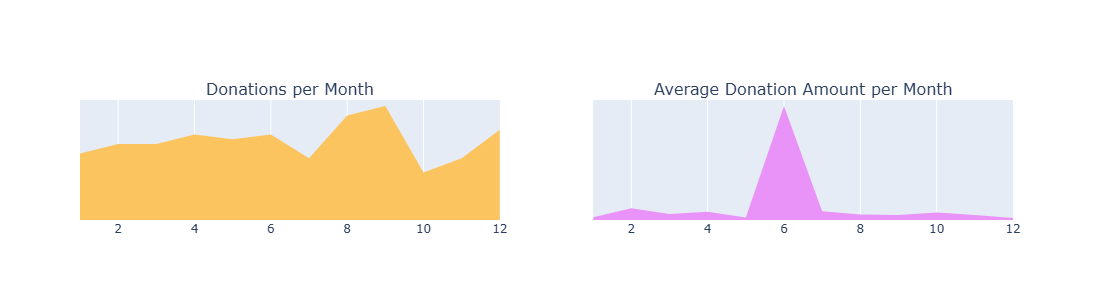

In [40]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from plotly.offline import iplot

# Agrupar por mes
t2 = donations_df.groupby('Donation Month').agg({
    'Donation Year': 'count',
    'Donation Amount': 'mean'
}).reset_index().rename(columns={
    'Donation Year': 'Donaciones Totales',
    'Donation Amount': 'Average Amount'
})

# Crear figura
fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=("Donations per Month", "Average Donation Amount per Month")
)

# Gráfico 1
fig.add_trace(
    go.Scatter(
        x=t2['Donation Month'],
        y=t2['Donaciones Totales'],
        fill='tozeroy',
        fillcolor='#fcc45f',
        mode='none'
    ),
    row=1,
    col=1
)

# Gráfico 2
fig.add_trace(
    go.Scatter(
        x=t2['Donation Month'],
        y=t2['Average Amount'],
        fill='tozeroy',
        fillcolor='#e993f9',
        mode='none'
    ),
    row=1,
    col=2
)

# Configuración del diseño
fig.update_layout(
    height=300,
    showlegend=False
)

# Configuración de ambos ejes Y
fig.update_yaxes(
    autorange=True,
    showgrid=False,
    zeroline=False,
    showline=False,
    ticks='',
    showticklabels=False
)

iplot(fig)

> - El mayor número de donaciones se recibe en el mes de **agosto con 577,274 donaciones**, seguido por el mes de **septiembre con 518,908 donaciones**, mientras que el menor número de donaciones se recibe en el mes de **junio, igual a 191,221 donaciones**, y el mes de **mayo, igual a 243,440 donaciones**, probablemente por el verano y el período vacacional. El monto promedio de donación más alto se recibe en el mes de diciembre con **USD 80**, mientras que el más bajo es en el mes de julio, igual a **USD 51**. En promedio, el monto de donación promedio por año es cercano a USD 59.

### Donaciones por Día del Mes 
- 3.4.5 Número de Donaciones por Día del Mes 
- 3.4.6 Promedio de Donaciones por Día del Mes

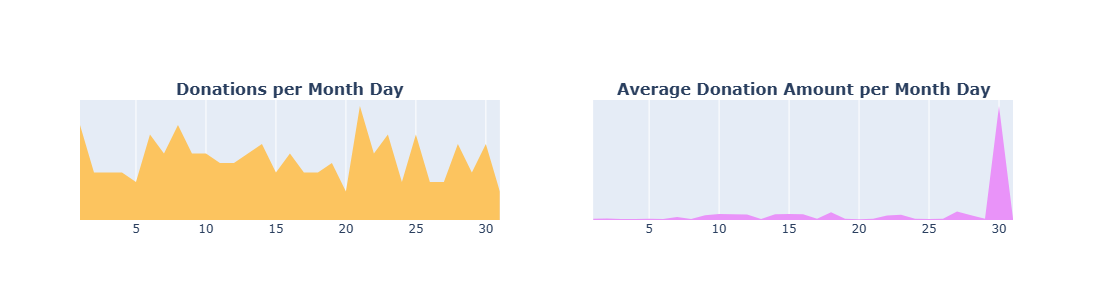

In [42]:

t3 = donations_df.groupby('Donation Day').agg({
    'Donation Year': 'count',
    'Donation Amount': 'mean'
}).reset_index().rename(columns={
    'Donation Year': 'Donaciones Totales',
    'Donation Amount': 'Average Amount'
})

x = t3['Donation Day']
y1 = t3['Donaciones Totales']
y2 = t3['Average Amount']

trace1 = go.Scatter(
    x=x,
    y=y1,
    fill='tozeroy',
    fillcolor='#fcc45f',
    mode='none'
)

trace2 = go.Scatter(
    x=x,
    y=y2,
    fill='tozeroy',
    fillcolor='#e993f9',
    mode='none'
)

fig = tools.make_subplots(
    rows=1,
    cols=2,
    subplot_titles=[
        "<b>Donations per Month Day</b>",
        "<b>Average Donation Amount per Month Day</b>"
    ]
)

fig.add_trace(trace1, row=1, col=1)
fig.add_trace(trace2, row=1, col=2)

fig.update_layout(
    height=300,
    showlegend=False
)

fig.update_yaxes(
    autorange=True,
    showgrid=False,
    zeroline=False,
    showline=False,
    ticks='',
    showticklabels=False,
    row=1,
    col=1
)

fig.update_yaxes(
    autorange=True,
    showgrid=False,
    zeroline=False,
    showline=False,
    ticks='',
    showticklabels=False,
    row=1,
    col=2
)

iplot(fig)


### Donaciones por Día de la Semana 
- 3.4.7 Número de Donaciones por Día de la Semana 
- 3.4.8 Promedio de Donaciones por Día de la Semana

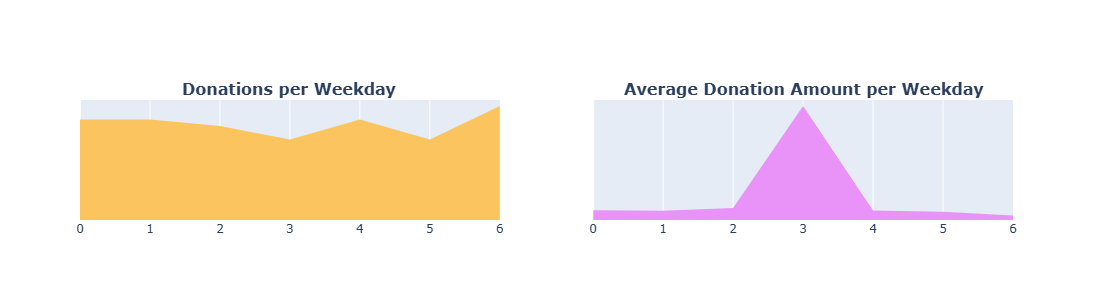

In [44]:

t4 = donations_df.groupby('Donation Weekday').agg({
    'Donation Year': 'count',
    'Donation Amount': 'mean'
}).reset_index().rename(columns={
    'Donation Year': 'Donaciones Totales',
    'Donation Amount': 'Average Amount'
})

x = t4['Donation Weekday']
y1 = t4['Donaciones Totales']
y2 = t4['Average Amount']

trace1 = go.Scatter(
    x=x,
    y=y1,
    fill='tozeroy',
    fillcolor='#fcc45f',
    mode='none'
)

trace2 = go.Scatter(
    x=x,
    y=y2,
    fill='tozeroy',
    fillcolor='#e993f9',
    mode='none'
)

fig = tools.make_subplots(
    rows=1,
    cols=2,
    subplot_titles=[
        "<b>Donations per Weekday</b>",
        "<b>Average Donation Amount per Weekday</b>"
    ]
)

fig.add_trace(trace1, row=1, col=1)
fig.add_trace(trace2, row=1, col=2)

fig.update_layout(
    height=300,
    showlegend=False
)

fig.update_yaxes(
    autorange=True,
    showgrid=False,
    zeroline=False,
    showline=False,
    ticks='',
    showticklabels=False,
    row=1,
    col=1
)

fig.update_yaxes(
    autorange=True,
    showgrid=False,
    zeroline=False,
    showline=False,
    ticks='',
    showticklabels=False,
    row=1,
    col=2
)

iplot(fig)

> El número de donaciones es más alto en los días iniciales de la semana, es decir, lunes, martes y miércoles, con 700K, 800K y 750K donaciones totales, y el conteo disminuye con los siguientes días de la semana. El número más bajo de donaciones se recibe los sábados, como se observa en la gráfica. 

### Donaciones por Hora 
- 3.4.9 Número de Donaciones por Hora 
- 3.4.10 Promedio de Donaciones por Hora

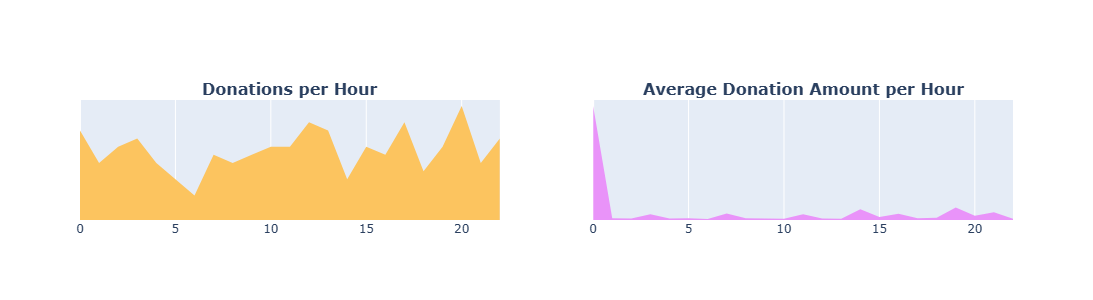

In [46]:
t5 = donations_df.groupby('Donation Hour').agg({
    'Donation Month': 'count',
    'Donation Amount': 'mean'
}).reset_index().rename(columns={
    'Donation Month': 'Donaciones Totales',
    'Donation Amount': 'Average Amount'
})

x = t5['Donation Hour']
y1 = t5['Donaciones Totales']
y2 = t5['Average Amount']

trace1 = go.Scatter(
    x=x[:-1],
    y=y1[:-1],
    fill='tozeroy',
    fillcolor='#fcc45f',
    mode='none'
)

trace2 = go.Scatter(
    x=x[:-1],
    y=y2[:-1],
    fill='tozeroy',
    fillcolor='#e993f9',
    mode='none'
)

fig = tools.make_subplots(
    rows=1,
    cols=2,
    subplot_titles=[
        "<b>Donations per Hour</b>",
        "<b>Average Donation Amount per Hour</b>"
    ]
)

fig.add_trace(trace1, row=1, col=1)
fig.add_trace(trace2, row=1, col=2)

fig.update_layout(
    height=300,
    showlegend=False
)

fig.update_yaxes(
    autorange=True,
    showgrid=False,
    zeroline=False,
    showline=False,
    ticks='',
    showticklabels=False,
    row=1,
    col=1
)

fig.update_yaxes(
    autorange=True,
    showgrid=False,
    zeroline=False,
    showline=False,
    ticks='',
    showticklabels=False,
    row=1,
    col=2
)

iplot(fig)


## <a id="3.5"> 3.5 Donaciones Opcionales y Donantes Maestros </a>

### <a id="3.5.1"> 3.5.1 Total de Donaciones Opcionales y sus Montos Promedio Asociados </a> 

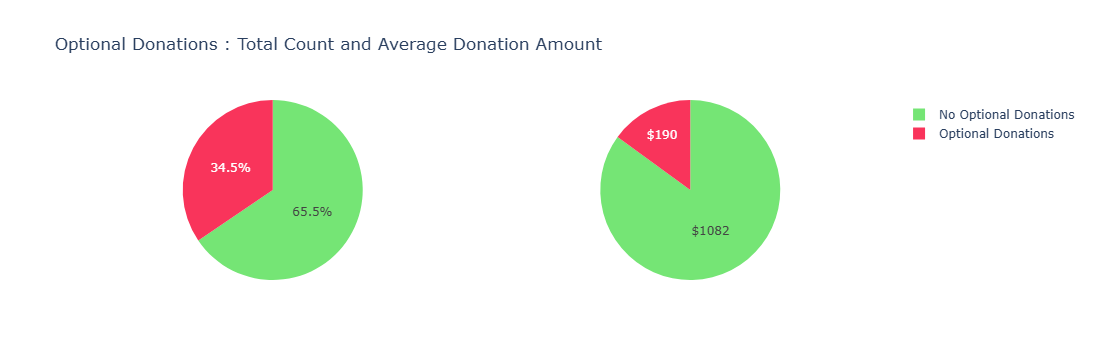

In [47]:
tempdf = donations_df.groupby('Donation Included Optional Donation').agg({'Donation Included Optional Donation' : 'count', 'Donation Amount' : 'mean'})
values1 = list(tempdf['Donation Included Optional Donation']) 
values2 = list(tempdf['Donation Amount']) 
values2t = [str("$")+str(int(x)) for x in values2]
domain1 = {'x': [0.2, 0.50], 'y': [0.0, 0.33]}
domain2 = {'x': [0.8, 0.50], 'y': [0.0, 0.33]}

labels = list(tempdf.index)
mp={'Yes' : 'Optional Donations', 'No' : 'No Optional Donations'}
labels = [mp[x] for x in labels]
trace1 = go.Pie(labels=labels, values=values1, marker=dict(colors=[  '#75e575', '#ea7c96',]))
trace2 = go.Pie(labels=labels, values=values2, marker=dict(colors=['#75e575', '#ea7c96',]), textinfo = "text", text=values2t)

layout = go.Layout(title='Número de Donaciones con Donaciones Opcionales', width=800, height=400)
# fig = go.Figure(data=[trace1], layout=layout)
# iplot(fig)

layout = go.Layout(title='Monto Promedio Donado en Donaciones Opcionales', width=800, height=400)
# fig = go.Figure(data=[trace2], layout=layout)
# iplot(fig)

fig = {
  "data": [
    {
      "values": values1,
      "labels": list(reversed(labels)),
      "domain": {"x": [0, .48]},
    "marker" : dict(colors=[  '#f9345b',  '#75e575']),
      "name": "No. of donations with Optional Donations",
#       "hoverinfo":"label+percent+name",
#       "hole": .4,
        
      "type": "pie"
    },
    {
      "values": values2,
      "labels": labels,
        "marker" : dict(colors=['75e575', '#f9345b']),
      "domain": {"x": [.52, 1]},
      "name": "Monto Promedio Donado en Donaciones Opcionales",
        "text" : values2t,
        "textinfo" : "text",
      "type": "pie"
    }],
  "layout": {
        "title":"Optional Donations : Total Count and Average Donation Amount",
    
    }
}
iplot(fig, filename='donut')

> - Los proyectos de DonorsChoose también tienen la opción de Donaciones Opcionales. El monto promedio de donación para las donaciones opcionales es de **USD 58**, mientras que es de **USD 73** para las donaciones no opcionales. De todas las donaciones realizadas, aproximadamente el **15%** fueron donaciones opcionales 

### <a href="3.5.2"> 3.5.2 Total de Donaciones de Donantes Maestros y sus Montos Promedio Asociados  </a>  

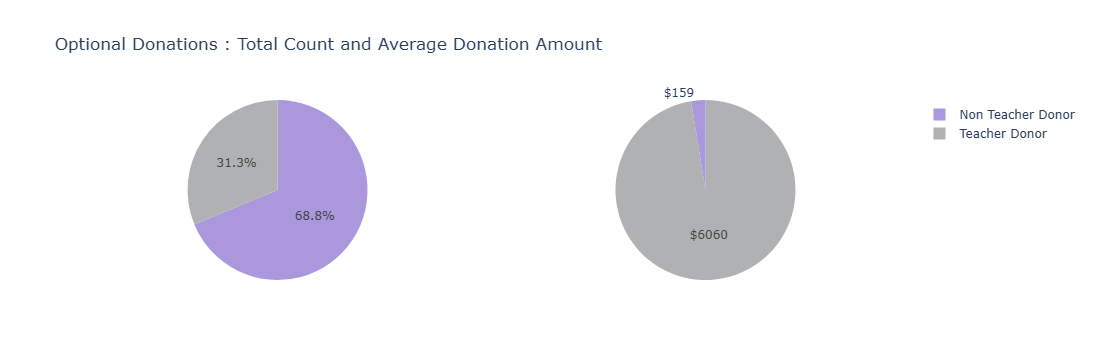

In [48]:
# lets combine donors and donations 
combined_df = donations_df.merge(donors_df, on='Donor ID', how='inner')
# combined_df.head(10)

tempdf = combined_df.groupby('Donor Is Teacher').agg({'Donor Is Teacher' : 'count', 'Donation Amount' : 'mean'})
values1 = list(tempdf['Donor Is Teacher']) 
values2 = list(tempdf['Donation Amount']) 
values2t = [str("$")+str(int(x)) for x in values2]
domain1 = {'x': [0.2, 0.50], 'y': [0.0, 0.33]}
domain2 = {'x': [0.8, 0.50], 'y': [0.0, 0.33]}

labels = list(tempdf.index)
mp={'Yes' : 'Teacher Donor', 'No' : 'Non Teacher Donor'}
labels = [mp[x] for x in labels]
trace1 = go.Pie(labels=labels, values=values1, marker=dict(colors=[  '#75e575', '#ea7c96',]))
trace2 = go.Pie(labels=labels, values=values2, marker=dict(colors=['#75e575', '#ea7c96',]), textinfo = "text", text=values2t)

layout = go.Layout(title='Número de Donaciones con Donaciones Opcionales', width=800, height=400)
# fig = go.Figure(data=[trace1], layout=layout)
# iplot(fig)

layout = go.Layout(title='Monto Promedio Donado en Donaciones Opcionales', width=800, height=400)
# fig = go.Figure(data=[trace2], layout=layout)
# iplot(fig)

fig = {
  "data": [
    {
      "values": values1,
      "labels": labels,
      "domain": {"x": [0, .48]},
    "marker" : dict(colors=[ '#ab97db',  '#b0b1b2']),
      "name": "No. of donations with Optional Donations",
#       "hoverinfo":"label+percent+name",
#       "hole": .4,
        
      "type": "pie"
    },
    {
      "values": values2,
      "labels": labels,
        "marker" : dict(colors=[ '#ab97db',  '#b0b1b2']),
      "domain": {"x": [.52, 1]},
      "name": "Monto Promedio Donado en Donaciones Opcionales",
        "text" : values2t,
        "textinfo" : "text",
      "type": "pie"
    }],
  "layout": {
        "title":"Optional Donations : Total Count and Average Donation Amount",
    
    }
}
iplot(fig, filename='donut')

> - Aproximadamente el **29%** del total de donaciones en DonorsChoose son realizadas por donantes que también son maestros. La mayoría de estos donantes maestros son de California. 
> - El monto promedio de donación de un maestro es de **USD 45**, mientras que es de **USD 66** para los donantes que no son maestros.

In [50]:

def mapp(df, scl, t):
    state_to_code = {'District of Columbia' : 'dc','Mississippi': 'MS', 'Oklahoma': 'OK', 'Delaware': 'DE', 'Minnesota': 'MN', 'Illinois': 'IL', 'Arkansas': 'AR', 'New Mexico': 'NM', 'Indiana': 'IN', 'Maryland': 'MD', 'Louisiana': 'LA', 'Idaho': 'ID', 'Wyoming': 'WY', 'Tennessee': 'TN', 'Arizona': 'AZ', 'Iowa': 'IA', 'Michigan': 'MI', 'Kansas': 'KS', 'Utah': 'UT', 'Virginia': 'VA', 'Oregon': 'OR', 'Connecticut': 'CT', 'Montana': 'MT', 'California': 'CA', 'Massachusetts': 'MA', 'West Virginia': 'WV', 'South Carolina': 'SC', 'New Hampshire': 'NH', 'Wisconsin': 'WI', 'Vermont': 'VT', 'Georgia': 'GA', 'North Dakota': 'ND', 'Pennsylvania': 'PA', 'Florida': 'FL', 'Alaska': 'AK', 'Kentucky': 'KY', 'Hawaii': 'HI', 'Nebraska': 'NE', 'Missouri': 'MO', 'Ohio': 'OH', 'Alabama': 'AL', 'Rhode Island': 'RI', 'South Dakota': 'SD', 'Colorado': 'CO', 'New Jersey': 'NJ', 'Washington': 'WA', 'North Carolina': 'NC', 'New York': 'NY', 'Texas': 'TX', 'Nevada': 'NV', 'Maine': 'ME'}
    df['state_code'] = statesdf['state'].apply(lambda x : state_to_code[x] if x in state_to_code else "")

    data = [ dict(
            type='choropleth',
            colorscale = scl,
            autocolorscale = False,
            locations = df['state_code'],
            z = df['counts'],
            locationmode = 'USA-states',
            text = df['state'],
            marker = dict(
                line = dict (
                    color = 'rgb(255,255,255)',
                    width = 2
                ) ),
            colorbar = dict(
                title = "Donantes")
            ) ]

    layout = dict(
            title = t,
            geo = dict(
                scope='usa',
                projection=dict( type='albers usa' ),
                showlakes = True,
                lakecolor = 'rgb(255, 255, 255)'),
                 )

    fig = dict( data=data, layout=layout )
    iplot( fig, filename='d3-cloropleth-map' )

## <a id="3.6"> 3.6 Qué Estados recibieron los Montos de Donación Individual más Altos</a>   
- 3.6.1 Estados principales con los Montos de Donación más Altos  
- 3.6.2 Ciudades principales con los Montos de Donación más Altos   

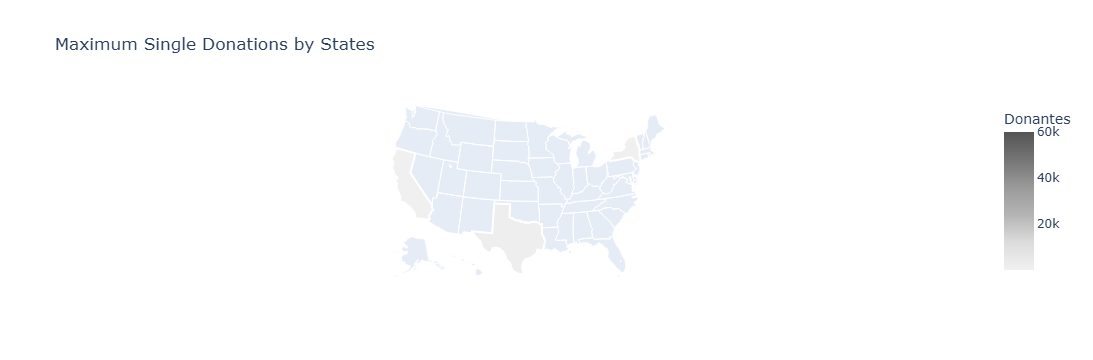

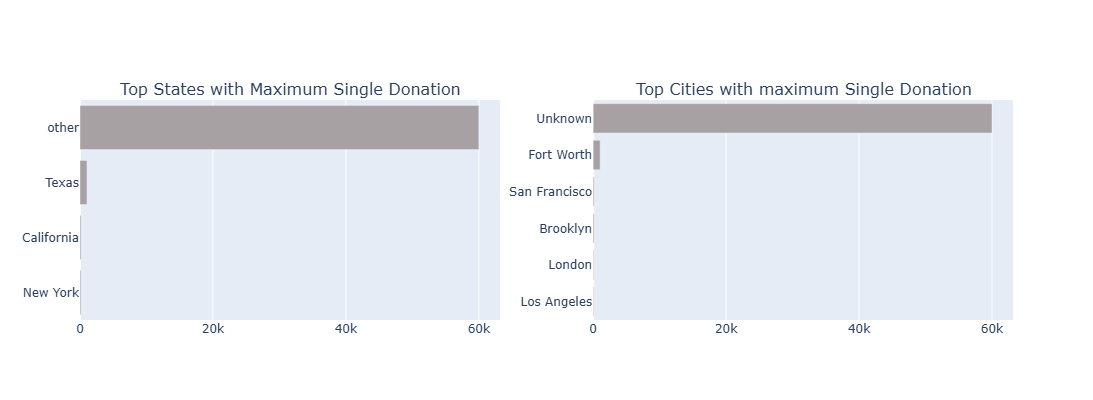

In [51]:
# Maximum Donation Amounts 
tempdf = combined_df.groupby(['Donor State']).agg({'Donation Amount':'max'}).reset_index()
t1 = tempdf.sort_values('Donation Amount', ascending=False)

tempdf = combined_df.groupby(['Donor City']).agg({'Donation Amount':'max'}).reset_index()
t2 = tempdf.sort_values('Donation Amount', ascending=False)

statesdf = pd.DataFrame()
statesdf['state'] = t1['Donor State']
statesdf['counts'] = t1['Donation Amount']
statesdf

citydf = pd.DataFrame()
citydf['state'] = t2['Donor City']
citydf['counts'] = t2['Donation Amount']
citydf


scl = [[0.0, 'rgb(240,240,240)'],[0.2, 'rgb(220,220,220)'],[0.4, 'rgb(180,180,180)'], [0.6, 'rgb(154,154,154)'],[0.8, 'rgb(117,117,117)'],[1.0, 'rgb(84,84,84)']]
mapp(statesdf, scl, 'Maximum Single Donations by States')

trace1 = bar_hor_noagg(list(reversed(list(statesdf['state'][:10]))), list(reversed(list(statesdf['counts'][:10]))), "Principales Ciudades con más Donantes", '#a8a1a3', 600, 400, 200, limit = 10, rt=True)
trace2 = bar_hor_noagg(list(reversed(list(citydf['state'][:10]))), list(reversed(list(citydf['counts'][:10]))), "Principales Estados con más Donantes", '#a8a1a3', 600, 400, 200, limit = 10, rt=True)
fig = tools.make_subplots(rows=1, cols=2, print_grid=False, subplot_titles = ['Top States with Maximum Single Donation','Top Cities with maximum Single Donation'])
fig.append_trace(trace1, 1, 1);
fig.append_trace(trace2, 1, 2);
fig['layout'].update(height=400, showlegend=False);
iplot(fig);


> - Hawái y Colorado son los estados que, aunque tienen un menor número de donaciones, reciben los montos de donación más altos 
> - Ciudades: Anahola, Lafayette y Palo Alto han contribuido con los montos más altos: 60K, 31K y 26K 

## <a id="3.7"> 3.7 Qué Estado recibe los Montos Promedio de Donación más Altos</a>  

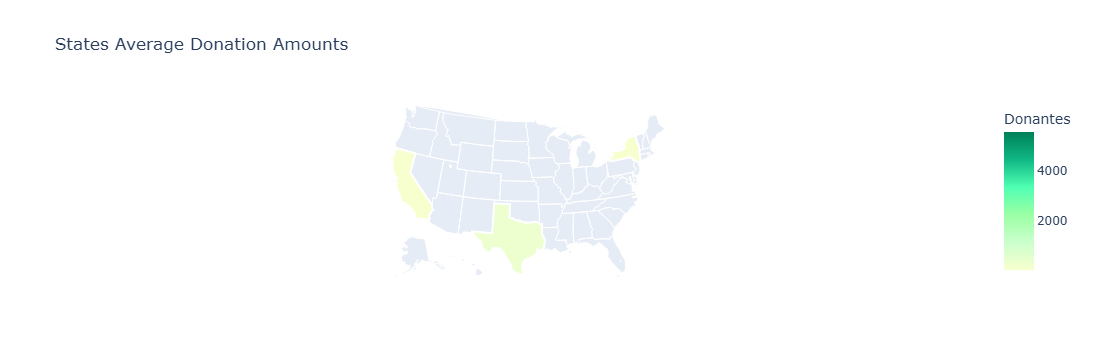

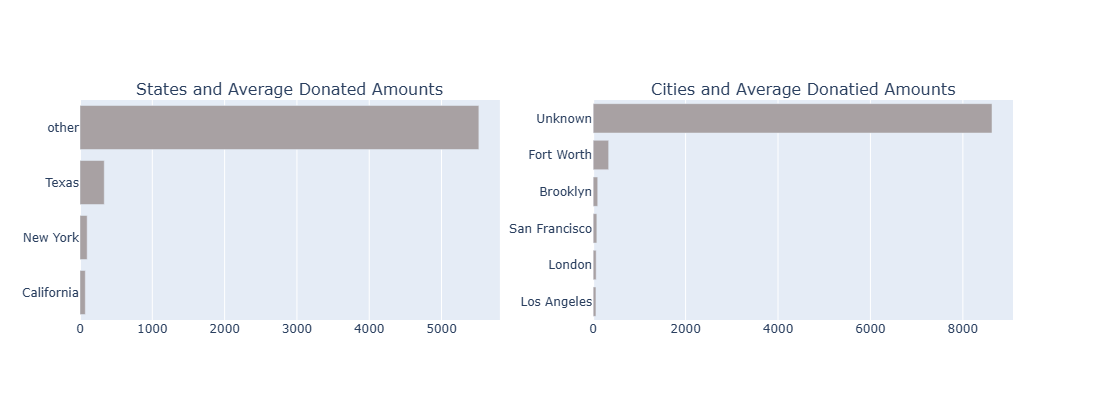

In [52]:
# Mean Donation Amounts 
tempdf = combined_df.groupby(['Donor State']).agg({'Donation Amount':'mean'}).reset_index()
t1 = tempdf.sort_values('Donation Amount', ascending=False)

tempdf = combined_df.groupby(['Donor City']).agg({'Donation Amount':'mean'}).reset_index()
t2 = tempdf.sort_values('Donation Amount', ascending=False)

statesdf = pd.DataFrame()
statesdf['state'] = t1['Donor State']
statesdf['counts'] = t1['Donation Amount']
statesdf

citydf = pd.DataFrame()
citydf['state'] = t2['Donor City']
citydf['counts'] = t2['Donation Amount']
citydf
scl = [[0.0, 'rgb(248,255,206)'],[0.2, 'rgb(203,255,205)'],[0.4, 'rgb(155,255,164)'], [0.6, 'rgb(79,255,178)'],[0.8, 'rgb(15,183,132)'], [1, '#008059']]
# scl = [[0.0, 'rgb(240,240,240)'],[0.2, 'rgb(220,220,220)'],[0.4, 'rgb(180,180,180)'], [0.6, 'rgb(154,154,154)'],[0.8, 'rgb(117,117,117)'],[1.0, 'rgb(84,84,84)']]
mapp(statesdf, scl, 'States Average Donation Amounts')

trace1 = bar_hor_noagg(list(reversed(list(statesdf['state'][:10]))), list(reversed(list(statesdf['counts'][:10]))), "Principales Ciudades con más Donantes", '#a8a1a3', 600, 400, 200, limit = 10, rt=True)
trace2 = bar_hor_noagg(list(reversed(list(citydf['state'][:10]))), list(reversed(list(citydf['counts'][:10]))), "Principales Estados con más Donantes", '#a8a1a3', 600, 400, 200, limit = 10, rt=True)
fig = tools.make_subplots(rows=1, cols=2, print_grid=False, subplot_titles = ['States and Average Donated Amounts','Cities and Average Donatied Amounts'])
fig.append_trace(trace1, 1, 1);
fig.append_trace(trace2, 1, 2);
fig['layout'].update(height=400, showlegend=False);
iplot(fig);

> - Hawái y Massachusetts tienen los montos promedio de donación más altos   
> - Clarks Point, Swiftwater y North English son las ciudades de las que se reciben los montos promedio de donación más altos  

## <a id="3.8"> 3.8 Montos Totales Donados por cada Estado </a> 

In [58]:
statesll.seek(0)
print(statesll.read()[:200])

State,Latitude,Longitude




In [69]:
state_donations = combined_df.groupby('Donor State')['Donation Amount'].sum().reset_index()

state_donations

,Donor State,Donation Amount
0,California,880.73
1,New York,198.22
2,Texas,2347.83
3,other,60676.69


In [71]:
state_coords = {
    "California":[36.7783,-119.4179],
    "Texas":[31.9686,-99.9018],
    "New York":[43.2994,-74.2179]
}

In [72]:
state_donations = state_donations[
    state_donations['Donor State'].isin(state_coords.keys())
]

In [74]:
combined_df.columns

Index(['Project ID', 'Donation ID', 'Donor ID',
       'Donation Included Optional Donation', 'Donation Amount',
       'Donor Cart Sequence', 'Donation Received Date', 'Donation Date',
       'Donation Year', 'Donation Month', 'Donation Day', 'Donation Weekday',
       'Donation Hour', 'Donor City', 'Donor State', 'Donor Is Teacher',
       'Donor Zip'],
      dtype='object')

In [75]:
combined_df.head()

,Project ID,Donation ID,Donor ID,Donation Included Optional Donation,Donation Amount,Donor Cart Sequence,Donation Received Date,Donation Date,Donation Year,Donation Month,Donation Day,Donation Weekday,Donation Hour,Donor City,Donor State,Donor Is Teacher,Donor Zip
0,3da9c2a90ed42f1a3d4cbf374eb93eff,958ca9ba0cd620c20ea2622b504867ba,0e51f30dc6a7ee39c4b032ccd7c524a5,No,84.36,1,2017-09-10 16:05:54,2017-09-10 16:05:54,2017,9,10,6,16,Los Angeles,California,No,420
1,5715bd6fa4161293c4c2e2e3444ea7c8,0d01280fd89a40c0e87d1c78e7c421c7,bf3c4c06434308bc89fa6a688fb5d27b,Yes,48.74,1,2015-12-08 04:40:16,2015-12-08 04:40:16,2015,12,8,1,4,Fort Worth,Texas,No,234
2,f4188f3f8a14be62295b4715c333e861,9e87e04ca2086977a9f2533683f4a9a9,9a1de644815ef6d13b8faa1837f8a88b,No,115.16,11,2015-11-14 07:51:12,2015-11-14 07:51:12,2015,11,14,5,7,San Francisco,California,No,728
3,3da9c2a90ed42f1a3d4cbf374eb93eff,8573e793c715b2b9c40c5d9146fde062,bf3c4c06434308bc89fa6a688fb5d27b,Yes,71.58,12,2015-10-20 07:17:21,2015-10-20 07:17:21,2015,10,20,1,7,Fort Worth,Texas,No,234
4,3da9c2a90ed42f1a3d4cbf374eb93eff,6160a6b49360715fc3fe0183e172b725,bdd640fb06671ad11c80317fa3b1799d,No,51.81,7,2017-05-23 13:34:47,2017-05-23 13:34:47,2017,5,23,1,13,San Francisco,California,Yes,114


In [76]:
city_donations = (
    combined_df
    .groupby(['Donor City','Donor State'])
    ['Donation Amount']
    .sum()
    .reset_index()
)

city_donations.head()

,Donor City,Donor State,Donation Amount
0,Brooklyn,New York,198.22
1,Fort Worth,Texas,2347.83
2,London,other,261.60
3,Los Angeles,California,241.29
4,San Francisco,California,639.44


In [77]:
!pip install geopy


   ---------------------------------------- 0/2 [geographiclib]
   -------------------- ------------------- 1/2 [geopy]
   -------------------- ------------------- 1/2 [geopy]
   ---------------------------------------- 2/2 [geopy]



In [78]:
from geopy.geocoders import Nominatim
import time

geolocator = Nominatim(user_agent="donation_map")

In [79]:
def get_location(city, state):
    try:
        location = geolocator.geocode(f"{city}, {state}, USA")
        if location:
            return pd.Series([location.latitude, location.longitude])
    except:
        pass
    
    return pd.Series([None,None])

In [80]:
city_donations[['latitude','longitude']] = city_donations.apply(
    lambda x: get_location(x['Donor City'], x['Donor State']),
    axis=1
)

In [81]:
city_donations.dropna().shape

(4, 5)

In [88]:
combined_df['Donor City'].nunique()

6

In [90]:
print(donors_df.shape)
print(donors_df['Donor State'].nunique())

(200, 5)
7


In [83]:
combined_df['Donor State'].value_counts()

Donor State
California    12
other         11
Texas          7
New York       2
Name: count, dtype: int64

In [84]:
combined_df.shape

(32, 17)

In [85]:
donors_df['Donor State'].nunique()

7

In [91]:
donors_df['Donor State'].value_counts()

Donor State
California        59
New York          36
Texas             33
Illinois          33
Florida           21
North Carolina    12
other              6
Name: count, dtype: int64

In [92]:
donors_df['Donor City'].nunique()

35

In [95]:
donors_df['Donor State'].value_counts()

Donor State
California        59
New York          36
Texas             33
Illinois          33
Florida           21
North Carolina    12
other              6
Name: count, dtype: int64

In [96]:
donors_df.head()

,Donor ID,Donor City,Donor State,Donor Is Teacher,Donor Zip
0,bdd640fb06671ad11c80317fa3b1799d,San Francisco,California,Yes,114
1,8b9d2434e465e150bd9c66b3ad3c2d6d,San Jose,California,Yes,105
2,9a1de644815ef6d13b8faa1837f8a88b,San Francisco,California,No,728
3,72ff5d2a386ecbe06b65a6a48b8148f6,Houston,Texas,No,173
4,47229389571aa8766c307511b2b9437a,San Diego,California,Yes,399


In [97]:
donations_state = combined_df.merge(
    donors_df[['Donor ID','Donor State']],
    on='Donor ID',
    how='left'
)

In [98]:
donations_state.head()

,Project ID,Donation ID,Donor ID,Donation Included Optional Donation,Donation Amount,Donor Cart Sequence,Donation Received Date,Donation Date,Donation Year,Donation Month,Donation Day,Donation Weekday,Donation Hour,Donor City,Donor State_x,Donor Is Teacher,Donor Zip,Donor State_y
0,3da9c2a90ed42f1a3d4cbf374eb93eff,958ca9ba0cd620c20ea2622b504867ba,0e51f30dc6a7ee39c4b032ccd7c524a5,No,84.36,1,2017-09-10 16:05:54,2017-09-10 16:05:54,2017,9,10,6,16,Los Angeles,California,No,420,California
1,5715bd6fa4161293c4c2e2e3444ea7c8,0d01280fd89a40c0e87d1c78e7c421c7,bf3c4c06434308bc89fa6a688fb5d27b,Yes,48.74,1,2015-12-08 04:40:16,2015-12-08 04:40:16,2015,12,8,1,4,Fort Worth,Texas,No,234,Texas
2,f4188f3f8a14be62295b4715c333e861,9e87e04ca2086977a9f2533683f4a9a9,9a1de644815ef6d13b8faa1837f8a88b,No,115.16,11,2015-11-14 07:51:12,2015-11-14 07:51:12,2015,11,14,5,7,San Francisco,California,No,728,California
3,3da9c2a90ed42f1a3d4cbf374eb93eff,8573e793c715b2b9c40c5d9146fde062,bf3c4c06434308bc89fa6a688fb5d27b,Yes,71.58,12,2015-10-20 07:17:21,2015-10-20 07:17:21,2015,10,20,1,7,Fort Worth,Texas,No,234,Texas
4,3da9c2a90ed42f1a3d4cbf374eb93eff,6160a6b49360715fc3fe0183e172b725,bdd640fb06671ad11c80317fa3b1799d,No,51.81,7,2017-05-23 13:34:47,2017-05-23 13:34:47,2017,5,23,1,13,San Francisco,California,Yes,114,California


In [101]:
donations_state.columns

Index(['Project ID', 'Donation ID', 'Donor ID',
       'Donation Included Optional Donation', 'Donation Amount',
       'Donor Cart Sequence', 'Donation Received Date', 'Donation Date',
       'Donation Year', 'Donation Month', 'Donation Day', 'Donation Weekday',
       'Donation Hour', 'Donor City', 'Donor State_x', 'Donor Is Teacher',
       'Donor Zip', 'Donor State_y'],
      dtype='object')

In [102]:
state_total = (
    donations_state
    .groupby('Donor State_y')['Donation Amount']
    .sum()
    .reset_index()
)

state_total

,Donor State_y,Donation Amount
0,California,880.73
1,New York,198.22
2,Texas,2347.83
3,other,60676.69


In [103]:
state_total = (
    donations_state
    .groupby('Donor State_x')['Donation Amount']
    .sum()
    .reset_index()
)

state_total

,Donor State_x,Donation Amount
0,California,880.73
1,New York,198.22
2,Texas,2347.83
3,other,60676.69


In [106]:
state_total['Donor State'].unique()

array(['California', 'New York', 'Texas', 'other'], dtype=object)

In [107]:
state_total['Donor State'] = state_total['Donor State'].str.strip()

In [62]:
print(combined_df['Donor State'].unique())
print(combined_df['Donor State'].value_counts())

['California' 'Texas' 'other' 'New York']
Donor State
California    12
other         11
Texas          7
New York       2
Name: count, dtype: int64


In [63]:
tempdf = combined_df.groupby('Donor State').agg({
    'Donation Amount':'sum'
}).reset_index()

print(tempdf)

  Donor State  Donation Amount
0  California           880.73
1    New York           198.22
2       Texas          2347.83
3       other         60676.69


In [64]:
statesll.seek(0)

sdf = pd.read_csv(statesll).rename(columns={'State':'Donor State'})
sdf = sdf.merge(tempdf, on='Donor State', how='inner')

print(sdf)
print(len(sdf))

  Donor State   Latitude   Longitude  Donation Amount
0  California  36.116203 -119.681564           880.73
1    New York  42.165726  -74.948051           198.22
2       Texas  31.054487  -97.563461          2347.83
3


In [66]:
print(combined_df['Donor State'].nunique())
print(combined_df['Donor State'].unique())

4
['California' 'Texas' 'other' 'New York']


In [67]:
florida.shape

(0, 4)

In [68]:
california = combined_df[combined_df['Donor State']=="California"]

print(california.shape)
california.head()

(12, 17)


,Project ID,Donation ID,Donor ID,Donation Included Optional Donation,Donation Amount,Donor Cart Sequence,Donation Received Date,Donation Date,Donation Year,Donation Month,Donation Day,Donation Weekday,Donation Hour,Donor City,Donor State,Donor Is Teacher,Donor Zip
0,3da9c2a90ed42f1a3d4cbf374eb93eff,958ca9ba0cd620c20ea2622b504867ba,0e51f30dc6a7ee39c4b032ccd7c524a5,No,84.36,1,2017-09-10 16:05:54,2017-09-10 16:05:54,2017,9,10,6,16,Los Angeles,California,No,420
2,f4188f3f8a14be62295b4715c333e861,9e87e04ca2086977a9f2533683f4a9a9,9a1de644815ef6d13b8faa1837f8a88b,No,115.16,11,2015-11-14 07:51:12,2015-11-14 07:51:12,2015,11,14,5,7,San Francisco,California,No,728
4,3da9c2a90ed42f1a3d4cbf374eb93eff,6160a6b49360715fc3fe0183e172b725,bdd640fb06671ad11c80317fa3b1799d,No,51.81,7,2017-05-23 13:34:47,2017-05-23 13:34:47,2017,5,23,1,13,San Francisco,California,Yes,114
8,81f631d4a39231a7d777a4774c66e0a8,f1533ae8670acc5cb321bf214dd8eb85,0e51f30dc6a7ee39c4b032ccd7c524a5,Yes,71.29,10,2015-02-10 13:47:20,2015-02-10 13:47:20,2015,2,10,1,13,Los Angeles,California,No,420
11,ce88cb2dd4e80839fc3e058be0f3eab0,e912b4bf86a4bae41986b4b270b7e868,bdd640fb06671ad11c80317fa3b1799d,No,67.40,11,2017-09-20 04:04:30,2017-09-20 04:04:30,2017,9,20,2,4,San Francisco,California,Yes,114


In [112]:
from io import StringIO

statesll = StringIO("""State,Latitude,Longitude
Alabama,32.806671,-86.791130
Alaska,61.370716,-152.404419
Arizona,33.729759,-111.431221
Arkansas,34.969704,-92.373123
California,36.116203,-119.681564
Colorado,39.059811,-105.311104
Connecticut,41.597782,-72.755371
Delaware,39.318523,-75.507141
District of Columbia,38.897438,-77.026817
Florida,27.766279,-81.686783
Georgia,33.040619,-83.643074
Hawaii,21.094318,-157.498337
Idaho,44.240459,-114.478828
Illinois,40.349457,-88.986137
Indiana,39.849426,-86.258278
Iowa,42.011539,-93.210526
Kansas,38.526600,-96.726486
Kentucky,37.668140,-84.670067
Louisiana,31.169546,-91.867805
Maine,44.693947,-69.381927
Maryland,39.063946,-76.802101
Massachusetts,42.230171,-71.530106
Michigan,43.326618,-84.536095
Minnesota,45.694454,-93.900192
Mississippi,32.741646,-89.678696
Missouri,38.456085,-92.288368
Montana,46.921925,-110.454353
Nebraska,41.125370,-98.268082
Nevada,38.313515,-117.055374
New Hampshire,43.452492,-71.563896
New Jersey,40.298904,-74.521011
New Mexico,34.840515,-106.248482
New York,42.165726,-74.948051
North Carolina,35.630066,-79.806419
North Dakota,47.528912,-99.784012
Ohio,40.388783,-82.764915
Oklahoma,35.565342,-96.928917
Oregon,44.572021,-122.070938
Pennsylvania,40.590752,-77.209755
Rhode Island,41.680893,-71.511780
South Carolina,33.856892,-80.945007
South Dakota,44.299782,-99.438828
Tennessee,35.747845,-86.692345
Texas,31.054487,-97.563461
Utah,40.150032,-111.862434
Vermont,44.045876,-72.710686
Virginia,37.769337,-78.169968
Washington,47.400902,-121.490494
West Virginia,38.491226,-80.954453
Wisconsin,44.268543,-89.616508
Wyoming,42.755966,-107.302490
""")

In [113]:
statesll = StringIO("""State,Latitude,Longitude
...
""")

In [117]:
import folium


map4 = folium.Map(
    location=[39.5,-98.35],
    zoom_start=4,
    tiles='CartoDB dark_matter'
)


state_coords = {
    "California":[36.7783,-119.4179],
    "Texas":[31.9686,-99.9018],
    "New York":[43.2994,-74.2179],
    "Illinois":[40.6331,-89.3985],
    "Florida":[27.6648,-81.5158],
    "North Carolina":[35.7596,-79.0193]
}


for _, row in state_total.iterrows():

    state = row['Donor State']

    if state in state_coords:

        folium.CircleMarker(
            location=state_coords[state],
            radius=12,
            color='cyan',
            fill=True,
            fill_color='cyan',
            fill_opacity=0.7,
            popup=f"""
            Estado: {state}<br>
            Total donado: ${row['Donation Amount']:,.2f}
            """
        ).add_to(map4)


map4

## <a id="3.9"> 3.9 Donaciones de California a lo largo del tiempo</a>  

Veamos la tendencia de las donaciones de California a lo largo de los años 

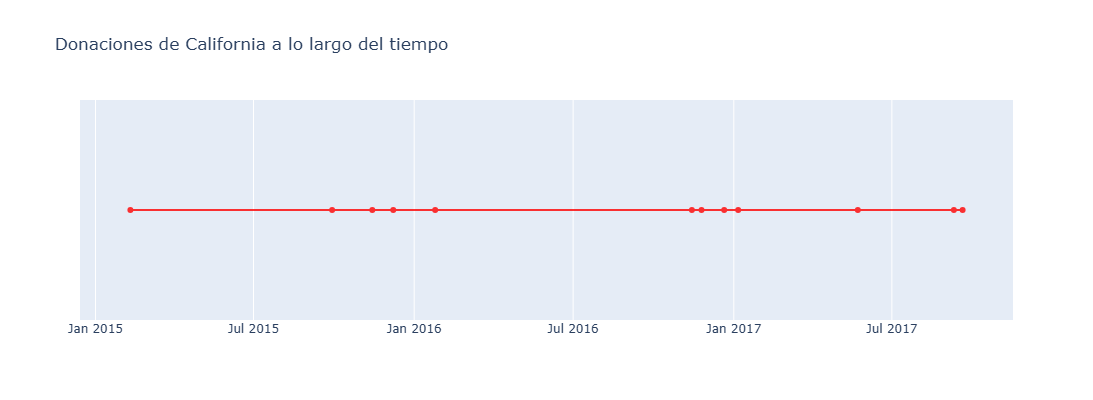

In [119]:
combined_df['Donation Date'] = combined_df['Donation Received Date'].apply(
    lambda x: str(x).split()[0]
)

cali = combined_df[combined_df['Donor State'] == 'California']

cali = (
    cali.groupby('Donation Date')
    .agg({'Donation Amount':'count'})
    .reset_index()
)

cali1 = pd.DataFrame()

cali1['Date'] = pd.to_datetime(cali['Donation Date'])
cali1['Donation Amount'] = cali['Donation Amount']


trace1 = go.Scatter(
    x=cali1['Date'],
    y=cali1['Donation Amount'],
    name="California",
    line=dict(color='red'),
    opacity=0.8
)


data = [trace1]


layout = dict(
    title="Donaciones de California a lo largo del tiempo",
    height=400,
    showlegend=False,
    yaxis=dict(
        showgrid=False,
        zeroline=False,
        showline=False,
        ticks='',
        showticklabels=False
    )
)


fig = dict(
    data=data,
    layout=layout
)


iplot(fig)

> El mayor número de donaciones de California se registró el **25 de enero de 2018**, con casi 5000 donaciones, seguido por el **28 de noviembre de 2017** con 4699 donaciones

## <a id="4"> 4. Exploración de los Maestros  </a>  
## <a id="4.1"> 4.1 Vista Previa de los Datos de Maestros </a>

In [120]:
teachers_df.head(3)
# len(teachers_df)

,Teacher ID,Teacher Prefix,Teacher First Project Posted Date
0,bdd640fb06671ad11c80317fa3b1799d,Mrs.,2007-01-03
1,ad3c2d6d1a3d1fa7bc8960a923b8c1e9,Ms.,2014-03-26
2,0822e8f36c031199972a846916419f82,Mrs.,2006-11-27


> Hay 402,900 maestros en total que han publicado al menos un proyecto en donorschoose desde 2002. La gran mayoría de los maestros son mujeres, veamos quiénes fueron los primeros maestros en publicar proyectos en donorschoose. 

## <a id="4.2"> 4.2 Quiénes fueron los Primeros Maestros en DonorsChoose.org </a>  

In [121]:
teachers_df['Posted Date'] = pd.to_datetime(teachers_df['Teacher First Project Posted Date'])
teachers_df['Posted Year'] = teachers_df['Posted Date'].dt.year

# Lets Find out who were the first donors on DonorsChooseSome of the Earliest Teachers 
teachers_df[['Teacher ID', 'Posted Date']].sort_values(['Posted Date'])[:10]

,Teacher ID,Posted Date
29,6f4cc69a4b22d3081c8eaee95715bd6f,2002-01-27
78,d450281c6c6f7633a260772317a0df49,2002-01-30
114,25c73c443e75c3b4664fa6637e8f8095,2002-02-15
68,c07a30f2edd4253b50f0fd0a750cab75,2002-03-18
80,b4a69f3c8d3aed99711c21c9bdc14f1f,2002-03-21
54,ffd0f9d5a6f2f7b80cf35b5819108be5,2002-05-01
162,b63b4dc3a559e46379e13ceab0cbc61f,2002-05-22
42,3985c3cf3f76be1d1efa21977394988f,2002-06-22
87,2d534dd0cf8ebc5accc56569f9e8a369,2002-07-23
95,89456f27d7fa2d8dfb2ca025adf4e62d,2002-08-15


> Los primeros maestros en DonorsChoose se registraron el 17-09-2002. Ese día se registraron 2 maestras, ambas mujeres. En el mes de septiembre de 2002, se registraron en total 8 maestros, quienes fueron principalmente el primer grupo de maestros en donorschoose.

## <a id="4.3"> 4..3 Crecimiento en el Número de Maestros a lo largo de los años </a>  

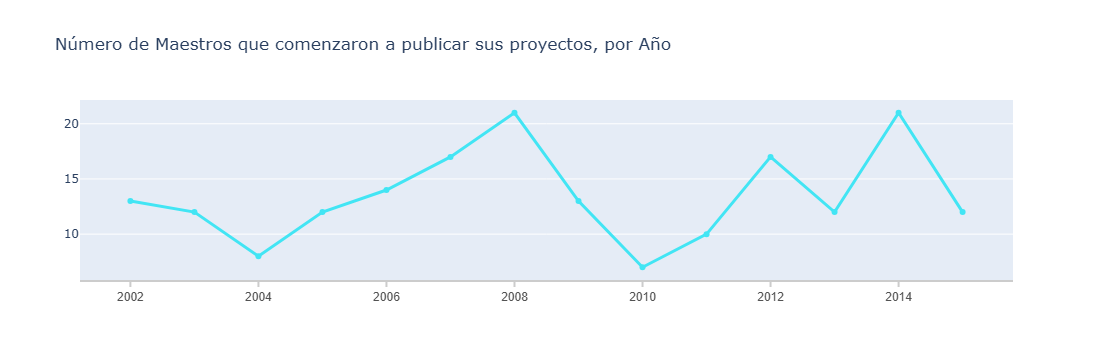

In [123]:
temp = (
    teachers_df
    .groupby('Posted Year')
    .agg({'Teacher ID':'count'})
    .reset_index()
)

temp = temp.sort_values('Posted Year')


trace = go.Scatter(
    x=list(temp['Posted Year'])[:-1],
    y=list(temp['Teacher ID'])[:-1],
    mode='lines+markers',
    line=dict(
        color="#42e5f4",
        width=3
    ),
    connectgaps=True,
    fillcolor='rgba(0,100,80,0.2)',
)


layout = go.Layout(
    xaxis=dict(
        showline=True,
        showgrid=False,
        showticklabels=True,
        linecolor='rgb(204,204,204)',
        linewidth=2,
        ticks='outside',
        tickcolor='rgb(204,204,204)',
        tickwidth=2,
        ticklen=5,
        tickfont=dict(
            family='Arial',
            size=12,
            color='rgb(82,82,82)'
        ),
    ),
    title='Número de Maestros que comenzaron a publicar sus proyectos, por Año'
)


fig = go.Figure(
    data=[trace],
    layout=layout
)


iplot(fig)

> - El número de maestros comenzó a publicar en DonorsChoose cuando se lanzó en 2002, pero los primeros cinco años vieron un número muy bajo de maestros publicando proyectos  
> - Una tendencia ascendente comenzó a desarrollarse alrededor de 2008, y el período **2012 - 2013** vio un aumento masivo en el número de maestros publicando proyectos 
> - La tendencia alcanzó su punto máximo de 80K nuevos maestros publicando proyectos en 2016, pero el **número bajó a 75K en 2017**. No solo los donantes necesitan ser motivados, sino que los maestros también deben ser incentivados a publicar más proyectos; al observar el crecimiento de nuevos maestros a lo largo de los años, parece que donorschoose está haciendo un buen trabajo 

## <a id="4.4"> 4.4 Cuál es la distribución de los Prefijos de los Maestros </a>  

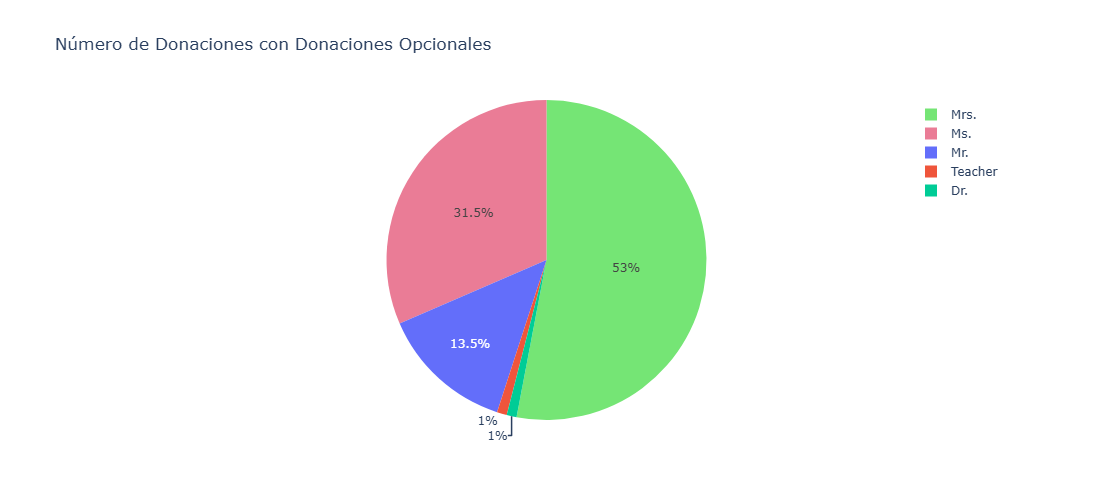

In [124]:

t = teachers_df['Teacher Prefix'].value_counts()

labels = t.index
values2 = t.values
trace2 = go.Pie(labels=labels, values=values2, marker=dict(colors=['#75e575', '#ea7c96',]))

layout = go.Layout(title='Número de Donaciones con Donaciones Opcionales', width=800, height=500)
fig = go.Figure(data=[trace2], layout=layout)
iplot(fig)

## <a id="4.5"> 4.5 Serie de Tiempo de Maestros publicando sus primeros proyectos </a>  

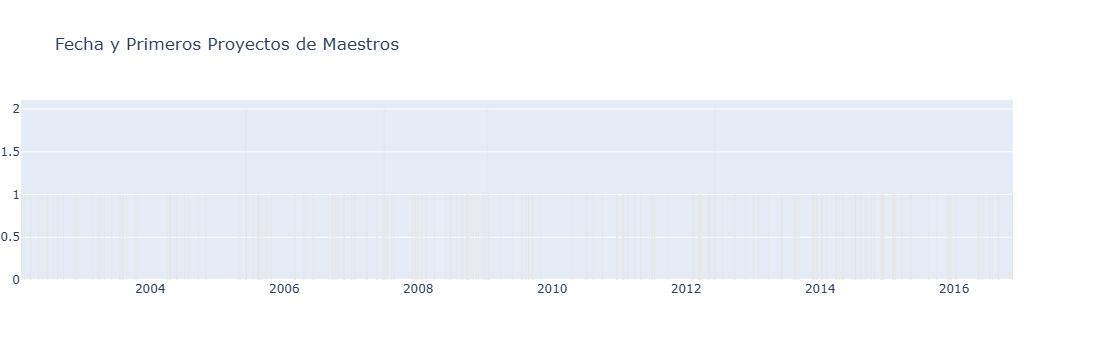

In [125]:
t = teachers_df['Posted Date'].value_counts()#[:10]
x = t.index
y = t.values
bar_ver_noagg(x, y, 'Fecha y Primeros Proyectos de Maestros', 'orange')

> - El mayor número de proyectos por primera vez se observó el **13 de sep de 2015, igual a 2067 proyectos**. 
> - Es interesante notar que se observan picos cada agosto, de 2014 a 2017. 

## <a id="5"> 5. Exploración de las Escuelas </a>
## <a id="5.1"> 5.1 Vista Previa de los Datos de Escuelas </a>

In [127]:
schools_df = pd.read_csv(
    path + "Schools.csv",
    on_bad_lines='skip'
)

schools_df.head(3)

,School ID,School Name,School Metro Type,School Percentage Free Lunch,School State,School Zip,School City,School County,School District
0,bdd640fb06671ad11c80317fa3b1799d,Miami Elementary School,urban,17.0,Florida,23434,Miami,Miami County,Miami School District
1,07a0ca6e0822e8f36c031199972a8469,Houston Elementary School,urban,64.0,Texas,88907,Houston,Houston County,Houston School District
2,a65ed389b74d0fb132e706298fadc1a6,Sammamish Elementary School,town,75.0,Washington,46463,Sammamish,Sammamish County,Sammamish School District


> Se han publicado en donorschoose proyectos de un total de 72,993 escuelas diferentes, hasta abril de 2018.

## <a id="5.2"> 5.2 Qué Tipo de Zona Metropolitana publica más proyectos  (y los Estados y Ciudades principales) </a>  

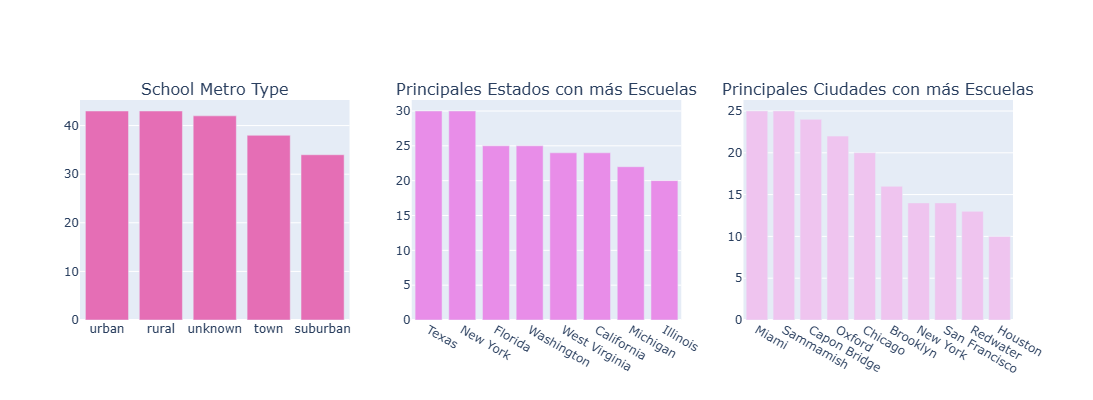

In [128]:
t1 = schools_df['School Metro Type'].value_counts()
t2 = schools_df['School State'].value_counts()
t3 = schools_df['School City'].value_counts()


trace1 = bar_ver_noagg(t1.index[:10], t1.values[:10], "School Metro Type", '#e56eb5', None, None, 0,  rt=True)
trace2 = bar_ver_noagg(t2.index[:10], t2.values[:10], "Principales Estados con más Escuelas", '#e88de8', None, None, 0,  rt=True)
trace3 = bar_ver_noagg(t3.index[:10], t3.values[:10], "Principales Ciudades con más Escuelas", '#efc4ef', None, None, 0,  rt=True)

fig = tools.make_subplots(rows=1, cols=3, print_grid=False, subplot_titles = ['School Metro Type', 'Principales Estados con más Escuelas', 'Principales Ciudades con más Escuelas'])
fig.append_trace(trace1, 1, 1);
fig.append_trace(trace2, 1, 2);
fig.append_trace(trace3, 1, 3);
fig['layout'].update(height=400, showlegend=False);
iplot(fig);

> - La mayoría de las escuelas se ubican en zonas suburbanas y urbanas
> - La Ciudad de Nueva York, Houston y Chicago son las tres ciudades principales donde se ubican las escuelas 

## <a id="5.3"> 5.3 Distribución del Porcentaje de Almuerzo Gratuito en las Escuelas </a>  

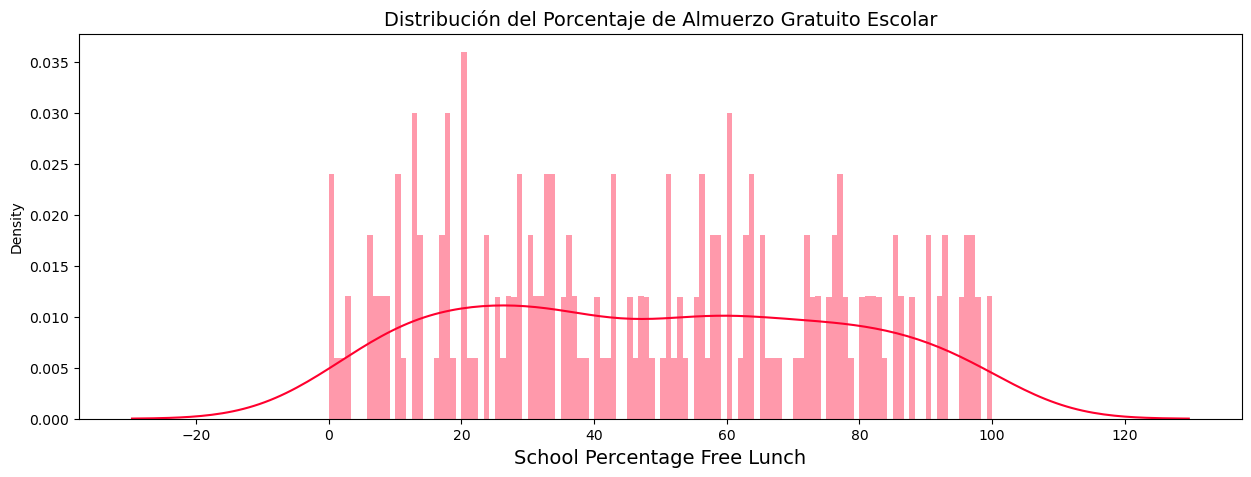

In [129]:
# extract School Types 
plt.figure(figsize=(15,5))
sns.distplot(schools_df['School Percentage Free Lunch'].dropna(), bins=120, color="#ff002e")
plt.xlabel('School Percentage Free Lunch', fontsize=14);
plt.title("Distribución del Porcentaje de Almuerzo Gratuito Escolar", fontsize=14);
plt.show();

## <a id="5.4"> 5.4 Qué Tipos de Escuela están registrados en mayoría  </a>

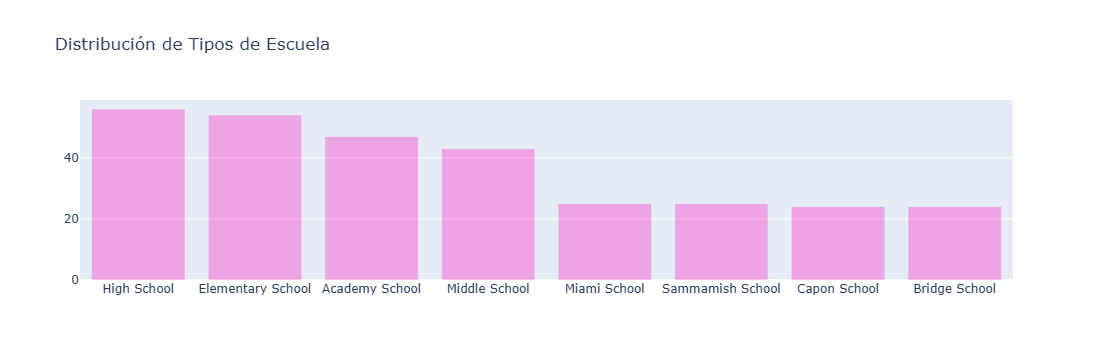

In [130]:
words = " ".join(schools_df['School Name']).split()
from collections import Counter

school_types = Counter(words).most_common(30)[1:9]
school_types = [list(x) for x in school_types]
labels = [x[0]+" School" for x in school_types]
values = [x[1] for x in school_types]

trace2 = go.Bar(
    x=labels,
    y=values,
    name='Donors to Population',
    marker=dict(color='#ff00bb'),
    opacity=0.3
)

data = [trace2]
layout = go.Layout(
    barmode='group',
    legend=dict(dict(x=-.1, y=1.2)),
    title = 'Distribución de Tipos de Escuela',
)

fig = go.Figure(data=data, layout=layout)
iplot(fig, filename='grouped-bar')

> La gran mayoría de las escuelas son Escuelas Primarias (con alrededor de 35K escuelas), lo cual es mucho mayor que las Escuelas Secundarias (High Schools, alrededor de 12K escuelas), las Escuelas Intermedias (Middle Schools, alrededor de 9K escuelas) o las Academias (alrededor de 4K escuelas). 

## <a id="6"> 6. Exploración de los Recursos </a>  

Los datos de recursos consisten en los artículos solicitados dentro de cada proyecto, e incluyen el nombre del artículo, la cantidad de recurso, el precio unitario y el nombre del proveedor

## <a id="6.1"> 6.1 Vista Previa de los Recursos </a>

In [131]:
resources_df = pd.read_csv(path+"Resources.csv")
resources_df.head(5)

# len(resources_df)

,Project ID,Resource Item Name,Resource Quantity,Resource Unit Price,Resource Vendor Name
0,bdd640fb06671ad11c80317fa3b1799d,"gaiam kids stay-n-play balance ball, grey",44.0,398.73,Lakeshore Learning Materials
1,f143262fdc5c0eed8da0365bf89897b9,apple ipad wi-fi 32gb,8.0,135.61,Amazon Business
2,451b4cf36123fdf77656af7229d4beef,sony mdr zx100 blk headphones,17.0,437.49,Amazon Business
3,0e51f30dc6a7ee39c4b032ccd7c524a5,"gaiam kids stay-n-play balance ball, grey",41.0,137.81,NaN
4,0e51f30dc6a7ee39c4b032ccd7c524a5,"serta lounger, mini, sky blue",10.0,171.39,Amazon Business


> Hasta abril de 2018, se han realizado un total de 7,210,448 solicitudes de recursos por parte de los maestros en diferentes proyectos

## <a id="6.2"> 6.2 Artículos Más Populares </a>  

Obtengamos cuáles son los artículos más populares a partir de los datos de recursos. Los artículos más solicitados son aquellos que aparecen en un gran número de proyectos; los artículos solicitados en grandes cantidades representan artículos que se pidieron en números elevados.

- 6.2.1 Artículos más solicitados de todos los tiempos   
- 6.2.2 Artículos solicitados en Grandes Cantidades 

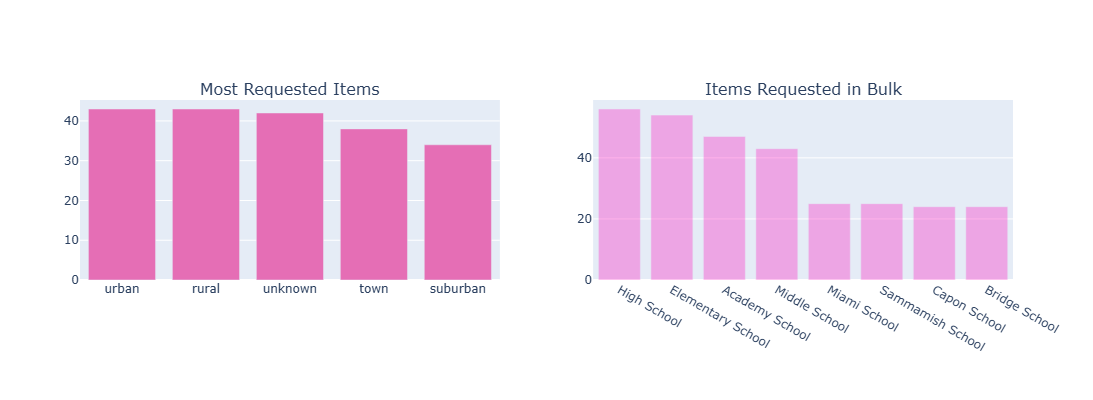

In [134]:
from plotly.subplots import make_subplots

fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=['Most Requested Items','Items Requested in Bulk']
)

fig.add_trace(trace1, row=1, col=1)
fig.add_trace(trace2, row=1, col=2)

fig.update_layout(
    height=400,
    showlegend=False,
    margin=dict(b=120)
)

fig.show()

> Como podemos ver, el Apple iPad (iPad Mini, Wifi, 16 o 32 GB) es el artículo más solicitado de todos los tiempos. Se solicitó en más de 30 mil proyectos. Los maestros están muy interesados en usar tecnología en las aulas. **Viajes (Trips)** es otro de los artículos más solicitados de todos los tiempos, con más de 20K proyectos, lo cual indica que los maestros están interesados en llevar a los estudiantes a excursiones educativas o culturales. Otros artículos principales incluyen paneles de privacidad, mobiliario comercial y asientos suaves. 

> Hay muchos artículos que se solicitan en grandes cantidades en uno o más proyectos. Algunos artículos incluyen bloques de reticulación de polietileno, deslizadores de renovación q-ball y deslizadores de silla. 

## <a id="6.3">  6.3 Artículos Más Costosos </a>  

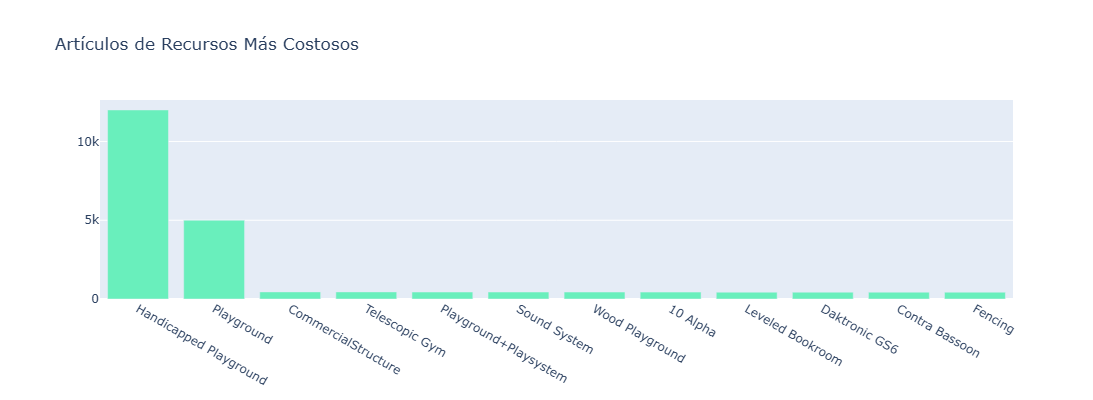

In [135]:
t = resources_df.sort_values('Resource Unit Price', ascending=False).head(15)
t1 = pd.DataFrame()
t1['item'] = t['Resource Item Name']
t1['price'] = t['Resource Unit Price']
t1['standardized'] = """Handicapped Playground,Playground,CommercialStructure,Telescopic Gym,Playground+Playsystem,Sound System,CommercialStructure,Wood Playground,Playground+Playsystem,10 Alpha,Leveled Bookroom,Daktronic GS6,Contra Bassoon,Fencing,Playground+Playsystem""".split(",")
t2 = t1.groupby('standardized').agg({'price' : 'max'}).reset_index()
t2 = t2.sort_values('price', ascending = True)
trace2 = bar_ver_noagg(list(reversed(list(t2['standardized']))), list(reversed(list(t2['price']))), "Artículos de Recursos Más Costosos", "#69efbc", 800, 400, 100)

> - Algunos de los artículos de recursos más costosos en donorschoose son los **parques de juegos, como el Parque de Juegos para Discapacitados**, con casi USD 100,000, siendo el artículo de recurso más caro, seguido por la **Estructura Comercial Little Tikes** y los **Gimnasios Telescópicos**. 

## <a id="6.4"> 6.4 Proveedores Famosos en DonorsChoose </a>  

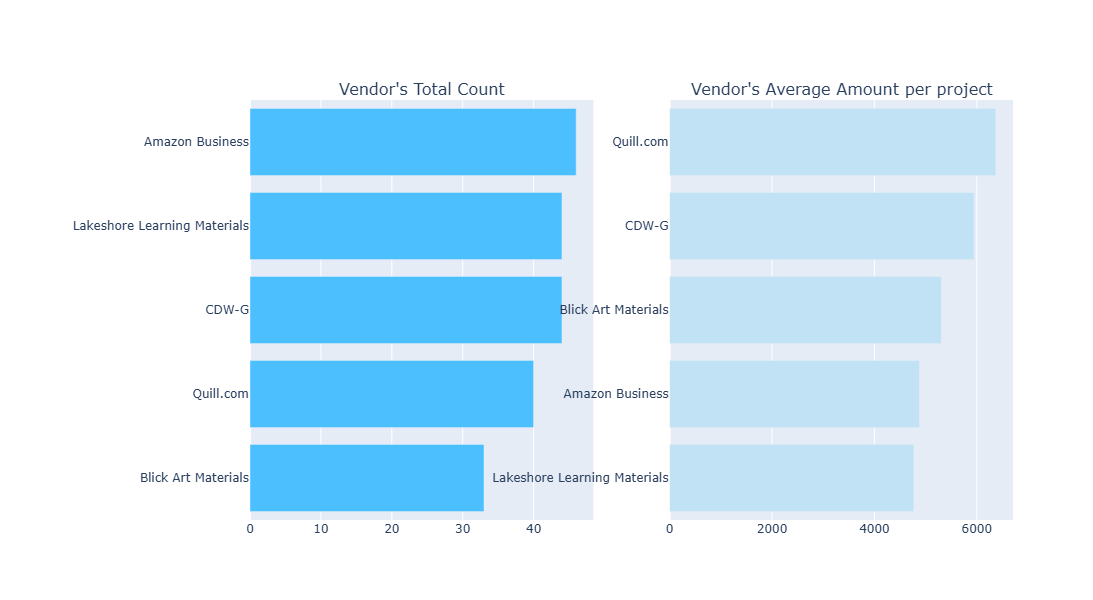

In [136]:
# most famous vendors
t = resources_df['Resource Vendor Name'].value_counts()
k = list(reversed(list(t.index)[:15]))
v = list(reversed(list(t.values)[:15]))

t = resources_df.sort_values('Resource Quantity', ascending=False).head(10)
trace2 = bar_hor_noagg(k, v, "Artículos de Recursos Más Costosos", "#4cc0ff", 800, 500, 200, rt=True)

resources_df['total_price'] = resources_df['Resource Quantity'] * resources_df['Resource Unit Price']

# to which vendor has most money went 
# tempdf = resources_df.groupby('Resource Vendor Name').agg({'total_price' : 'sum'}).reset_index()
# tempdf = tempdf.sort_values('total_price', ascending = False)[:10]
# trace1 = bar_hor_noagg(list(reversed(list(tempdf['Resource Vendor Name']))), list(reversed(list(tempdf['total_price']))), "", "#8dd0f4", 600, 400, 200, rt=True)

# average price received by which vendors 
tempdf = resources_df.groupby('Resource Vendor Name').agg({'total_price' : 'mean'}).reset_index()
tempdf = tempdf.sort_values('total_price', ascending = False)[:15]
trace1 = bar_hor_noagg(list(reversed(list(tempdf['Resource Vendor Name']))), list(reversed(list(tempdf['total_price']))), "", "#c1e2f4", 800, 400, 200, rt=True)

fig = tools.make_subplots(rows=1, cols=2, print_grid=False, subplot_titles = ["Vendor's Total Count" , "Vendor's Average Amount per project"])
fig.append_trace(trace2, 1, 1);
fig.append_trace(trace1, 1, 2);
fig['layout'].update(height=600, showlegend=False, margin=dict(l=250));
iplot(fig);

> - La mayoría de los recursos se solicitan de **Amazon Business, con 3.2 millones** de veces que se solicitó un artículo de Amazon. Amazon Business es seguido por Lakeshore Learning Materials y AKJ Education. 
> - Al comparar el costo promedio recibido por un proveedor, **MarkerBot** ocupa el primer lugar, con un costo promedio por proyecto recibido de **USD 2000**. 
> - **Best Buy Education** es uno de los proveedores popular entre los maestros y que también tiene un precio promedio significativamente más alto recibido por proyecto. 
<br>

## <a id="7"> 7. Exploración de los Proyectos  </a> 

Los datos de proyectos consisten en todos los detalles sobre los proyectos publicados, que incluyen el id del maestro y de la escuela, el título, el tipo, la categoría, el costo, etc. de los proyectos. Veamos una vista previa.

## <a id="7.1">  7.1 Vista Previa de los Proyectos </a>

In [137]:
projects_df = pd.read_csv(path+"Projects.csv")
projects_df.head(3)

,Project ID,School ID,Teacher ID,Teacher Project Posted Sequence,Project Type,Project Title,Project Essay,Project Subject Category Tree,Project Subject Subcategory Tree,Project Grade Level Category,Project Resource Category,Project Cost,Project Posted Date,Project Current Status,Project Fully Funded Date
0,bdd640fb06671ad11c80317fa3b1799d,23b8c1e9392456de3eb13b9046685257,bd9c66b3ad3c2d6d1a3d1fa7bc8960a9,5,Teacher-Led,Anti-Bullying Begins with Me,Lorem ipsum dolor sit amet classroom school...,"Literacy & Language, Math & Science","Applied Sciences, Literature & Writing",Grades PreK-2,Books,$231.17,2014-04-22,Live,NaN
1,32e706298fadc1a606cb0fb39a1de644,8b8148f6b38a088ca65ed389b74d0fb1,96da1dac72ff5d2a386ecbe06b65a6a4,3,Teacher-Led,Anti-Bullying Begins with Me,Lorem ipsum dolor sit amet classroom school...,Music & The Arts,"Applied Sciences, Literature & Writing",Grades 3-5,Technology,$317.67,2014-11-21,Fully Funded,2014-12-01
2,d8f564135be6128e18c267976142ea7d,ce9ff57f43b7a3a69a8dca03580d7b71,89463e85759cde66bacfb3d00b1f9163,1,Teacher-Led,Technology in the Classroom,Lorem ipsum dolor sit amet classroom school...,"Applied Learning, Literacy & Language","Literacy, Mathematics",Grades 3-5,Trips,$1339.63,2015-01-11,Live,NaN


## <a id="7.2"> 7.2 Cuáles son las Categorías, Subcategorías y Categorías de Recursos más frecuentes para los proyectos publicados </a>

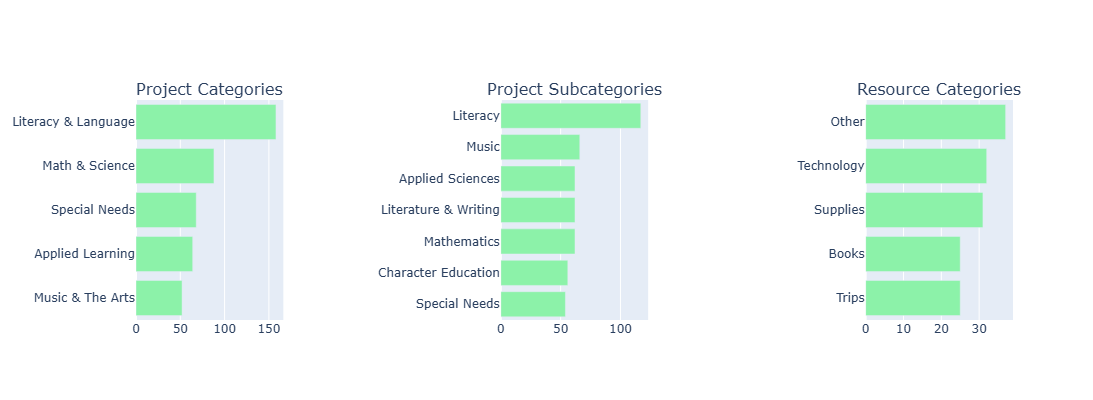

In [138]:
# Create some date time features 
projects_df['Posted Date'] = pd.to_datetime(projects_df['Project Posted Date'])

projects_df['Posted Year'] = projects_df['Posted Date'].dt.year
projects_df['Posted Month'] = projects_df['Posted Date'].dt.month
projects_df['Posted Day'] = projects_df['Posted Date'].dt.weekday
projects_df['Posted Quarter'] = projects_df['Posted Date'].dt.quarter

projects_df['Funded Date'] = pd.to_datetime(projects_df['Project Fully Funded Date'])
projects_df['Funded Year'] = projects_df['Funded Date'].dt.year
projects_df['Funded Month'] = projects_df['Funded Date'].dt.month
projects_df['Funded Day'] = projects_df['Funded Date'].dt.weekday
projects_df['Funded Quarter'] = projects_df['Funded Date'].dt.quarter
projects_df['Funding Time'] = projects_df['Funded Date'] - projects_df['Posted Date']



t = projects_df['Project Subject Category Tree'].value_counts()
x = list(t.index)
y = list(t.values)
r = {}
for i,val in enumerate(x):
    for each in val.split(","):
        x1 = each.strip()
        if x1 not in r:
            r[x1] = y[i]
        r[x1] += y[i]
sorted_x = list(sorted(r.items(), key=operator.itemgetter(1), reverse = True))[:10]
x1 = [a[0] for a in sorted_x][::-1]
y1 = [a[1] for a in sorted_x][::-1]



t1 = projects_df['Project Subject Subcategory Tree'].value_counts()
x2 = list(t1.index)
y2 = list(t1.values)
r = {}
for i,val in enumerate(x2):
    for each in val.split(","):
        x1_ = each.strip()
        if x1_ not in r:
            r[x1_] = y2[i]
        r[x1_] += y2[i]        
x2 = r.keys()
y2 = r.values()
sorted_x = list(sorted(r.items(), key=operator.itemgetter(1), reverse = True))[:10]
x2 = [a[0] for a in sorted_x][::-1]
y2 = [a[1] for a in sorted_x][::-1]

t = projects_df['Project Resource Category'].value_counts()
x3 = list(t.index[::-1])[:10]
y3 = list(t.values[::-1])[:10]


trace1 = bar_hor_noagg(x1, y1, "", "#8cf2a9", 600, 400, 10, rt=True)
trace2 = bar_hor_noagg(x2, y2, "", "#8cf2a9", 600, 400, 10, rt=True)
trace3 = bar_hor_noagg(x3, y3, "", "#8cf2a9", 600, 400, 10, rt=True)

fig = tools.make_subplots(rows=1, cols=5, print_grid=False, subplot_titles = ['Project Categories' ,"", 'Project Subcategories', '', "Resource Categories"])
fig.append_trace(trace1, 1, 1);
fig.append_trace(trace2, 1, 3);
fig.append_trace(trace3, 1, 5);
fig['layout'].update(height=400, showlegend=False, margin=dict(l=120));
iplot(fig);

> Una gran mayoría de los proyectos (más de 800K) pertenecen a la categoría principal **Alfabetización e Idioma (Literacy and Language)**. **Matemáticas y Ciencias** es la segunda categoría más famosa. Se ha publicado un número comparativamente menor de proyectos sobre Cuidado y Hambre (Care and Hunger) desde 2013.      
> Entre las subcategorías, Alfabetización, Matemáticas y Escritura son las subcategorías más comunes de los proyectos publicados por los maestros, mientras que se publica un número menor de proyectos bajo la categoría de Desarrollo Temprano y Salud. 
> **Tecnología Instructiva, Rincones de Lectura, Escritorios y Almacenamiento** son las categorías clave de recursos solicitadas por los maestros 

## <a id="7.3">  7.3 Cuál es la distribución del Tipo de Proyecto y el Estado Actual del Proyecto </a>  

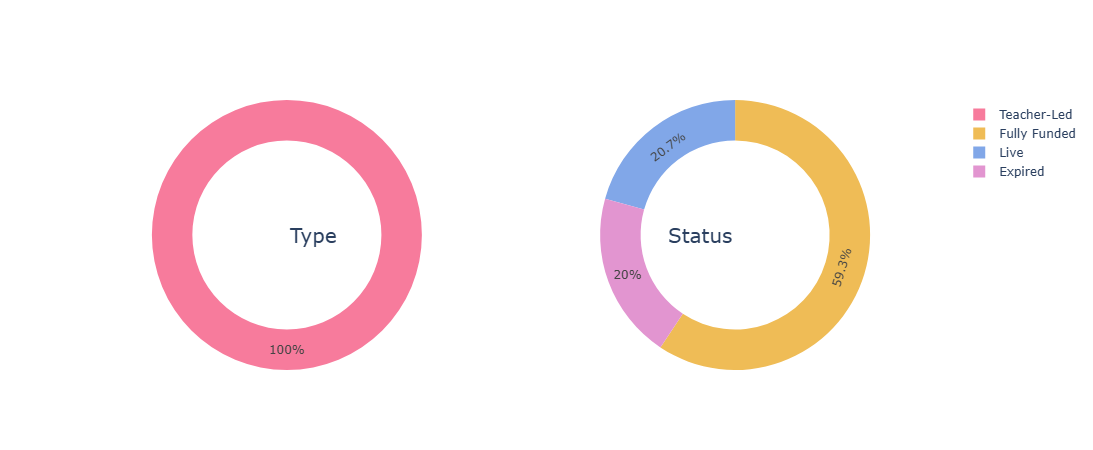

In [140]:
import plotly.graph_objects as go
from plotly.offline import iplot


# Conteo de tipos de proyectos
t = projects_df['Project Type'].value_counts()

values1 = t.values
index1 = t.index


# Conteo de estados de proyectos
t = projects_df['Project Current Status'].value_counts()

values2 = t.values
index2 = t.index


fig = go.Figure(
    data=[
        go.Pie(
            values=values1,
            labels=index1,
            name="Project Type",
            hole=0.7,
            hoverinfo="label+percent+name",
            marker=dict(
                colors=[
                    "#f77b9c",
                    "#ab97db",
                    "#b0b1b2"
                ]
            ),
            domain=dict(
                x=[0, 0.48]
            )
        ),

        go.Pie(
            values=values2,
            labels=index2,
            name="Project Status",
            hole=0.7,
            hoverinfo="label+percent+name",
            marker=dict(
                colors=[
                    "#efbc56",
                    "#81a7e8",
                    "#e295d0"
                ]
            ),
            domain=dict(
                x=[0.52, 1]
            )
        )
    ]
)


fig.update_layout(
    height=450,
    showlegend=True,
    annotations=[
        dict(
            font=dict(size=20),
            showarrow=False,
            text="Type",
            x=0.24,
            y=0.5
        ),
        dict(
            font=dict(size=20),
            showarrow=False,
            text="Status",
            x=0.76,
            y=0.5
        )
    ]
)


fig.show()

> Aparte de los proyectos dominantes Liderados por Maestros, un número significativamente menor de proyectos también son publicados por estudiantes o servicios de desarrollo profesional. Los datos muestran que alrededor del 75% de todos los proyectos publicados han sido financiados por completo, mientras que el 21% de ellos han expirado. Hasta mayo de 2018, aproximadamente 42K proyectos están activos en donorschoose. 

## <a id="7.4"> 7.4 En qué días se publicaron y financiaron la mayor cantidad de proyectos ? </a>  

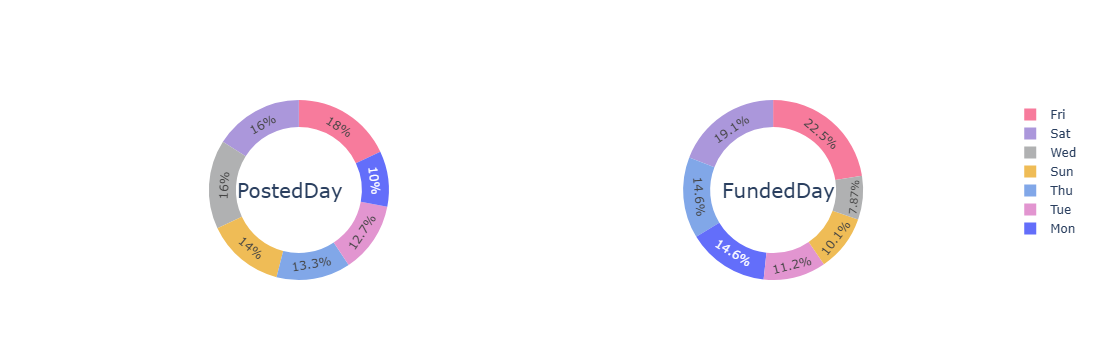

In [141]:
t1 = projects_df['Posted Day'].value_counts()
t2 = projects_df['Funded Day'].value_counts()

mapp = {0:'Sun',1:'Mon',2:'Tue',3:'Wed',4:'Thu',5:'Fri',6:'Sat'}
values1 = t1.values 
index1 = t1.index
index1 = [mapp[x] for x in index1]

values2 = t2.values 
index2 = t2.index
index2 = [mapp[x] for x in index2]
tmap = {}
for j, b in enumerate(index2):
    tmap[b] = values2[j]
# print (tmap)
# print index1
values2_c = [tmap[c] for c in index1]
# print values2_c
domain1 = {'x': [0.2, 0.50], 'y': [0.0, 0.33]}
domain2 = {'x': [0.8, 0.50], 'y': [0.0, 0.33]}


fig = {
  "data": [
    {
      "values": values1,
      "labels": index1,
      "domain": {"x": [0, .48]},
        "marker" : dict(colors=["#f77b9c" ,'#ab97db',  '#b0b1b2', "#efbc56", "#81a7e8", "#e295d0"]),
      "name": "PostedDay",
      "hoverinfo":"label+percent+name",
      "hole": .7,
#             "textinfo" : "text",
      "type": "pie"
    },
    {
      "values": values2_c,
      "labels": index1,
        "marker" : dict(colors=["#f77b9c" ,'#ab97db',  '#b0b1b2', "#efbc56", "#81a7e8", "#e295d0"]),
      "domain": {"x": [.52, 1]},
#         "text":"CO2",
      "textposition":"inside",
      "name": "FundedDay",
#         "text" : values2,
#         "textinfo" : "text",
        "hole" : .7,
      "type": "pie"
    }],
  "layout": {
#         "title":"Project Type and Project Status",
      "annotations": [
            {
                "font": {
                    "size": 20
                },
                "showarrow": False,
                "text": "PostedDay",
                "x": 0.17,
                "y": 0.5
            },
            {
                "font": {
                    "size": 20
                },
                "showarrow": False,
                "text": "FundedDay",
                "x": 0.83,
                "y": 0.5
            }
        ]
    
    }
}
iplot(fig, filename='donut')

> Los maestros generalmente han publicado en los últimos días de la semana: viernes (16%), sábado (16%) y domingo (17%). Mientras que los lunes se ha financiado y cerrado el mayor número de proyectos. 

## <a id="7.5"> 7.5 En qué Trimestres se publican y financian los proyectos </a>  

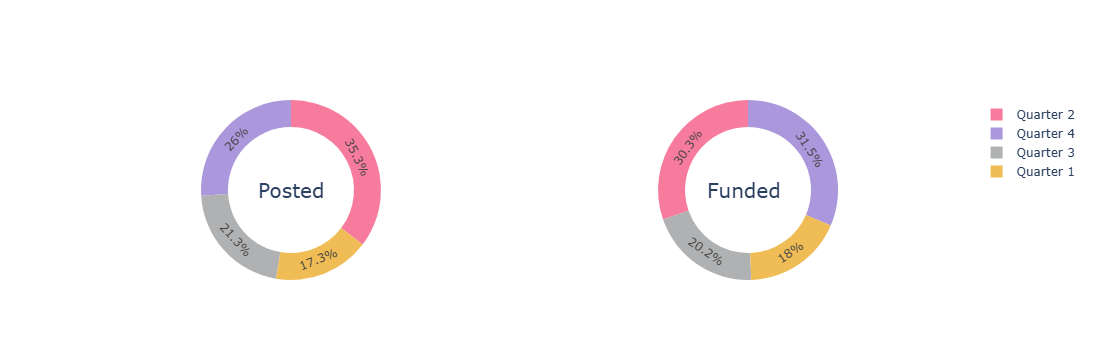

In [142]:
t1 = projects_df['Posted Quarter'].value_counts()
t2 = projects_df['Funded Quarter'].value_counts()

mappq = {1.0:'Quarter 1',2.0:'Quarter 2',3.0:'Quarter 3',4.0:'Quarter 4'}
values1 = t1.values 
index1 = t1.index
index1 = [mappq[x] for x in index1]

values2 = t2.values 
index2 = t2.index
index2 = [mappq[x] for x in index2]
tmap = {}
for j, b in enumerate(index2):
    tmap[b] = values2[j]
# print (tmap)
# print index1
values2_c = [tmap[c] for c in index1]
# print values2_c
domain1 = {'x': [0.2, 0.50], 'y': [0.0, 0.33]}
domain2 = {'x': [0.8, 0.50], 'y': [0.0, 0.33]}


fig = {
  "data": [
    {
      "values": values1,
      "labels": index1,
      "domain": {"x": [0, .48]},
        "marker" : dict(colors=["#f77b9c" ,'#ab97db',  '#b0b1b2', "#efbc56", "#81a7e8", "#e295d0"]),
      "name": "PostedDay",
#       "hoverinfo":"label+percent+name",
      "hole": .7,
#             "textinfo" : "text",
      "type": "pie"
    },
    {
      "values": values2_c,
      "labels": index1,
        "marker" : dict(colors=["#f77b9c" ,'#ab97db',  '#b0b1b2', "#efbc56", "#81a7e8", "#e295d0"]),
      "domain": {"x": [.52, 1]},
#         "text":"CO2",
      "textposition":"inside",
      "name": "FundedDay",
#         "text" : values2,
#         "textinfo" : "text",
        "hole" : .7,
      "type": "pie"
    }],
  "layout": {
#         "title":"Project Type and Project Status",
      "annotations": [
            {
                "font": {
                    "size": 20
                },
                "showarrow": False,
                "text": "Posted",
                "x": 0.2,
                "y": 0.5
            },
            {
                "font": {
                    "size": 20
                },
                "showarrow": False,
                "text": "Funded",
                "x": 0.8,
                "y": 0.5
            }
        ]
    
    }
}
iplot(fig, filename='donut')




> El Trimestre 3, es decir, jul, ago, sep, es el período en que se ha publicado el mayor número de proyectos por parte de los maestros, y lo mismo ocurre con su siguiente trimestre inmediato, es decir, el Trimestre 4, cuando se financia y cierra la mayoría de los proyectos.  

## <a id="7.6"> 7.6 En qué meses se publicaron los proyectos </a>  

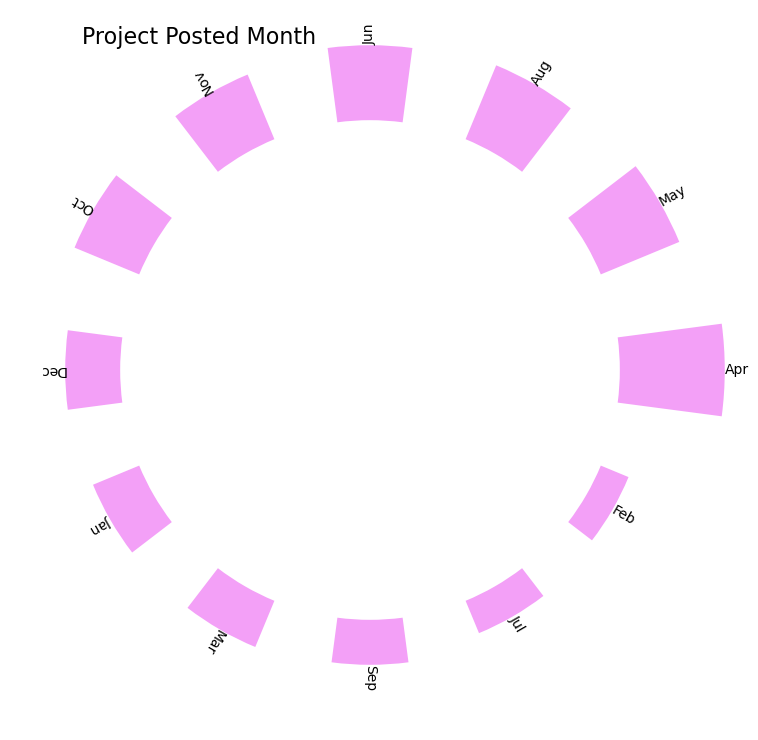

In [143]:
t = projects_df['Posted Month'].value_counts()


lObjectsALLcnts = list(t.values)

lObjectsALLlbls = list(t.index)
mapp1 = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
lObjectsALLlbls = [mapp1[x] for x in lObjectsALLlbls]

iN = len(lObjectsALLcnts)
arrCnts = np.array(lObjectsALLcnts)

theta=np.arange(0, 2*np.pi, 2*np.pi/iN)
width = (2*np.pi)/iN *0.5
bottom = 50

fig = plt.figure(figsize=(8,8))
ax = fig.add_axes([0.2, 0.1, 1, 0.9], polar=True)
fig.suptitle('Project Posted Month   ', fontsize=16)
bars = ax.bar(theta, arrCnts, width=width, bottom=bottom, color='#f3a0f7')
plt.axis('off')

rotations = np.rad2deg(theta)
for x, bar, rotation, label in zip(theta, bars, rotations, lObjectsALLlbls):
    lab = ax.text(x,bottom+bar.get_height() , label, ha='left', va='center', rotation=rotation, rotation_mode="anchor",)   
plt.show()


> En el Trimestre 3, se ha publicado el mayor número de proyectos en el mes de septiembre, seguido de agosto. El menor número de proyectos se ha publicado en junio. 

## <a id="7.7"> 7.7 En qué Año se publicaron los proyectos </a>

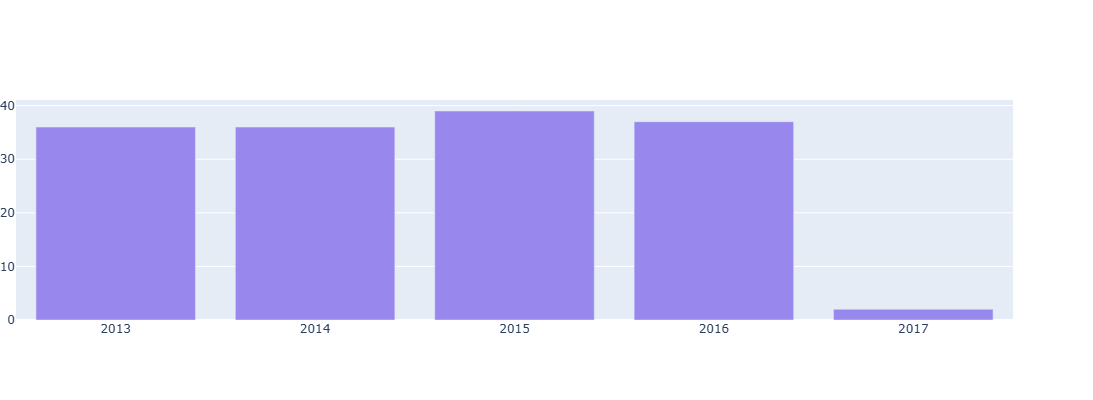

In [144]:
t = projects_df.groupby('Posted Year').agg({'Posted Month' : 'count'}).reset_index()
t = t.sort_values('Posted Year')
trace2 = bar_ver_noagg(t['Posted Year'], t['Posted Month'], "", "#9887ed", None, 400, 0)


> El número de proyectos en donorschoose ha aumentado constantemente durante los últimos 5 años. Alrededor de 300K proyectos se publicaron en 2017

## <a id="7.8"> 7.8 En qué Año y Mes, el costo del proyecto es más alto </a>

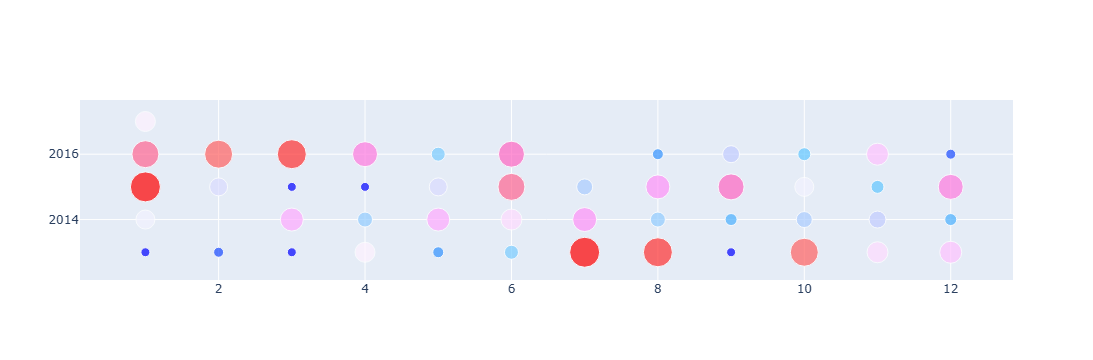

In [145]:
year_tab = pd.crosstab(projects_df["Project Current Status"], projects_df["Posted Year"]).reset_index()
from itertools import zip_longest
projects_df['cost'] = projects_df['Project Cost'].apply(lambda x : float(str(x).replace(",","").replace("$","")))

def cbp(df, col1, col2, aggcol, func, title, cs, bottom_margin=None):
    tempdf = df.groupby([col1, col2]).agg({aggcol : func}).reset_index()
    tempdf[aggcol] = tempdf[aggcol].apply(lambda x : int(x))
    tempdf = tempdf.sort_values(aggcol, ascending=False)

    sizes = list(reversed([i for i in range(10,31)]))
    intervals = int(len(tempdf) / len(sizes))
    size_array = [9]*len(tempdf)
    
    st = 0
    for i, size in enumerate(sizes):
        for j in range(st, st+intervals):
            size_array[j] = size 
        st = st+intervals
    tempdf['size_n'] = size_array
    # tempdf = tempdf.sample(frac=1).reset_index(drop=True)

    cols = list(tempdf['size_n'])

    trace1 = go.Scatter( x=tempdf[col1], y=tempdf[col2], mode='markers', text=tempdf[aggcol],
        marker=dict( size=tempdf.size_n, color=cols, colorscale=cs ))
    data = [trace1]
    if bottom_margin:
        layout = go.Layout(title=title, margin=dict(b=150))
    else:
        layout = go.Layout(title=title)
    fig = go.Figure(data=data, layout=layout)
    iplot(fig)

cbp(projects_df, 'Posted Month', 'Posted Year', 'cost', 'mean', '', 'Picnic')



> - Septiembre de 2014 tuvo un gran número de proyectos publicados con un costo promedio alto. En 2015, los meses de abril, mayo, septiembre y octubre tuvieron los proyectos con mayor costo. 

## <a id="7.9"> 7.9 En qué Año y Categoría de Grado, el costo del proyecto es más alto </a>  

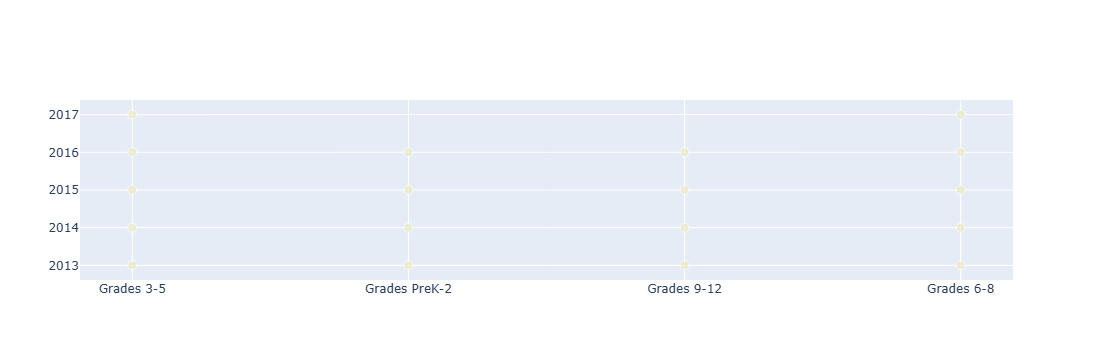

In [146]:
cbp(projects_df, 'Project Grade Level Category', 'Posted Year', 'cost', 'mean', '', 'Earth')

> Para los Grados 6-8 y Grados 9-12, los proyectos con costos altos fueron en el año 2015; para los Grados 3-5 y PreK-2 fueron en 2014,  

## <a id="7.10"> 7.10 Categorías de Grado y Categorías de Recursos con los costos de proyecto más altos </a>  

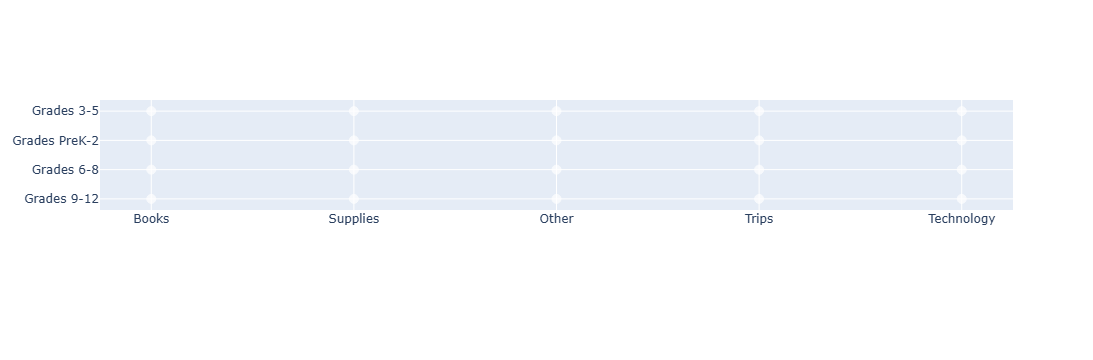

In [147]:
cbp(projects_df, 'Project Resource Category', 'Project Grade Level Category', 'cost', 'mean', '', 'Picnic', bottom_margin=150)

> - Los viajes se organizan principalmente para los grados más altos, es decir, 9-12, seguidos de 6-8 y luego 3-5. Los Grados PreK-2 tienen un número significativamente menor en comparación con los demás grados. Los visitantes (Visitors) son otro recurso clave para todos los grados. 

## <a id="7.11"> 7.11 Cómo varió el Estado del Proyecto por Año </a>  

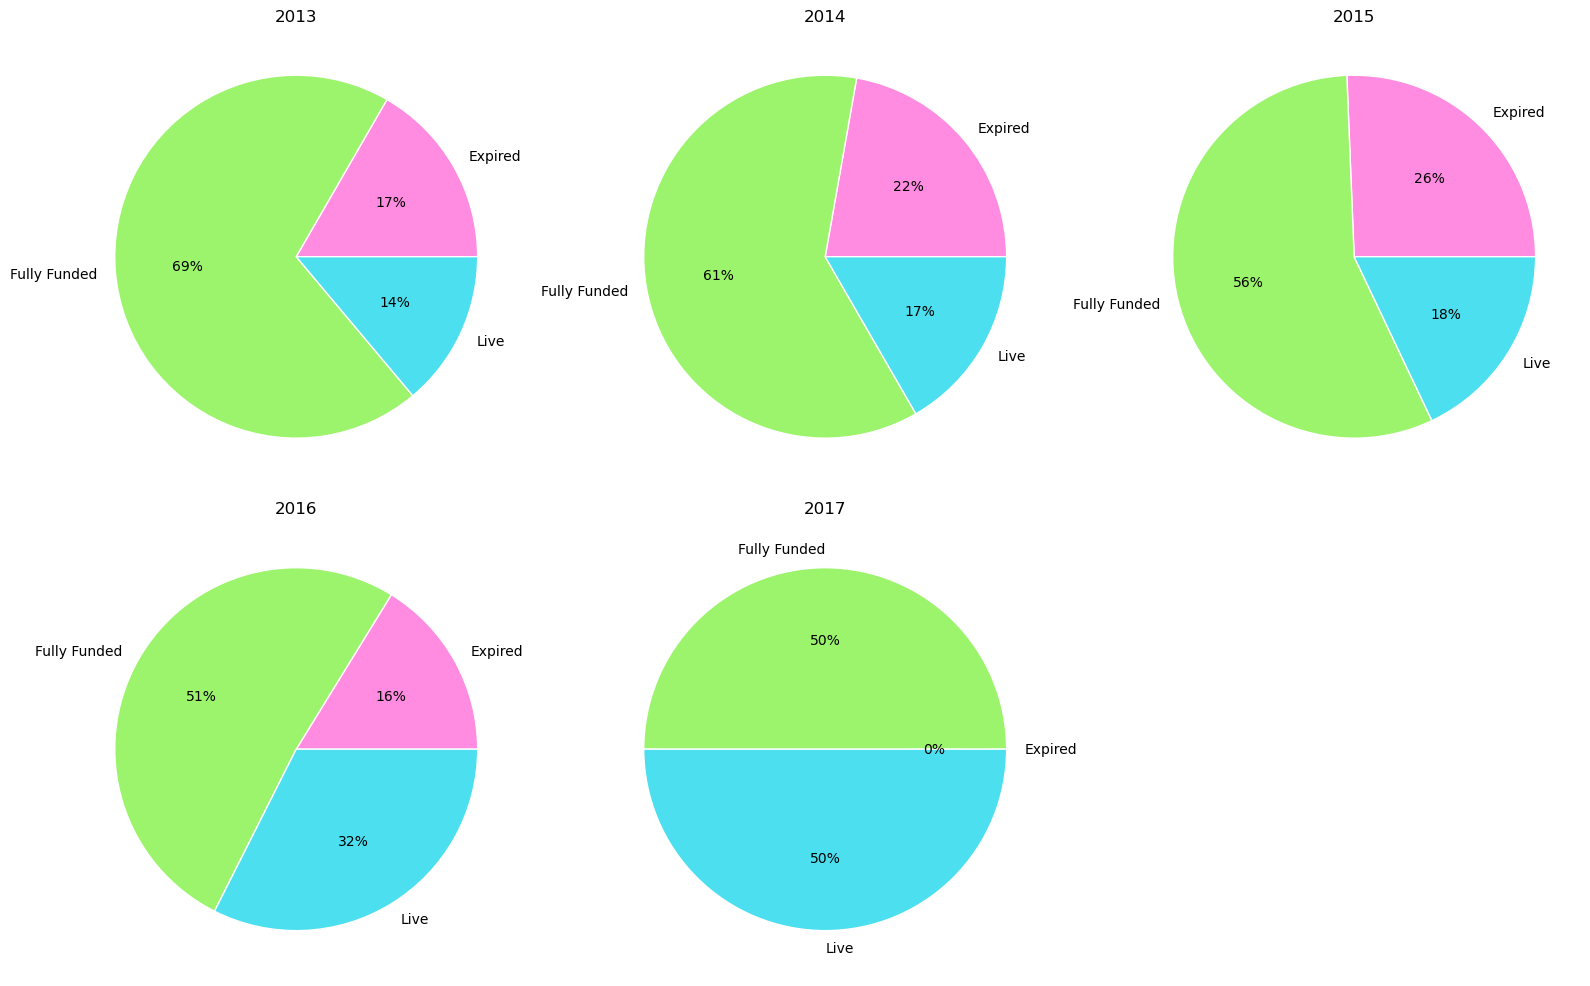

In [149]:
import matplotlib.pyplot as plt
from itertools import zip_longest


years = [2013, 2014, 2015, 2016, 2017, 2018]


plt.figure(figsize=(16,10))


for i, j in zip_longest(years, range(len(years))):

    # Si el año no existe, saltarlo
    if i not in year_tab.columns:
        continue

    plt.subplot(2, 3, j+1)

    plt.pie(
        year_tab[i],
        labels=year_tab["Project Current Status"].tolist(),
        autopct="%1.0f%%",
        colors=[
            "#ff8ce0",
            "#9bf46b",
            "#4cdfef"
        ],
        wedgeprops={
            "linewidth":1,
            "edgecolor":"white"
        }
    )

    plt.title(i)


plt.tight_layout()
plt.show()

> Una revisión año por año de los datos muestra que **alrededor del 70% del total de proyectos** publicados en DonorsChoose en un año se financian por completo. Ha habido una tendencia creciente en el porcentaje de proyectos financiados por completo cada año, **excepto en 2016**, cuando el número de proyectos totalmente financiados disminuyó un 6% respecto al año anterior. 2017 y 2015 fueron los mejores años en términos de proporción de proyectos totalmente financiados, cuando alrededor del **78% de los proyectos** fueron financiados por completo. 

## <a id="7.12"> 7.12 Durante cuántos días permanecieron Activos los proyectos </a>  

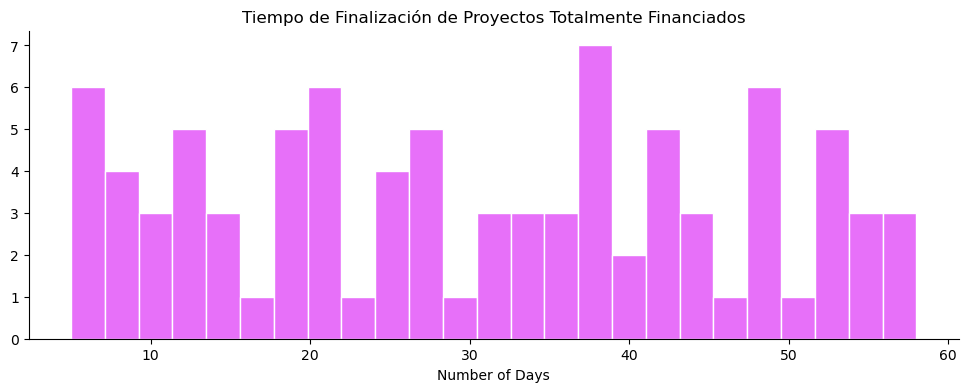

In [150]:
t = projects_df[projects_df['Project Current Status'] == "Fully Funded"]
t['Funding Time'] = t['Funding Time'].apply(lambda x : int(str(x).split()[0]))

plt.figure(figsize=(12,4));
ax = t['Funding Time'].hist(bins=25, edgecolor='white', color="#e770f9")
ax.grid(False);
ax.spines['top'].set_visible(False);
ax.spines['right'].set_visible(False);
plt.xlabel('Number of Days');
plt.title('Tiempo de Finalización de Proyectos Totalmente Financiados');

> - Un mayor número de proyectos tiene un tiempo de finalización menor a 3 días. Alrededor de <b>"55000 proyectos"</b> en el pasado se financiaron exitosamente en un día, mientras que hay alrededor de <b>"48627 proyectos"</b> que se cerraron el mismo día en que se publicaron. El mayor número de días para cualquier proyecto es igual a 288 días, correspondiente al proyecto titulado "**Empty Bowls, Full Hearts.**". Este proyecto tuvo un costo estimado de USD 1982 y fue publicado por la **Harrison Park Elementary School** en Michigan. 

## <a id="7.13"> 7.13 Cómo varía la proporción de proyectos Financiados vs No Financiados según el Estado ? </a>  

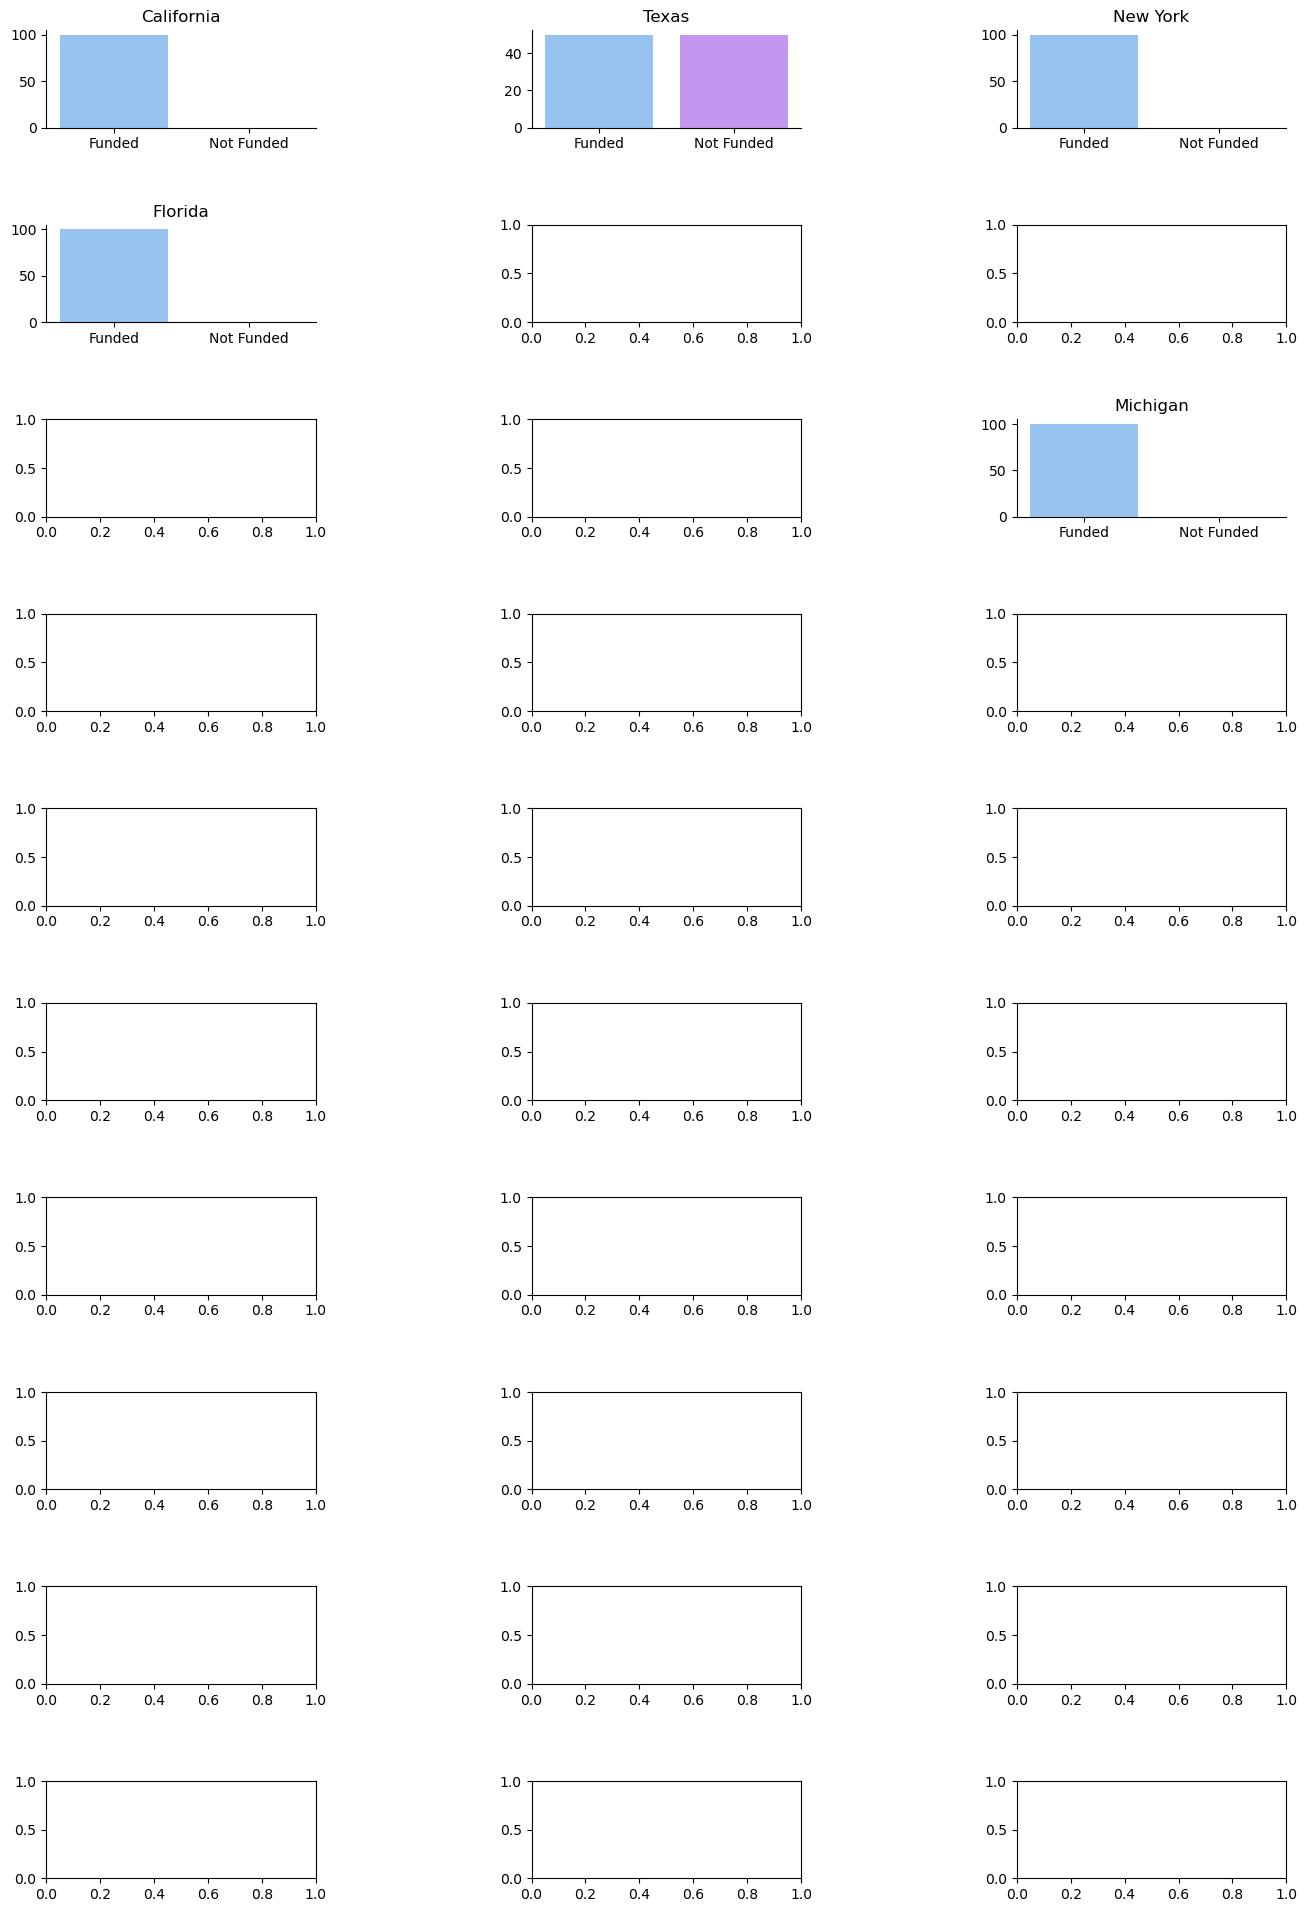

In [152]:
import itertools
import matplotlib.pyplot as plt
import seaborn as sns


projsch_df = projects_df.merge(
    schools_df,
    on="School ID"
)


states = [
    'California', 'Texas', 'New York', 'Florida', 'North Carolina',
    'Illinois', 'Georgia', 'South Carolina', 'Michigan',
    'Pennsylvania', 'Massachusetts', 'Indiana', 'Oklahoma',
    'Washington', 'Ohio', 'New Jersey', 'Missouri', 'Arizona',
    'Virginia', 'Louisiana', 'Tennessee', 'Utah', 'Wisconsin',
    'Connecticut', 'Alabama', 'Maryland', 'Nevada', 'Oregon',
    'Colorado', 'Mississippi'
]


plt.figure(figsize=(16,24))


for i,j in itertools.zip_longest(states, range(len(states))):

    plt.subplot(10,3,j+1)


    # Contar estados de proyectos por estado
    t = dict(
        projsch_df[
            projsch_df['School State'] == i
        ]['Project Current Status']
        .value_counts()
    )


    # Evitar errores si falta algún estado
    funded = t.get('Fully Funded', 0)
    expired = t.get('Expired', 0)


    total = funded + expired


    if total == 0:
        continue


    t1 = {
        'Funded': funded * 100 / total,
        'Not Funded': expired * 100 / total
    }


    ax = sns.barplot(
        x=list(t1.keys()),
        y=list(t1.values()),
        alpha=.7,
        palette='cool'
    )


    ax.grid(False)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


    plt.title(
        i,
        color="black"
    )


plt.subplots_adjust(
    wspace=.8,
    hspace=1
)

plt.show()

> - Algunos de los estados donde el porcentaje de proyectos Expirados o No Financiados es menor son "Georgia", "Carolina del Sur" y "Mississippi". 

## <a id="7.14"> 7.14 Cuál es el Costo Promedio de los Proyectos según el Tipo de Zona Metropolitana Escolar y la categoría de Recurso Solicitado ? </a>  

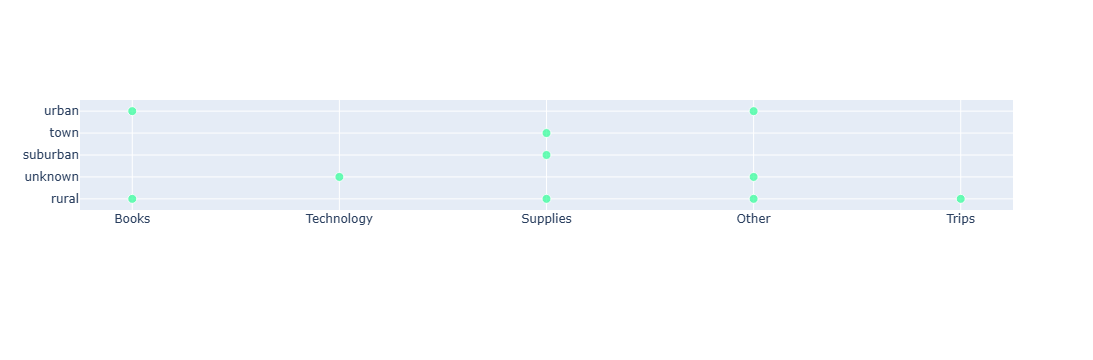

In [153]:
cbp(projsch_df, 'Project Resource Category', 'School Metro Type', 'cost', 'mean', '', 'Rainbow', bottom_margin = 150)

> Viajes y Visitantes son siempre las categorías más costosas entre todos los diferentes tipos de zona metropolitana escolar. "Towns" (pueblos) tiene el costo promedio más alto para los proyectos en los que se solicitaron recursos pertenecientes a Equipos de Deporte y Ejercicio. 

## <a id="7.15"> 7.15 Cuál es el Costo Promedio de los Proyectos según el Tipo de Zona Metropolitana Escolar y la Categoría de Nivel de Grado de los Proyectos ? </a>  

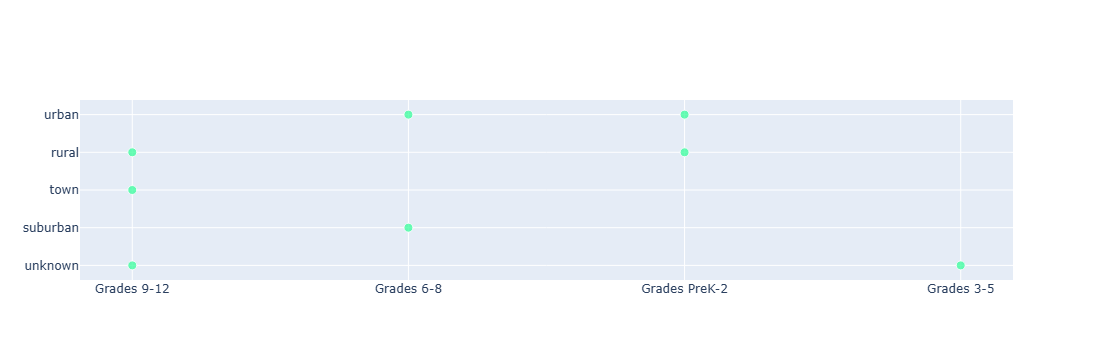

In [154]:
cbp(projsch_df, 'Project Grade Level Category', 'School Metro Type', 'cost', 'mean', '', 'Rainbow')

> Los Grados 9-12 tienen el costo promedio de proyecto más alto en comparación con cualquier otra categoría de grado. Entre ellos, las zonas suburbanas (SubUrban) tienen los precios de proyecto más altos, mientras que los pueblos (towns) tienen los más bajos. 

## <a id="8">8. Procesamiento de Lenguaje Natural para el Perfilado de Proyectos </a>

Se puede construir mucho entendimiento utilizando el análisis de texto de los Ensayos de Proyectos. Realicemos algunos análisis de texto básicos / procesamiento de lenguaje natural para extraer la información relevante de los ensayos de los proyectos. Para este propósito, me estoy enfocando en un subconjunto de proyectos recientes de abril de 2018. 

## <a id="8.1">8.1 Limpieza de Texto </a>

Escribamos una función utilitaria que normalice el texto y elimine el ruido. Esta función de limpieza de texto realiza la eliminación de palabras vacías (stopwords) del texto y la eliminación de signos de puntuación.

In [156]:
!pip install textblob

   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 625.0/625.0 kB 3.6 MB/s  0:00:00


In [157]:
import textblob

In [158]:
import nltk

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\miche\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [160]:
print(projects_df.columns.tolist())

['Project ID', 'School ID', 'Teacher ID', 'Teacher Project Posted Sequence', 'Project Type', 'Project Title', 'Project Essay', 'Project Subject Category Tree', 'Project Subject Subcategory Tree', 'Project Grade Level Category', 'Project Resource Category', 'Project Cost', 'Project Posted Date', 'Project Current Status', 'Project Fully Funded Date', 'Posted Date', 'Posted Year', 'Posted Month', 'Posted Day', 'Posted Quarter', 'Funded Date', 'Funded Year', 'Funded Month', 'Funded Day', 'Funded Quarter', 'Funding Time', 'cost', 'School Name', 'School Metro Type', 'School Percentage Free Lunch', 'School State', 'School Zip', 'School City', 'School County', 'School District']


In [174]:
from nltk.corpus import stopwords
import string
import nltk
import pandas as pd

nltk.download('stopwords')

stopwords = set(stopwords.words("english"))


def _clean(txt):

    if pd.isna(txt):
        return ""

    txt = str(txt).lower()

    # eliminar puntuación
    txt = ''.join(x for x in txt if x not in string.punctuation)

    clean_txt = ""

    for word in txt.split():

        if word in stopwords:
            continue

        clean_txt += " " + word


    noise = [
        'students',
        'my',
        'title',
        'would',
        'every',
        'will',
        'many',
        'also',
        'donotremoveessaydivider'
    ]

    for ns in noise:
        clean_txt = clean_txt.replace(ns, "")

    return clean_txt



# NO HACEMOS MERGE PORQUE YA EXISTE EN projects_df


# proyectos publicados en abril 2018
april18_df = projects_df[
    (projects_df['Posted Year'] == 2018) &
    (projects_df['Posted Month'] == 4)
].copy()



# limpiar Project Essay
april18_df['clean_essay'] = (
    april18_df['Project Essay']
    .fillna("")
    .apply(_clean)
)



# reemplazo de Project Need Statement
# porque esa columna ya no existe en la versión actual
april18_df['clean_need'] = april18_df['clean_essay']



# revisar resultados
april18_df[
    [
        'Project Title',
        'clean_essay',
        'clean_need'
    ]
].head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\miche\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,Project Title,clean_essay,clean_need


In [165]:
april18_df[['Project Title','clean_essay']].head(5).to_string()

'Empty DataFrame\nColumns: [Project Title, clean_essay]\nIndex: []'

In [168]:
print(len(april18_df))

0


In [169]:
print(projects_df['Posted Year'].unique())
print(projects_df['Posted Month'].unique())

[2013 2015 2014 2016]
[ 1  8 10 11 12  4  9  5  6]


In [170]:
projects_df[['Posted Date','Posted Year','Posted Month']].head(10)

,Posted Date,Posted Year,Posted Month
0,2013-01-07,2013,1
1,2015-08-06,2015,8
2,2013-08-08,2013,8
3,2014-10-05,2014,10
4,2014-11-08,2014,11
5,2015-12-05,2015,12
6,2014-04-24,2014,4
7,2016-09-17,2016,9
8,2016-05-12,2016,5
9,2015-04-10,2015,4


In [171]:
april18_df = projects_df[
    (projects_df['Posted Year'] == 2018) &
    (projects_df['Posted Month'] == 'April')
].copy()

In [172]:
april18_df = projects_df[
    projects_df['Posted Year'] == 2018
].copy()

## <a id="8.2"> 8.2 Análisis de Bolsa de Palabras </a> 

## <a id="8.2.1"> 8.2.1 Cuáles son las palabras y frases principales usadas por los Maestros en los Ensayos </a> 

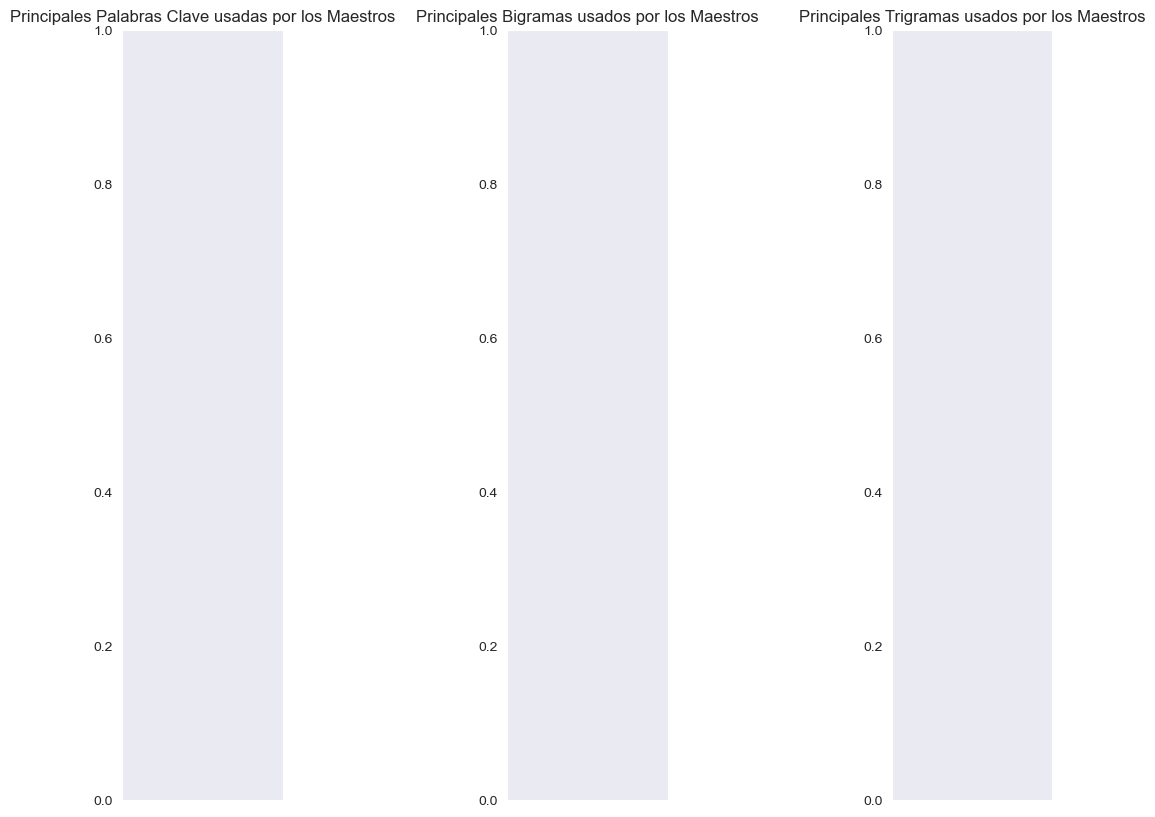

In [175]:
### Bag of Words 
from collections import Counter
def generate_ngrams(txt, N):
    grams = [txt[i:i+N] for i in range(len(txt)-N+1)]
    grams = [" ".join(b) for b in grams]
    return grams 

april18_df['unigrams'] = april18_df['clean_essay'].apply(lambda x : generate_ngrams(x.split(), 1))
april18_df['bigrams'] = april18_df['clean_essay'].apply(lambda x : generate_ngrams(x.split(), 2))
april18_df['trigrams'] = april18_df['clean_essay'].apply(lambda x : generate_ngrams(x.split(), 3))

all_unigrams = []
for each in april18_df['unigrams']:
    all_unigrams.extend(each)
t = Counter(all_unigrams).most_common(25)
x = [a[0] for a in t]
y = [a[1] for a in t]

all_bigrams = []
for each in april18_df['bigrams']:
    all_bigrams.extend(each)
t1 = Counter(all_bigrams).most_common(25)
x1 = [a[0] for a in t1]
y1 = [a[1] for a in t1]


all_trigrams = []
for each in april18_df['trigrams']:
    all_trigrams.extend(each)
t2 = Counter(all_trigrams).most_common(25)
x2 = [a[0] for a in t2]
y2 = [a[1] for a in t2]

sns.set_style("dark")
fig, axes = plt.subplots(nrows=1, ncols=5, squeeze=True, figsize = (12,10));

bar = sns.barplot(y=x, x=y, ax=axes[0], palette='GnBu_d', edgecolor="white");
bar.set(xlabel='', xticks=[]);
axes[0].set_title("Principales Palabras Clave usadas por los Maestros");

fig.delaxes(axes[1]);

bar1 = sns.barplot(y=x1, x=y1, ax=axes[2], palette='GnBu_d', edgecolor="white");
bar1.set(xlabel='', xticks=[]);
axes[2].set_title("Principales Bigramas usados por los Maestros");

fig.delaxes(axes[3]);

bar1 = sns.barplot(y=x2, x=y2, ax=axes[4], palette='GnBu_d', edgecolor="white");
bar1.set(xlabel='', xticks=[]);
axes[4].set_title("Principales Trigramas usados por los Maestros");

> Las palabras clave más usadas en todos los ensayos, en todos los estados y en todos los tipos de escuela son <b>"school" (escuela), "learning" (aprendizaje), "classroom" (aula), "reading" (lectura)</b>. Mientras que los Bigramas incluyen un enfoque principal en <b>"flexible seating" (asientos flexibles)</b> y <b>"english language" (idioma inglés)</b>. Un gran número de ensayos de maestros tratan sobre <b>"Desayuno y Almuerzo Gratuitos"</b>, <b>"aprendizaje del idioma inglés"</b>, "<b>varios desafíos enfrentados</b>"

## <a id="8.2.2"> 8.2.2 Cómo varían las frases principales usadas según el Estado </a> 

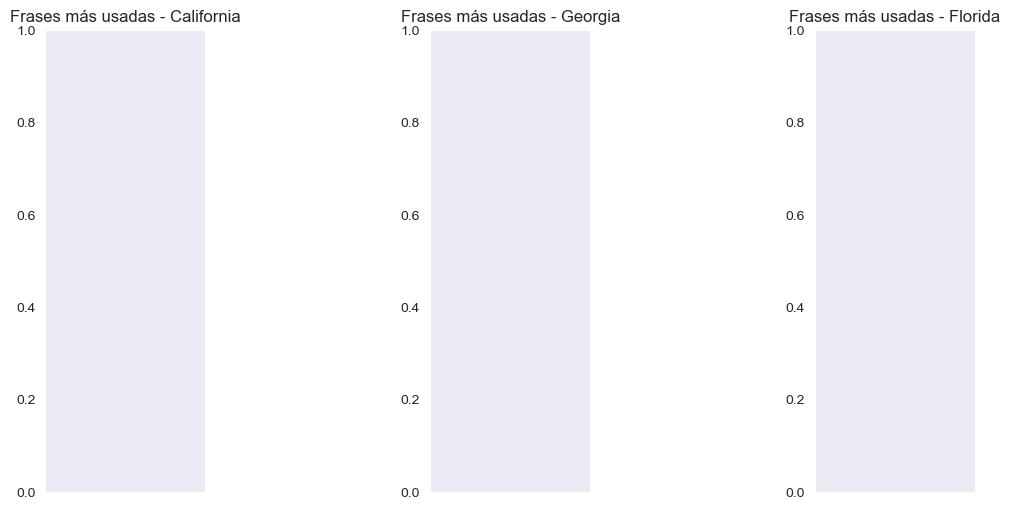

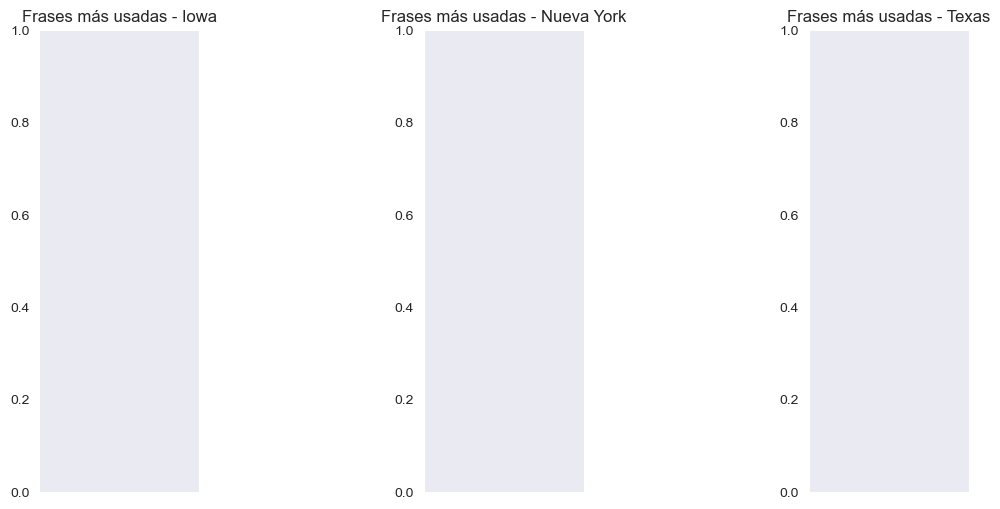

In [176]:
ignores = ['every day', 'come school']
all_unigrams = []
for each in april18_df[april18_df['School State'] == 'California']['trigrams']:
    all_unigrams.extend([x for x in each if x not in ignores])
t = Counter(all_unigrams).most_common(15)
x = [a[0] for a in t]
y = [a[1] for a in t]

all_bigrams = []
for each in april18_df[april18_df['School State'] == 'Georgia']['trigrams']:
    all_bigrams.extend([x for x in each if x not in ignores])
t1 = Counter(all_bigrams).most_common(15)
x1 = [a[0] for a in t1]
y1 = [a[1] for a in t1]

all_trigrams = []
for each in april18_df[april18_df['School State'] == 'Florida']['trigrams']:
    all_trigrams.extend([x for x in each if x not in ignores])
t2 = Counter(all_trigrams).most_common(15)
x2 = [a[0] for a in t2]
y2 = [a[1] for a in t2]

sns.set_style("dark")
fig, axes = plt.subplots(nrows=1, ncols=5, squeeze=True, figsize = (12,6));

bar = sns.barplot(y=x, x=y, ax=axes[0], palette='GnBu_d', edgecolor="white");
bar.set(xlabel='', xticks=[]);
axes[0].set_title("Frases más usadas - California");

fig.delaxes(axes[1]);

bar1 = sns.barplot(y=x1, x=y1, ax=axes[2], palette='GnBu_d', edgecolor="white");
bar1.set(xlabel='', xticks=[]);
axes[2].set_title("Frases más usadas - Georgia");

fig.delaxes(axes[3]);

bar1 = sns.barplot(y=x2, x=y2, ax=axes[4], palette='GnBu_d', edgecolor="white");
bar1.set(xlabel='', xticks=[]);
axes[4].set_title("Frases más usadas - Florida");

all_unigrams = []
for each in april18_df[april18_df['School State'] == 'Iowa']['trigrams']:
    all_unigrams.extend([x for x in each if x not in ignores])
t = Counter(all_unigrams).most_common(15)
x = [a[0] for a in t]
y = [a[1] for a in t]

all_bigrams = []
for each in april18_df[april18_df['School State'] == 'New York']['trigrams']:
    all_bigrams.extend([x for x in each if x not in ignores])
t1 = Counter(all_bigrams).most_common(15)
x1 = [a[0] for a in t1]
y1 = [a[1] for a in t1]

all_trigrams = []
for each in april18_df[april18_df['School State'] == 'Texas']['trigrams']:
    all_trigrams.extend([x for x in each if x not in ignores])
t2 = Counter(all_trigrams).most_common(15)
x2 = [a[0] for a in t2]
y2 = [a[1] for a in t2]

sns.set_style("dark")
fig, axes = plt.subplots(nrows=1, ncols=5, squeeze=True, figsize = (12,6));

bar = sns.barplot(y=x, x=y, ax=axes[0], palette='GnBu_d', edgecolor="white");
bar.set(xlabel='', xticks=[]);
axes[0].set_title("Frases más usadas - Iowa");

fig.delaxes(axes[1]);

bar1 = sns.barplot(y=x1, x=y1, ax=axes[2], palette='GnBu_d', edgecolor="white");
bar1.set(xlabel='', xticks=[]);
axes[2].set_title("Frases más usadas - Nueva York");

fig.delaxes(axes[3]);

bar1 = sns.barplot(y=x2, x=y2, ax=axes[4], palette='GnBu_d', edgecolor="white");
bar1.set(xlabel='', xticks=[]);
axes[4].set_title("Frases más usadas - Texas");

> - El enfoque principal de los ensayos entre los diferentes estados es en gran parte el mismo, aunque se pueden observar algunas diferencias en estados como Texas, donde un gran número de ensayos tratan sobre <b>estudiantes afectados por el Huracán Harvey</b>. Los maestros han descrito "varios desafíos enfrentados" por los estudiantes; <b>"Opciones de Asientos Flexibles"</b> es el enfoque principal de la mayoría de los ensayos. 
> - En Iowa, los maestros han descrito sobre <b>"estudiantes que provienen de diferentes orígenes"</b> y <b>"diferentes nacionalidades"</b>. En Nueva York, los ensayos también se enfocan en <b>"maestros de educación especial"</b>, <b>"escuelas en distritos de pobreza"</b>, y <b>"bajos ingresos"</b>
> - En Florida, los maestros han mencionado <b>"precios reducidos de desayuno y almuerzo"</b>

## <a id="8.2.3"> 8.2.3 "<i>Mis Estudiantes Son ______ ______ ______</i> " : Qué describen los maestros sobre sus estudiantes </a> 

In [177]:
from textblob import TextBlob, Word
from wordcloud import WordCloud, STOPWORDS
from PIL import Image
mask = np.array(Image.open('../input/word-cloud-masks/cloud1.png'))

mystudents = []
for x in april18_df['Project Essay']:
    if x.lower().startswith("my students are"):
        phrase = " ".join(x.replace('My students are', '').split(". ")[0].split("!")[0].strip().split()[:6])
        mystudents.append(phrase)

t3 = Counter(mystudents).most_common(25)
x = [a[0] for a in t3]
y = [a[1] for a in t3]

sns.set_style("dark")
plt.figure(figsize = (12,10))
plt.title("Contexto de Mis Estudiantes Son ___ ___ ___ ");
bar = sns.barplot(y=x, x=y, palette="BuGn_r", edgecolor="white");
bar.set(xlabel='', xticks=[]);


FileNotFoundError: [Errno 2] No such file or directory: '../input/word-cloud-masks/cloud1.png'

> - Los maestros usaron muchos adjetivos para describir a sus estudiantes, por ejemplo: <b>"amazing" (increíbles), "awesome" (asombrosos), "Incredible" (increíbles), "creative" (creativos)</b>. Mientras que en algunos ensayos, los maestros describen a sus estudiantes como <b>"muy especiales para ellos" y "extraordinarios"</b>

## <a id="8.2.4"> 8.2.4 Según lo descrito por los Maestros, Qué Necesitan los Estudiantes ______ ______ ______ </a>

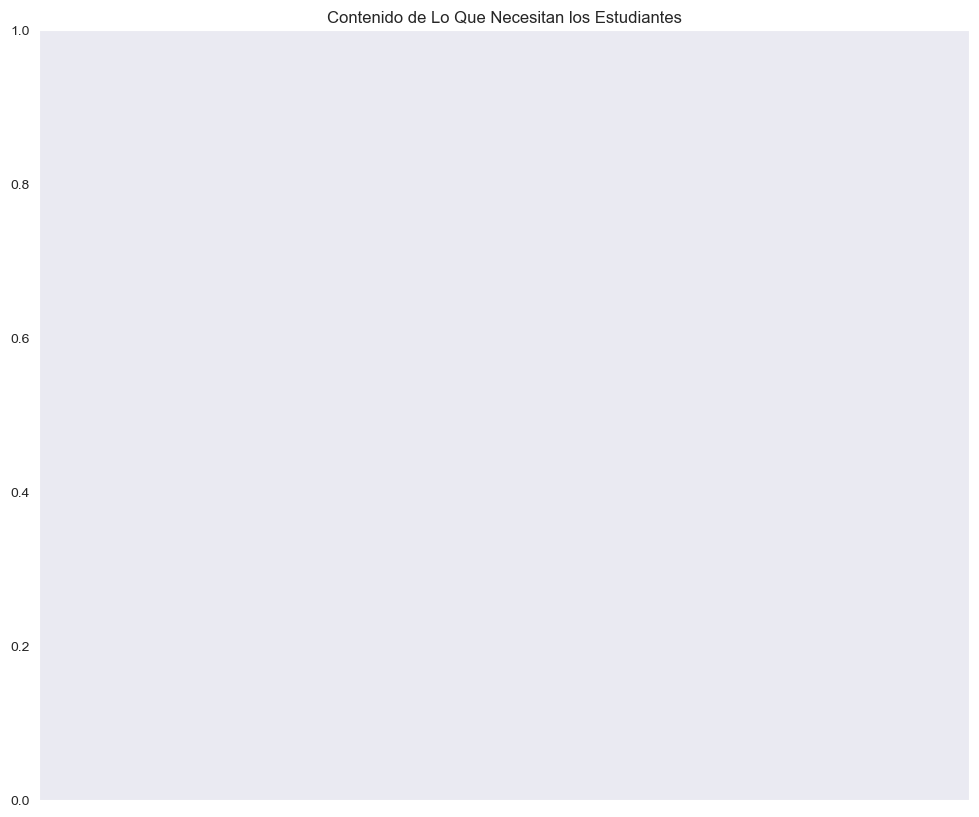

In [178]:
mystudents = []
for x in april18_df['clean_need']:
    if x.lower().strip().startswith("need"):
        phrase = " ".join(x.lower().strip().replace('need', '').split(". ")[0].split("!")[0].strip().split()[:3])
        mystudents.append(phrase)

t3 = Counter(mystudents).most_common(25)
x = [a[0] for a in t3]
y = [a[1] for a in t3]

sns.set_style("dark")
plt.figure(figsize = (12,10))
plt.title("Contenido de Lo Que Necesitan los Estudiantes")
bar = sns.barplot(y=x, x=y, palette="BuGn_r", edgecolor="white");
bar.set(xlabel='', xticks=[]);
axes[0].set_title("Principales Palabras Clave");

> - Aparte de la principal necesidad sugerida por los maestros, es decir, <b>"Opciones de asientos flexibles"</b>. Otras necesidades principales son <b>"Robot de Programación"</b>, <b>"Útiles Escolares Básicos"</b>. Dentro de los asientos flexibles, se enfocan principalmente en las <b>"Sillas Oscilantes y Asientos de Balón de Equilibrio"</b>. Otras necesidades relacionadas con tecnología incluyen <b>"Tabletas Amazon Fire"</b>, <b>"Juego de Audífonos"</b>, y <b>"Osmo Genius Kit"</b>


## <a href="8.2.5"> 8.2.5 Título del Proyecto : Palabras más Usadas </a>

In [179]:
text = " ".join(april18_df['Project Title']).lower()
for w in ['need', 'student', 'classroom']: # remove some additional noise 
    text = text.replace(w, " ")
wc = WordCloud(max_words=1200, stopwords=STOPWORDS, colormap='cool', background_color='White', mask=mask).generate(text)
plt.figure(figsize=(13,13))
plt.imshow(wc)
plt.axis('off')
plt.title('');

NameError: name 'mask' is not defined

Temas como Asientos Flexibles, Chromebook, Lectura, Aprendizaje, Tecnología y libros son el enfoque principal de un gran número de maestros para sus estudiantes

## <a href="9"> 9. Entendiendo y Comparando Características Clave de los Proyectos </a>

## <a href="9.1"> 9.1 Proyectos Expirados vs Proyectos Financiados </a> 

En esta sección, exploremos y entendamos las características clave de los proyectos que se financiaron exitosamente y comparémoslos con los proyectos que expiraron. Me enfocaré en los proyectos del año pasado, es decir, 2017.

In [180]:
expired = projects_df[projects_df['Posted Year'] == 2017][projects_df['Project Current Status'] == 'Expired']
funded = projects_df[projects_df['Posted Year'] == 2017][projects_df['Project Current Status'] == 'Fully Funded']

expired = expired.merge(teachers_df, on="Teacher ID")
funded = funded.merge(teachers_df, on="Teacher ID")


def get_trace(col, func, flag=None,leg=False):

    t1 = expired[col].value_counts()
    t2 = funded[col].value_counts()

    if flag == 'num':
        t1 = expired[expired['NumProjects'] <= 20][col].value_counts()    
        t2 = funded[funded['NumProjects'] <= 20][col].value_counts() 
    
    trace1 = func(
        x=t1.index,
        y=[float(a)*100/sum(t1.values) for a in t1.values],
        name='Expired',
        marker=dict(color='#e82041'),
        showlegend=leg,
        opacity=0.9
    )
    trace2 = func(
        x=t2.index,
        y=[float(a)*100/sum(t2.values) for a in t2.values],
        name='Funded',
        marker=dict(color='#0de286'),
        opacity=0.9, showlegend=leg
    )
    
#     trace2 = func(x=t2.index, 
#                   y= [], 
#                   name='Funded', 
#                   marker=(), 
#                   opacity=0.5)
    return trace1, trace2

tr1, tr2 = get_trace('Project Grade Level Category', go.Scatter)
tr3, tr4 = get_trace('School Metro Type', go.Scatter)
tr5, tr6 = get_trace('School State', go.Bar)
tr7, tr8 = get_trace('Project Resource Category', go.Bar)
tr9, tr10 = get_trace('Posted Month', go.Bar, leg=True)


########################
expired['wc'] = expired['Project Essay'].apply(lambda x : len(x.split()))
funded['wc'] = funded['Project Essay'].apply(lambda x : len(x.split()))

bins = [0, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 10000]

expired['wc'] = pd.cut(expired['wc'], bins)
t1 = dict(expired['wc'].value_counts())
labels = [str(b).replace("]","").replace("(","").replace(", ","-") for b in t1.keys()]
vals = [float(a)*100/sum(t1.values()) for a in list(t1.values())]
d = {}
for i, v in enumerate(labels):
    d[v] = vals[i]
order = ['0-50', '50-100', '100-150', '150-200', '200-250', '250-300', '300-350', '350-400', '400-450', '450-500', '500-10000',]
values = [d[v] for v in order]

tr13 = go.Bar(
    x=order,
    y=values,
    name='Expired',
    marker=dict(color='#e82041'),
    opacity=0.9
)


funded['wc'] = pd.cut(funded['wc'], bins)
t2 = dict(funded['wc'].value_counts())
labels = [str(b).replace("]","").replace("(","").replace(", ","-") for b in t1.keys()]
vals = [float(a)*100/sum(t2.values()) for a in list(t2.values())]
d = {}
for i, v in enumerate(labels):
    d[v] = vals[i]
order = ['0-50', '50-100', '100-150', '150-200', '200-250', '250-300', '300-350', '350-400', '400-450', '450-500', '500-10000',]
values = [d[v] for v in order]

tr14 = go.Bar(
    x=order,
    y=values,
    name='Funded',
    marker=dict(color='#0de286'),
    opacity=0.9
)



############### cost ###########
bins = [0, 100, 500, 1000, 1500, 2000, 2500, 3000, 70000]

expired['binnedcost'] = pd.cut(expired['cost'], bins)
t1 = dict(expired['binnedcost'].value_counts())
labels = [str(b).replace("]","").replace("(","").replace(", ","-") for b in t1.keys()]
vals = [float(a)*100/sum(t1.values()) for a in list(t1.values())]
d = {}
for i, v in enumerate(labels):
    d[v] = vals[i]
order = ['100-500', '500-1000', '1000-1500', '1500-2000', '2000-2500', '2500-3000', '3000-70000']
values = [d[v] for v in order]

tr15 = go.Scatter(
    x=order,
    y=values,
    name='Expired',fill='tozeroy',
    marker=dict(color='#e82041'),
    opacity=0.9
)


funded['binnedcost'] = pd.cut(funded['cost'], bins)
t2 = dict(funded['binnedcost'].value_counts())
labels = [str(b).replace("]","").replace("(","").replace(", ","-") for b in t1.keys()]
vals = [float(a)*100/sum(t2.values()) for a in list(t2.values())]
d = {}
for i, v in enumerate(labels):
    d[v] = vals[i]
values = [d[v] for v in order]

tr16 = go.Scatter(
    x=order,
    y=values,
    name='Funded',fill='tozeroy',
    marker=dict(color='#0de286'),
    opacity=0.9)



#############


titles = ['Project Grade Level Category', "School Metro Type","Project Cost (in $)", 
          "Project Essay Word Count", "Project Posted Month", "Resource Category"]
fig = tools.make_subplots(rows=3, cols=2, subplot_titles=titles, print_grid=False, specs=[[{}, {}],
                                                                  [{},{}], 
                                                                  [{}, {}],]) 
#                                                                   [{'colspan':2}, None],
#                                                                   [{}, None]
fig.append_trace(tr1, 1,1)
fig.append_trace(tr2, 1,1)
fig.append_trace(tr3, 1,2)
fig.append_trace(tr4, 1,2)
fig.append_trace(tr15, 2,1)
fig.append_trace(tr16, 2,1)
fig.append_trace(tr13, 2,2)
fig.append_trace(tr14, 2,2)
fig.append_trace(tr7, 3,2)
fig.append_trace(tr8, 3,2)
fig.append_trace(tr9, 3,1)
fig.append_trace(tr10, 3,1)

fig['layout'].update(barmode='group',
  
    title = 'Comparación de Características Clave del Proyecto: <b>Proyectos Expirados Vs Financiados</b> <br>',
    titlefont=dict(
            size=22,
            color='#000'
        ),
                     
    margin=dict(t=100, b=100),
    paper_bgcolor='rgb(254, 247, 234)',
    plot_bgcolor='rgb(254, 247, 234)',
    height=1000)
iplot(fig);

ValueError: Invalid property specified for object of type plotly.graph_objs.Layout: 'titlefont'

Did you mean "title"?

    Valid properties:
        activeselection
            :class:`plotly.graph_objects.layout.Activeselection`
            instance or dict with compatible properties
        activeshape
            :class:`plotly.graph_objects.layout.Activeshape`
            instance or dict with compatible properties
        annotations
            A tuple of
            :class:`plotly.graph_objects.layout.Annotation`
            instances or dicts with compatible properties
        annotationdefaults
            When used in a template (as
            layout.template.layout.annotationdefaults), sets the
            default property values to use for elements of
            layout.annotations
        autosize
            Determines whether or not a layout width or height that
            has been left undefined by the user is initialized on
            each relayout. Note that, rega

In [ ]:
pos_text_cln = " ".join(funded['Project Title'])
neg_text_cln = " ".join(expired['Project Title'])

def green_color(word, font_size, position, orientation, random_state=None, **kwargs):
    return 'hsl({:d}, 80%, {:d}%)'.format(random.randint(85, 140), random.randint(60, 80))

def red_color(word, font_size, position, orientation, random_state=None, **kwargs):
    return 'hsl({:d}, 80%, {:d}%)'.format(random.randint(0, 35), random.randint(60, 80))
    
from PIL import Image
mask = np.array(Image.open('../input/word-cloud-masks/cloud1.png'))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=[15, 8], facecolor='#fef7ea')

wordcloud1 = WordCloud(max_words=1200,colormap='magma',
                       background_color='rgb(254, 247, 234)',mask=mask).generate(neg_text_cln)
ax1.imshow(wordcloud1)
ax1.axis('off');
ax1.set_title('Palabras Principales - Proyectos Expirados');

wordcloud2 = WordCloud(max_words=1200,colormap='nipy_spectral', background_color='rgb(254, 247, 234)', mask=mask
                      ).generate(pos_text_cln)
ax2.imshow(wordcloud2)
ax2.axis('off');
ax2.set_title('Palabras Principales - Proyectos Financiados');

> La comparación muestra los siguientes hallazgos: 
> - Los proyectos que pertenecían al **Nivel de Grado PreK-2** tienen un porcentaje más alto de proyectos exitosos que de expirados. Mientras que todos los demás grados tienen un porcentaje más alto de proyectos expirados que de proyectos financiados exitosamente. Tal vez los donantes prefieren **donar a niños de grados más bajos** que a los de grados más altos. 
> - Los proyectos financiados exitosamente tienen un porcentaje más alto en escuelas ubicadas en **zonas Urbanas**, mientras que los proyectos Expirados tienen un porcentaje más alto en escuelas ubicadas en **zonas rurales, suburbanas o pueblos**.  
> - Otra característica de los proyectos financiados está relacionada con el costo del proyecto. Los proyectos cuyo costo total es menor a USD 500 tienen un porcentaje muy alto de proyectos financiados exitosamente, mientras que lo contrario también es cierto: un alto porcentaje de proyectos que expiraron tiene costos más altos, es decir, mayores a USD 500.  
> - Los ensayos de los proyectos son una parte esencial de los proyectos de donorschoose, y el número de palabras usadas en el texto juega un buen papel en el resultado del proyecto, como se ve en la 4ta gráfica: los proyectos que se financian exitosamente son más comunes en proyectos con un **conteo de palabras del ensayo mayor a 250**. Esto indica que se debe alentar a los maestros a escribir de manera más completa sobre los proyectos. 
> - Un número significativo de proyectos que se publican en el cuarto trimestre del año calendario, es decir, entre **octubre y diciembre**, se financian exitosamente en su mayoría. Esto indica un buen período de tiempo en el que los donantes tienden a donar más. Tal vez los maestros que sienten que no están recibiendo donaciones en sus proyectos podrían comenzar a publicarlos en los meses de noviembre y diciembre. Todos los demás meses del año tienen un porcentaje más alto de proyectos expirados que de proyectos financiados.  
> - Un hallazgo interesante se observa entre los proyectos que expiraron: un gran porcentaje de dichos proyectos tenía un alto costo de requisitos técnicos como **iPads, Chromebooks**, etc. Las categorías de recursos **suministros y tecnología** tienen un número muy alto de proyectos expirados. 
> - En todo EE. UU., hay pocos estados en los que el porcentaje de proyectos Financiados es mayor que el porcentaje de proyectos expirados. Algunos de esos estados son: **Illinois, Massachusetts, Oklahoma**. El porcentaje de proyectos expirados es más alto en los demás estados. Tal vez donorschoose pueda aumentar el marketing y las campañas de correo electrónico para atraer donantes de estos estados.   
> - Un porcentaje más alto de proyectos financiados solicitaba **Asientos Flexibles y materiales de Lectura**, mientras que los proyectos expirados tenían un alto porcentaje de **artículos relacionados con Tecnología**. 


## <a href="9.2"> 9.2 Proyectos con Duración de Financiamiento Baja Vs Alta </a> 

Comparemos ahora las características de los proyectos que se financiaron exitosamente en un período corto, es decir, menos de 1 día, frente a los proyectos que tardaron más de 2 meses en financiarse.

In [ ]:
projects_df['time'] = projects_df['Funding Time'].apply(lambda x : str(x).split()[0])

tempdf = projects_df[projects_df['time'] != "NaT"]
tempdf['time'] = tempdf['time'].apply(int)
tempdf = tempdf[tempdf['Posted Year'] == 2017]

df1 = tempdf[tempdf['time'] <= 1] 
df2 = tempdf[tempdf['time'] >= 60] 

df1 = df1.merge(teachers_df, on="Teacher ID")
df2 = df2.merge(teachers_df, on="Teacher ID")




def get_trace(col, func, flag=None, leg=False):

    t1 = df1[col].value_counts()
    t2 = df2[col].value_counts()

    if flag == 'num':
        t1 = df1[df1['NumProjects'] <= 20][col].value_counts()    
        t2 = df2[df2['NumProjects'] <= 20][col].value_counts() 
    
    trace1 = func(
        x=t1.index,
        y=[float(a)*100/sum(t1.values) for a in t1.values],
        name='Small Funding Duration',
        marker=dict(color='#0de286'),
        showlegend=leg,
        opacity=0.9
    )
    trace2 = func(
        x=t2.index,
        y=[float(a)*100/sum(t2.values) for a in t2.values],
        name='Large Funding Duration',
        marker=dict(color='#e82041'),
        opacity=0.9, 
        showlegend=leg
    )
    return trace1, trace2

tr1, tr2 = get_trace('Project Grade Level Category', go.Scatter)
tr3, tr4 = get_trace('School Metro Type', go.Scatter)
tr5, tr6 = get_trace('School State', go.Bar)
tr7, tr8 = get_trace('Project Resource Category', go.Bar)
tr9, tr10 = get_trace('Posted Month', go.Bar, leg=True)


########################
df1['wc'] = df1['Project Essay'].apply(lambda x : len(x.split()))
df2['wc'] = df2['Project Essay'].apply(lambda x : len(x.split()))

bins = [0, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 10000]

df1['wc'] = pd.cut(df1['wc'], bins)
t1 = dict(df1['wc'].value_counts())
labels = [str(b).replace("]","").replace("(","").replace(", ","-") for b in t1.keys()]
vals = [float(a)*100/sum(t1.values()) for a in list(t1.values())]
d = {}
for i, v in enumerate(labels):
    d[v] = vals[i]
order = ['0-50', '50-100', '100-150', '150-200', '200-250', '250-300', '300-350', '350-400', '400-450', '450-500', '500-10000',]
values = [d[v] for v in order]

tr13 = go.Bar(
    x=order,
    y=values,
    name='Small Funding Duration',
    marker=dict(color='#0de286'),showlegend=False,
    opacity=0.9
)


df2['wc'] = pd.cut(df2['wc'], bins)
t2 = dict(df2['wc'].value_counts())
labels = [str(b).replace("]","").replace("(","").replace(", ","-") for b in t1.keys()]
vals = [float(a)*100/sum(t2.values()) for a in list(t2.values())]
d = {}
for i, v in enumerate(labels):
    d[v] = vals[i]
order = ['0-50', '50-100', '100-150', '150-200', '200-250', '250-300', '300-350', '350-400', '400-450', '450-500', '500-10000',]
values = [d[v] for v in order]

tr14 = go.Bar(
    x=order,
    y=values,
    name='Large Funding Duration',
    marker=dict(color='#e82041'),showlegend=False,
    opacity=0.9
)



############### cost ###########
bins = [0, 100, 500, 1000, 1500, 2000, 2500, 3000, 70000]

df1['binnedcost'] = pd.cut(df1['cost'], bins)
t1 = dict(df1['binnedcost'].value_counts())
labels = [str(b).replace("]","").replace("(","").replace(", ","-") for b in t1.keys()]
vals = [float(a)*100/sum(t1.values()) for a in list(t1.values())]
d = {}
for i, v in enumerate(labels):
    d[v] = vals[i]
order = ['100-500', '500-1000', '1000-1500', '1500-2000', '2000-2500', '2500-3000', '3000-70000']
values = [d[v] for v in order]

tr15 = go.Scatter(
    x=order,
    y=values,
    name='Small Funding Time',fill='tozeroy',
    marker=dict(color='#0de286'),showlegend=False,
    opacity=0.9
)


df2['binnedcost'] = pd.cut(df2['cost'], bins)
t2 = dict(df2['binnedcost'].value_counts())
labels = [str(b).replace("]","").replace("(","").replace(", ","-") for b in t1.keys()]
vals = [float(a)*100/sum(t2.values()) for a in list(t2.values())]
d = {}
for i, v in enumerate(labels):
    d[v] = vals[i]
values = [d[v] for v in order]

tr16 = go.Scatter(
    x=order,
    y=values,
    name='Large Funding Time',fill='tozeroy',
    marker=dict(color='#e82041'),showlegend=False,

    opacity=0.9)



#############


titles = ['Project Grade Level Category', "School Metro Type","Project Cost (in $)", 
          "Project Essay Word Count", "Project Posted Month", "Resource Category"]
fig = tools.make_subplots(rows=3, cols=2, subplot_titles=titles, print_grid=False, specs=[[{}, {}],
                                                                  [{},{}], 
                                                                  [{}, {}],]) 
#                                                                   [{'colspan':2}, None],
#                                                                   [{}, None]
fig.append_trace(tr1, 1,1)
fig.append_trace(tr2, 1,1)
fig.append_trace(tr3, 1,2)
fig.append_trace(tr4, 1,2)
fig.append_trace(tr15, 2,1)
fig.append_trace(tr16, 2,1)
fig.append_trace(tr13, 2,2)
fig.append_trace(tr14, 2,2)
fig.append_trace(tr7, 3,2)
fig.append_trace(tr8, 3,2)
fig.append_trace(tr9, 3,1)
fig.append_trace(tr10, 3,1)

fig['layout'].update(barmode='group',
    title = 'Comparación de Características Clave del Proyecto: <b>Proyectos con Tiempo de Financiamiento Corto Vs Largo</b> <br>',
    titlefont=dict(
            size=22,
            color='#000'
        ),
    legend=dict(x=0.25, y=1.06 , orientation="h"),
    margin=dict(t=100, b=100),
    paper_bgcolor='rgb(254, 247, 234)',
    plot_bgcolor='rgb(254, 247, 234)',
    height=1000)
iplot(fig);



In [ ]:

pos_text_cln = " ".join(df2['Project Title'])
neg_text_cln = " ".join(df1['Project Title'])

noise = ['Learning', 'Student', 'Classroom']
for n in noise:
    pos_text_cln = pos_text_cln.replace(n," ")
    neg_text_cln = neg_text_cln.replace(n," ")
    
def green_color(word, font_size, position, orientation, random_state=None, **kwargs):
    return 'hsl({:d}, 80%, {:d}%)'.format(random.randint(85, 140), random.randint(60, 80))

def red_color(word, font_size, position, orientation, random_state=None, **kwargs):
    return 'hsl({:d}, 80%, {:d}%)'.format(random.randint(0, 35), random.randint(60, 80))
    
from PIL import Image
mask = np.array(Image.open('../input/word-cloud-masks/cloud1.png'))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=[17, 8], facecolor='#fef7ea')

wordcloud1 = WordCloud(max_words=1200,colormap='magma',
                       background_color='rgb(254, 247, 234)',mask=mask).generate(neg_text_cln)
ax1.imshow(wordcloud1)
ax1.axis('off');
ax1.set_title('Palabras Principales - Proyectos con Menor Tiempo de Financiamiento');

wordcloud2 = WordCloud(max_words=1200,colormap='nipy_spectral', background_color='rgb(254, 247, 234)', mask=mask
                      ).generate(pos_text_cln)
ax2.imshow(wordcloud2)
ax2.axis('off');
ax2.set_title('Palabras Principales - Proyectos con Mayor Tiempo de Financiamiento');

> La comparación muestra los siguientes hallazgos: 
> - Podemos ver que los proyectos que se financiaron exitosamente en un día o menos pertenecen con más frecuencia a los **Niveles de Grado 6-12**, mientras que un porcentaje más alto de proyectos que tardaron más tiempo en completar las donaciones pertenecen a grados más bajos. 
> - Las **zonas suburbanas** tuvieron un mayor porcentaje de proyectos completados en períodos de tiempo más cortos en comparación con cualquier otro tipo de zona escolar.     
> - Se espera que los proyectos con un costo total menor, es decir, menos de USD 500, tengan mayores posibilidades de cerrarse / financiarse en muy poco tiempo, en comparación con los proyectos que requieren montos más altos. Lo mismo se observa en las gráficas.   
> - En los proyectos que se financiaron en menos de un día, los maestros usaron un **número relativamente mayor de palabras**, es decir, más de 250, en sus ensayos. Para los proyectos con ensayos de menos de 500 palabras, se observaron más proyectos que se financiaron en períodos de tiempo más largos.  
> - Un mayor número de proyectos publicados en los meses de **febrero, marzo, agosto y octubre** se financiaron exitosamente en un período de tiempo más corto, mientras que el porcentaje más alto de proyectos financiados en períodos más largos se observó en los meses de diciembre y septiembre.

## <a href="9.3"> 9.3 Proyectos con Uno vs Múltiples Donantes </a> 

Comparemos las características de los proyectos en los que donó un solo donante frente a aquellos en los que donaron más de diez donantes. 

In [182]:
num_donations = donations_df.groupby('Project ID').agg({'Donation ID' : 'count'}).reset_index().rename(columns={'Donation ID' : 'NumDonations'})
tempdf = projects_df.merge(num_donations, on="Project ID")
df1 = tempdf[tempdf['Posted Year'] == 2017][tempdf['NumDonations'] == 1] 
df2 = tempdf[tempdf['Posted Year'] == 2017][tempdf['NumDonations'] > 10] 
df1 = df1.merge(teachers_df, on="Teacher ID")
df2 = df2.merge(teachers_df, on="Teacher ID")

def get_trace(col, func, flag=None, leg=False):

    t1 = df1[col].value_counts()
    t2 = df2[col].value_counts()

    if flag == 'num':
        t1 = df1[df1['NumProjects'] <= 20][col].value_counts()    
        t2 = df2[df2['NumProjects'] <= 20][col].value_counts() 
    
    trace1 = func(
        x=t1.index,
        y=[float(a)*100/sum(t1.values) for a in t1.values],
        name='Single Donors',
        marker=dict(color='#0de286'),
        showlegend=leg,
        opacity=0.9
    )
    trace2 = func(
        x=t2.index,
        y=[float(a)*100/sum(t2.values) for a in t2.values],
        name='Multiple Donors',
        marker=dict(color='#e82041'),
        opacity=0.9, 
        showlegend=leg
    )
    return trace1, trace2

tr1, tr2 = get_trace('Project Grade Level Category', go.Scatter)
tr3, tr4 = get_trace('School Metro Type', go.Scatter)
tr5, tr6 = get_trace('School State', go.Bar)
tr7, tr8 = get_trace('Project Resource Category', go.Bar)
tr9, tr10 = get_trace('Posted Month', go.Bar, leg=True)


########################
df1['wc'] = df1['Project Essay'].apply(lambda x : len(x.split()))
df2['wc'] = df2['Project Essay'].apply(lambda x : len(x.split()))

bins = [0, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 10000]

df1['wc'] = pd.cut(df1['wc'], bins)
t1 = dict(df1['wc'].value_counts())
labels = [str(b).replace("]","").replace("(","").replace(", ","-") for b in t1.keys()]
vals = [float(a)*100/sum(t1.values()) for a in list(t1.values())]
d = {}
for i, v in enumerate(labels):
    d[v] = vals[i]
order = ['0-50', '50-100', '100-150', '150-200', '200-250', '250-300', '300-350', '350-400', '400-450', '450-500', '500-10000',]
values = [d[v] for v in order]

tr13 = go.Bar(
    x=order,
    y=values,
    name='Single Donors',
    marker=dict(color='#0de286'),showlegend=False,
    opacity=0.9
)


df2['wc'] = pd.cut(df2['wc'], bins)
t2 = dict(df2['wc'].value_counts())
labels = [str(b).replace("]","").replace("(","").replace(", ","-") for b in t1.keys()]
vals = [float(a)*100/sum(t2.values()) for a in list(t2.values())]
d = {}
for i, v in enumerate(labels):
    d[v] = vals[i]
order = ['0-50', '50-100', '100-150', '150-200', '200-250', '250-300', '300-350', '350-400', '400-450', '450-500', '500-10000',]
values = [d[v] for v in order]

tr14 = go.Bar(
    x=order,
    y=values,
    name='Multiple Donors',
    marker=dict(color='#e82041'),showlegend=False,
    opacity=0.9
)



############### cost ###########
bins = [0, 100, 500, 1000, 1500, 2000, 2500, 3000, 70000]

df1['binnedcost'] = pd.cut(df1['cost'], bins)
t1 = dict(df1['binnedcost'].value_counts())
labels = [str(b).replace("]","").replace("(","").replace(", ","-") for b in t1.keys()]
vals = [float(a)*100/sum(t1.values()) for a in list(t1.values())]
d = {}
for i, v in enumerate(labels):
    d[v] = vals[i]
order = ['100-500', '500-1000', '1000-1500', '1500-2000', '2000-2500', '2500-3000', '3000-70000']
values = [d[v] for v in order]

tr15 = go.Scatter(
    x=order,
    y=values,
    name='Single Donors',fill='tozeroy',
    marker=dict(color='#0de286'),showlegend=False,
    opacity=0.9
)


df2['binnedcost'] = pd.cut(df2['cost'], bins)
t2 = dict(df2['binnedcost'].value_counts())
labels = [str(b).replace("]","").replace("(","").replace(", ","-") for b in t1.keys()]
vals = [float(a)*100/sum(t2.values()) for a in list(t2.values())]
d = {}
for i, v in enumerate(labels):
    d[v] = vals[i]
values = [d[v] for v in order]

tr16 = go.Scatter(
    x=order,
    y=values,
    name='Multiple Donors',fill='tozeroy',
    marker=dict(color='#e82041'),showlegend=False,

    opacity=0.9)



#############


titles = ['Project Grade Level Category', "School Metro Type","Project Cost (in $)", 
          "Project Essay Word Count", "Project Posted Month", "Resource Category"]
fig = tools.make_subplots(rows=3, cols=2, subplot_titles=titles, print_grid=False, specs=[[{}, {}],
                                                                  [{},{}], 
                                                                  [{}, {}],]) 
#                                                                   [{'colspan':2}, None],
#                                                                   [{}, None]
fig.append_trace(tr1, 1,1)
fig.append_trace(tr2, 1,1)
fig.append_trace(tr3, 1,2)
fig.append_trace(tr4, 1,2)
fig.append_trace(tr15, 2,1)
fig.append_trace(tr16, 2,1)
fig.append_trace(tr13, 2,2)
fig.append_trace(tr14, 2,2)
fig.append_trace(tr7, 3,2)
fig.append_trace(tr8, 3,2)
fig.append_trace(tr9, 3,1)
fig.append_trace(tr10, 3,1)

fig['layout'].update(barmode='group',
    title = 'Comparación de Características Clave del Proyecto: <b>Proyectos con Uno Vs Múltiples Donantes</b> <br>',
    titlefont=dict(
            size=22,
            color='#000'
        ),
    legend=dict(x=0.25, y=1.06 , orientation="h"),
    margin=dict(t=100, b=100),
    paper_bgcolor='rgb(254, 247, 234)',
    plot_bgcolor='rgb(254, 247, 234)',
    height=1000)
iplot(fig);



ValueError: Invalid property specified for object of type plotly.graph_objs.Layout: 'titlefont'

Did you mean "title"?

    Valid properties:
        activeselection
            :class:`plotly.graph_objects.layout.Activeselection`
            instance or dict with compatible properties
        activeshape
            :class:`plotly.graph_objects.layout.Activeshape`
            instance or dict with compatible properties
        annotations
            A tuple of
            :class:`plotly.graph_objects.layout.Annotation`
            instances or dicts with compatible properties
        annotationdefaults
            When used in a template (as
            layout.template.layout.annotationdefaults), sets the
            default property values to use for elements of
            layout.annotations
        autosize
            Determines whether or not a layout width or height that
            has been left undefined by the user is initialized on
            each relayout. Note that, rega

In [181]:

pos_text_cln = " ".join(df2['Project Title'])
neg_text_cln = " ".join(df1['Project Title'])

noise = ['Learning', 'Student', 'Classroom', 'Need']
for n in noise:
    pos_text_cln = pos_text_cln.replace(n," ")
    neg_text_cln = neg_text_cln.replace(n," ")
    
def green_color(word, font_size, position, orientation, random_state=None, **kwargs):
    return 'hsl({:d}, 80%, {:d}%)'.format(random.randint(85, 140), random.randint(60, 80))

def red_color(word, font_size, position, orientation, random_state=None, **kwargs):
    return 'hsl({:d}, 80%, {:d}%)'.format(random.randint(0, 35), random.randint(60, 80))
    
from PIL import Image
mask = np.array(Image.open('../input/word-cloud-masks/cloud1.png'))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=[17, 8], facecolor='#fef7ea')

wordcloud1 = WordCloud(max_words=1200,colormap='magma',
                       background_color='rgb(254, 247, 234)',mask=mask).generate(neg_text_cln)
ax1.imshow(wordcloud1)
ax1.axis('off');
ax1.set_title('Palabras Principales - Proyectos con Un Solo Donante');

wordcloud2 = WordCloud(max_words=1200,colormap='nipy_spectral', background_color='rgb(254, 247, 234)', mask=mask
                      ).generate(pos_text_cln)
ax2.imshow(wordcloud2)
ax2.axis('off');
ax2.set_title('Palabras Principales - Proyectos con Múltiples Donantes');

NameError: name 'df2' is not defined

> - Con base en las gráficas y comparaciones anteriores, podemos señalar los siguientes puntos   <br><br>

> - Un porcentaje más alto de proyectos en los que donó un solo donante tenía las siguientes características:  
> - Pertenecer a los grados **PreK-2**, publicados desde escuelas en **Zonas Urbanas**, menores costos de proyecto, los maestros usaron ensayos de proyecto con **pocas palabras**, es decir, menos de 250, se publicaron en los meses de **septiembre, octubre y diciembre**, y trataban principalmente sobre **Libros**.   
> - Un porcentaje más alto de proyectos en los que donaron múltiples donantes tenía las siguientes características:  
> - Pertenecer a grados más altos, es decir, **Nivel de Grado 3 - 12**, publicados desde escuelas en **zonas suburbanas y rurales**, tenían un costo de proyecto **mayor a USD 500**, tenían un mayor número de palabras usadas en los ensayos del proyecto, y estaban relacionados con **Tecnología y Suministros**.   

## Notas Finales ##
Durante este análisis pude aprender más sobre el proceso de trabajar con datos, desde la limpieza y preparación de la información hasta la creación de diferentes visualizaciones para poder interpretar mejor los resultados. También reforcé el uso de herramientas como Python, Pandas, Matplotlib, Seaborn y Plotly para analizar datos de una manera más clara y dinámica.

Además, este proyecto me permitió mejorar mi capacidad para resolver errores, adaptar códigos y entender la importancia de revisar los datos antes de realizar cualquier análisis. Fue una experiencia que ayudó a fortalecer mis conocimientos en análisis de datos y a comprender cómo la información puede ser utilizada para encontrar patrones y tomar mejores decisiones.

Este trabajo representó una oportunidad para seguir desarrollando habilidades técnicas y continuar aprendiendo sobre el área de ciencia de datos.
